<a href="https://colab.research.google.com/github/kaapivalli/Research/blob/mvmf/Copy_of_bertopic_cluster_jsd_calc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**WHAT ALL AM I TRYING IN THIS NOTEBOOK?**
1. Trying to tag sentences based on their structures: svc, svciodo, sva, etc., - failed
2. encode each instance based on their POS tags (preserving the punctuations)--> do term frequency of 1 - 5 n-grams on POS --> select important n-grams based on chi-square test --> run the base models to see their scores.
3. from 2--> implement POS-based BERTopic to get the topic distributions --> later use that to calculate divergence (and or or) decide upon whether to weigh the topic features more or not.
- - how can you give importance to topic based on the pos?
- - - --> solution possibility: try filtering out only the noun, adv, adj, verb combo columns in pos rules of BERTopic.

**WHAT WAS THE PRIMARY GOAL BEFORE DRAGGING POS INTO THIS PROCESS?**
1. instead of lda used in coling18, use bertopic to achieve the same (surpassing or using divergence)
2. create a model which decides upon the divergence score whether to weigh the topical features more or stylistic features more or if even either of them is needed.
3. think of a novel weighing strategy
4. add more novel stylistic features like punctuation patterns (n-gram), etc.,


In [ ]:
!pip install flair

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.9/139.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install numpy==2.2 pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 24.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.0 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import math
import nltk
import sklearn
import re
import os
from sklearn.feature_extraction.text import CountVectorizer
import spacy
nlp = spacy.load("en_core_web_sm")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
#from sklearn import metrics
from sklearn.metrics import *
import warnings
warnings.filterwarnings('ignore')

def get_cv_from_model(X,y,model):
  scoring = ['precision_weighted', 'recall_weighted','f1_weighted','accuracy']
  scores = cross_validate(model,X,y,scoring=scoring)
  df = pd.DataFrame(scores)
  print(str(model))
  return df

clf_topic_distr = LogisticRegression(solver='sag',random_state=52)

In [ ]:
df1 = pd.read_csv('judgements_auth_revised.csv')
df2 = pd.concat((pd.read_csv('judgement_train_stylo.csv'),pd.read_csv('judgement_test_stylo.csv')),ignore_index=True,axis=0)
df3 = pd.read_csv('judgements_auth.csv')
df1[df1.text.isin(df2.text.values)]

,text,author,author_enc
82,I agree in the judgment that Rich J. has deliv...,dix,0
222,I agree. We are required to interpret sec. 21 ...,dix,0
331,I agree. I should like to add that I do not th...,dix,0
448,I have had the advantage of reading the judgme...,dix,0
476,I agree. I think the case entirely depends upo...,dix,0
666,I have had the advantage of reading the judgme...,dix,0
704,I have had the advantage of reading the judgme...,dix,0
727,"I should like to add that, although sec. 84 of...",dix,0
735,In my opinion this demurrer should be overrule...,dix,0
937,As I understand that there is no difference in...,rich_13_28,2


In [ ]:
df2['text'] = df2.text.apply(lambda x: x[:].replace("\\r\\n",""))
df2.drop_duplicates(inplace=True, subset=['text'], ignore_index=True)

In [ ]:
df2[df2.text.isin(df1.text)]

,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,POS_NUM,...,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author
612,I would add a few words on one or two of the q...,0.197080,0.180049,0.077859,0.029197,0.119221,0.0,0.068127,0.034063,0.014599,...,0.002433,0.000000,0.0,0.0,0.000000,0.0,0.097324,0.002433,0.0,2
632,"This is an interesting case, and it has many a...",0.225352,0.183099,0.028169,0.056338,0.112676,0.0,0.098592,0.000000,0.000000,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.070423,0.000000,0.0,2
1003,"I agree that the appeal should be allowed, and...",0.191304,0.208696,0.069565,0.008696,0.121739,0.0,0.078261,0.052174,0.017391,...,0.008696,0.008696,0.0,0.0,0.026087,0.0,0.095652,0.000000,0.0,2
1702,I agree that question 1 of the case should be ...,0.168317,0.267327,0.029703,0.000000,0.188119,0.0,0.059406,0.009901,0.009901,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.138614,0.000000,0.0,2
1727,"The contract in this case, having regard to th...",0.119266,0.284404,0.027523,0.018349,0.165138,0.0,0.036697,0.018349,0.045872,...,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.146789,0.000000,0.0,2


In [ ]:
df1['text_clip'] = df1.text.apply(lambda x: x[1:17])
#3:15 -> 1397
#1:15 -> 1391
#1:17 -> 1341
tmp1['text_clip'] = tmp1.text.apply(lambda x: x[1:17])
tt = tmp1[tmp1.text_clip.isin(df1.text_clip)]
print(tt.shape)
tt[tt.duplicated(subset='text')]

(1338, 199)


,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,POS_NUM,...,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author,text_clip


In [ ]:
tt[tt.columns[0:-1]].to_csv('judgements_all_revised_stylo.csv')

In [ ]:
tt.author.value_counts()

,count
author,
0,575
1,386
2,377


In [ ]:
#df1['text_clip'].join(tmp1,on='text_clip',how='inner',lsuffix='x_',rsuffix='y_')
 #[[63,  107,  239,  308,  388,  396,  402,  552,  559,  625,  650,  768, 808,  813,  872, 1040, 1060, 1101, 1104, 1238, 1286, 1479, 1504, 1526, 1699]]
pd.merge(df1,tmp1,how='inner',on='text_clip')

,text_x,author_x,author_enc,text_clip,text_y,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,...,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author_y
0,"The defendant, Nelson, was convicted upon two ...",dix,0,"he defendant, Ne","The defendant, Nelson, was convicted upon two ...",0.154809,0.173400,0.061494,0.024312,0.155524,...,0.000358,0.002860,0.002503,0.0,0.000715,0.000358,0.133357,0.000358,0.0,0
1,The appellants are entitled to equities of red...,dix,0,he appellants ar,The appellants are entitled to equities of red...,0.182485,0.200489,0.053123,0.029562,0.133363,...,0.000667,0.008669,0.002223,0.0,0.001111,0.000222,0.093132,0.000889,0.0,0
2,The appellants are entitled to equities of red...,dix,0,he appellants ar,The appellants are the persons who are entitle...,0.147222,0.272222,0.027778,0.008333,0.147222,...,0.000000,0.011111,0.002778,0.0,0.000000,0.000000,0.113889,0.000000,0.0,1
3,The appellants are entitled to equities of red...,dix,0,he appellants ar,The appellants are flour millers carrying on b...,0.186461,0.232779,0.038005,0.023753,0.142518,...,0.024941,0.026128,0.000000,0.0,0.003563,0.000000,0.116390,0.000000,0.0,0
4,This is an appeal from a judgment of the Full ...,dix,0,his is an appeal,This is an appeal from an order of the Supreme...,0.174007,0.198618,0.046632,0.024611,0.146373,...,0.000432,0.003454,0.002591,0.0,0.002159,0.000432,0.102763,0.000000,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24533,This is an appeal by special leave under s. 39...,mctierman_65_75,1,his is an appeal,This is an appeal by leave from an order of th...,0.180928,0.206897,0.043423,0.021286,0.166454,...,0.000000,0.006386,0.002129,0.0,0.000000,0.000000,0.132822,0.003406,0.0,2
24534,This is an appeal by special leave under s. 39...,mctierman_65_75,1,his is an appeal,This is an appeal by the Commissioner of Taxat...,0.165592,0.233944,0.040753,0.025793,0.144957,...,0.000000,0.001548,0.001290,0.0,0.000258,0.000000,0.107042,0.000000,0.0,0
24535,This is an appeal by special leave under s. 39...,mctierman_65_75,1,his is an appeal,This is an appeal by special leave from the un...,0.171244,0.190630,0.049273,0.022617,0.162359,...,0.000000,0.009693,0.004847,0.0,0.000808,0.000000,0.138934,0.000000,0.0,2
24536,This is an appeal by special leave under s. 39...,mctierman_65_75,1,his is an appeal,This is an appeal by leave from an order of th...,0.172646,0.208520,0.046338,0.026906,0.150972,...,0.000000,0.005232,0.002242,0.0,0.003737,0.000000,0.106876,0.000000,0.0,0


In [ ]:
a = df2[df2.text_clip.isin(df1.text_clip)].index
[aa for aa in a if aa in [63,  107,  239,  308,  388,  396,  402,  552,  559,  625,  650,  768, 808,  813,  872, 1040, 1060, 1101, 1104, 1238, 1286, 1479, 1504, 1526, 1699]] #650,1060,1101,1104,1286,1526

[63,
 107,
 239,
 308,
 388,
 396,
 402,
 552,
 559,
 625,
 768,
 808,
 813,
 872,
 1040,
 1238,
 1479,
 1504,
 1699]

'I agree that the capital account of the taxpayer company should, for the purposes of fixing the rate of taxation under sec. 34 of the Income Tax Assessment Act of 1936, be made up on the basis that no goodwill of any business of the Ford Motor Co. of Canada passed to the taxpayer and I agree that there should not be left out of consideration in making up such capital account the question whether the taxpayer company had in the year of taxation a valuable goodwill which it acquired since it began to carry on business. So far I agree with the judgment that has been given. But I should like my further concurrence subject to this reservation that the taxpayer should not be precluded from showing, if it can, that it has an interest in any one or more of the trade marks or trade names of the Canadian company and that such interest is included in the conglomerate item, "Patents, Trade Marks, &c.," mentioned in the balance-sheet.'

In [ ]:
df2.iloc[[650,1060,1101,1104,1286,1526]]

,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,POS_NUM,...,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author,text_clip
650,"This was a creditor's petition, which was pres...",0.188993,0.213396,0.036864,0.022326,0.164590,0.0,0.064382,0.038422,0.015576,...,0.006750,0.003634,0.0,0.002596,0.000519,0.132918,0.000000,0.0,1,"creditor's petition, which was presented by t..."
1060,This appeal and the cross appeal involve the q...,0.151570,0.259193,0.050224,0.018834,0.158744,0.0,0.052915,0.040359,0.017937,...,0.002691,0.000897,0.0,0.000000,0.000000,0.132735,0.000000,0.0,1,l and the cross appeal involve the question of...
1101,I agree that the appeal should be allowed. (at...,0.169742,0.243542,0.055351,0.011070,0.180812,0.0,0.040590,0.033210,0.014760,...,0.007380,0.000000,0.0,0.000000,0.000000,0.125461,0.000000,0.0,1,at the appeal should be allowed. (at p183)\n\n...
1104,This case calls upon us once more to apply the...,0.188197,0.206557,0.085902,0.025574,0.116721,0.0,0.091148,0.051803,0.009836,...,0.013115,0.002623,0.0,0.000656,0.000000,0.076066,0.000656,0.0,2,calls upon us once more to apply the vague lan...
1286,This is an appeal by special leave from an ord...,0.178758,0.228091,0.037725,0.018572,0.156703,0.0,0.075450,0.033082,0.020894,...,0.004063,0.005223,0.0,0.001741,0.000000,0.121300,0.002322,0.0,2,appeal by special leave from an order made by...
1526,By this reference of the Board of Review which...,0.181818,0.222028,0.059441,0.019231,0.150350,0.0,0.040210,0.024476,0.027972,...,0.003497,0.005245,0.0,0.000000,0.000000,0.113636,0.001748,0.0,2,ference of the Board of Review which comes bef...


In [ ]:
tmp1 = df2[df2.text.isin(df3.text.values)]
tmp1.drop_duplicates(inplace=True, subset=['text'], ignore_index=True)   #[649,877,1000,1054]
tmp1

,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,POS_NUM,...,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author
0,"The judgment of Mann J. is, in my opinion, rig...",0.197075,0.211701,0.053118,0.024634,0.169361,0.0,0.066975,0.036182,0.010778,...,0.000770,0.008468,0.002309,0.0,0.000000,0.00077,0.142417,0.000000,0.000000,1
1,These appeals from the board of review were br...,0.170996,0.224026,0.069264,0.036797,0.152597,0.0,0.069264,0.042208,0.011905,...,0.000000,0.003247,0.004329,0.0,0.003247,0.00000,0.126623,0.000000,0.000000,2
2,This appeal is an incident in a lamentable dis...,0.174612,0.239518,0.059161,0.023550,0.153360,0.0,0.068926,0.032165,0.017231,...,0.000000,0.004021,0.000000,0.0,0.002298,0.00000,0.132108,0.000000,0.000000,2
3,These appeals are from the Full Court of the S...,0.168379,0.221203,0.040719,0.022377,0.150037,0.0,0.063096,0.029347,0.028247,...,0.000000,0.003302,0.002201,0.0,0.000000,0.00000,0.125459,0.000000,0.000000,1
4,This action is brought with the aid of s. 30 (...,0.154037,0.244720,0.031056,0.012422,0.159006,0.0,0.063354,0.033540,0.039752,...,0.000000,0.004969,0.003727,0.0,0.006211,0.00000,0.129193,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,The question for decision is whether interest ...,0.170630,0.240658,0.048602,0.019859,0.159916,0.0,0.069767,0.020643,0.010975,...,0.000000,0.004181,0.001568,0.0,0.001568,0.00000,0.120721,0.000523,0.000000,0
1732,The will has no context to which the terms of ...,0.173785,0.228277,0.053019,0.025037,0.135493,0.0,0.060383,0.019146,0.014728,...,0.001473,0.002946,0.000000,0.0,0.001473,0.00000,0.108984,0.000000,0.002946,1
1733,"The appellant, P. E. Devine, was sentenced in ...",0.182796,0.211982,0.036354,0.020993,0.132616,0.0,0.055300,0.040963,0.033282,...,0.000512,0.009729,0.001536,0.0,0.003584,0.00000,0.103431,0.002048,0.000000,1
1734,Sec. 6 of the Industrial Arbitration (Amendmen...,0.207378,0.195414,0.028913,0.023928,0.123629,0.0,0.065803,0.034895,0.030907,...,0.000000,0.008973,0.000000,0.0,0.000997,0.00000,0.114656,0.004985,0.000000,2


In [ ]:
tmp1[tmp1.text.isin(df1.text)].index

Index([  63,  107,  239,  308,  388,  396,  402,  552,  559,  625,  650,  768,
        808,  813,  872, 1040, 1060, 1101, 1104, 1238, 1286, 1479, 1504, 1526,
       1699],
      dtype='int64')

In [ ]:
df3

,text,author
0,"The defendant, Nelson, was convicted upon two ...",dix
1,The appellants are entitled to equities of red...,dix
2,This is an appeal from a judgment of the Full ...,dix
3,The respondent has recovered damages for perso...,dix
4,"The appellant, who is the plaintiff in the act...",dix
...,...,...
2308,Under a settlement made in respect of a previo...,rich_29_64
2309,This is an appeal by special leave from a deci...,rich_29_64
2310,I agree. I think the order of the Supreme Cour...,rich_29_64
2311,This is an appeal by leave from an order of th...,rich_29_64


In [ ]:
df1

,text,author,author_enc
0,"The defendant, Nelson, was convicted upon two ...",dix,0
1,The appellants are entitled to equities of red...,dix,0
2,This is an appeal from a judgment of the Full ...,dix,0
3,The respondent has recovered damages for perso...,dix,0
4,"The appellant, who is the plaintiff in the act...",dix,0
...,...,...,...
1337,"The appellant, P. E. Devine, was sentenced in ...",mctierman_65_75,1
1338,This is an appeal from the Court of Appeal of ...,mctierman_65_75,1
1339,These matters are income tax appeals. The appe...,mctierman_65_75,1
1340,"As regards the orders nisi for prohibition, th...",mctierman_65_75,1


In [ ]:
tmp1

,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,POS_NUM,...,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author
0,"The judgment of Mann J. is, in my opinion, rig...",0.197075,0.211701,0.053118,0.024634,0.169361,0.0,0.066975,0.036182,0.010778,...,0.000770,0.008468,0.002309,0.0,0.000000,0.00077,0.142417,0.000000,0.000000,1
1,These appeals from the board of review were br...,0.170996,0.224026,0.069264,0.036797,0.152597,0.0,0.069264,0.042208,0.011905,...,0.000000,0.003247,0.004329,0.0,0.003247,0.00000,0.126623,0.000000,0.000000,2
2,This appeal is an incident in a lamentable dis...,0.174612,0.239518,0.059161,0.023550,0.153360,0.0,0.068926,0.032165,0.017231,...,0.000000,0.004021,0.000000,0.0,0.002298,0.00000,0.132108,0.000000,0.000000,2
3,These appeals are from the Full Court of the S...,0.168379,0.221203,0.040719,0.022377,0.150037,0.0,0.063096,0.029347,0.028247,...,0.000000,0.003302,0.002201,0.0,0.000000,0.00000,0.125459,0.000000,0.000000,1
4,This action is brought with the aid of s. 30 (...,0.154037,0.244720,0.031056,0.012422,0.159006,0.0,0.063354,0.033540,0.039752,...,0.000000,0.004969,0.003727,0.0,0.006211,0.00000,0.129193,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,The question for decision is whether interest ...,0.170630,0.240658,0.048602,0.019859,0.159916,0.0,0.069767,0.020643,0.010975,...,0.000000,0.004181,0.001568,0.0,0.001568,0.00000,0.120721,0.000523,0.000000,0
1732,The will has no context to which the terms of ...,0.173785,0.228277,0.053019,0.025037,0.135493,0.0,0.060383,0.019146,0.014728,...,0.001473,0.002946,0.000000,0.0,0.001473,0.00000,0.108984,0.000000,0.002946,1
1733,"The appellant, P. E. Devine, was sentenced in ...",0.182796,0.211982,0.036354,0.020993,0.132616,0.0,0.055300,0.040963,0.033282,...,0.000512,0.009729,0.001536,0.0,0.003584,0.00000,0.103431,0.002048,0.000000,1
1734,Sec. 6 of the Industrial Arbitration (Amendmen...,0.207378,0.195414,0.028913,0.023928,0.123629,0.0,0.065803,0.034895,0.030907,...,0.000000,0.008973,0.000000,0.0,0.000997,0.00000,0.114656,0.004985,0.000000,2


In [ ]:
import flair

In [ ]:
from __future__ import division, print_function
from collections import defaultdict
from numpy import sum
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from scipy.stats import entropy
from numpy.linalg import norm
from collections import Counter
#import argparse
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
np.random.seed(1337)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

## coling18 lda

In [ ]:
tr = pd.read_csv('/content/scientific_articles_aa.csv')
to_del_auths = tr[tr.duplicated(subset=['text'])]['author'].values
tr = tr.drop(tr[tr['author'].isin(to_del_auths)].index)
tr.reset_index(inplace=True,drop=True)
le = LabelEncoder()
tr['author'] = le.fit_transform(tr['author'].values)
tr

,journal,title,text,author
0,PLoS ONE,Do Your School Mates Influence How Long You Ga...,Global sales and popularity of video games hav...,87
1,PLoS ONE,Immune Checkpoint Blockade to Improve Tumor In...,Infiltration of T cells into tumors has been c...,34
2,PLoS Comput. Biol,Strain Mediated Adaptation Is Key for Myosin M...,Motors belonging to myosin superfamily are ass...,204
3,PLoS ONE,Quantification of Hepatic Vascular and Parench...,Livers have the remarkable capability to fully...,160
4,PLoS ONE,The Relationship between Metabolically Obese N...,Both obesity and metabolic syndrome (MetS) are...,37
...,...,...,...,...
267,PLoS ONE,S100A8 and S100A9 Induce Cytokine Expression a...,"Endogenous signals originating from stressed, ...",207
268,Biol Sport,THE EFFECTS OF BACK EXTENSION TRAINING ON BACK...,Low back pain (LBP) is one of the most common ...,216
269,PLoS ONE,Basolateral Amygdala Lesion Inhibits the Devel...,Neuropathic pain is a kind of chronic pain res...,148
270,PLoS ONE,Development and Validation of a High Throughpu...,The precise role of the immune system in cance...,90


In [ ]:
list_auth_2 = tr['author'].value_counts()[:40].index
tr2_auths = pd.concat((tr[tr['author']==i].sample(2) for i in list_auth_2))
tr2_auths.reset_index(drop=True,inplace=True)
tr2_auths = tr2_auths[['text','author']]
tr2_auths

,text,author
0,Increased bone resorption by osteoclasts is ch...,185
1,Head and neck squamous-cell carcinoma accounts...,185
2,Osteoporosis is an important global issue with...,37
3,Both obesity and metabolic syndrome (MetS) are...,37
4,Hypertensive left ventricular hypertrophy (LVH...,154
...,...,...
75,Rabies disease is a fatal mammalian encephalom...,227
76,It is estimated that a third of the world’s po...,118
77,According to the World Health Organization (20...,118
78,The question of whether playing violent video ...,122


In [ ]:
tr = tr[['text','author']]
tr

,text,author
0,Global sales and popularity of video games hav...,87
1,Infiltration of T cells into tumors has been c...,34
2,Motors belonging to myosin superfamily are ass...,204
3,Livers have the remarkable capability to fully...,160
4,Both obesity and metabolic syndrome (MetS) are...,37
...,...,...
267,"Endogenous signals originating from stressed, ...",207
268,Low back pain (LBP) is one of the most common ...,216
269,Neuropathic pain is a kind of chronic pain res...,148
270,The precise role of the immune system in cance...,90


In [ ]:
le = LabelEncoder()
tr = pd.read_csv('/content/plos_one_2txtper51auths.csv')[['text','author']]
tr['author'] = le.fit_transform(tr['author'].values)
tr

,text,author
0,Both obesity and metabolic syndrome (MetS) are...,4
1,Mycobacterium tuberculosis (M.tb) is the causa...,45
2,Obstructive sleep apnea syndrome (OSAS) is cha...,39
3,Hypertensive left ventricular hypertrophy (LVH...,32
4,Spinal muscular atrophy (SMA) is an autosomal ...,9
...,...,...
97,"Not very long ago, the non-coding regions in t...",49
98,The human immunodeficiency virus type 1 (HIV-1...,47
99,The human immunodeficiency virus type 1 (HIV-1...,47
100,Cancer is a major global public health concern...,12


In [ ]:
auth_to_del = tr[tr.duplicated(subset=['text'])]['author'].values
tr = tr.drop(tr[tr['author'].isin(auth_to_del)].index)
tr.reset_index(inplace=True,drop=True)
tr

,text,author
0,Both obesity and metabolic syndrome (MetS) are...,4
1,Mycobacterium tuberculosis (M.tb) is the causa...,45
2,Obstructive sleep apnea syndrome (OSAS) is cha...,39
3,Hypertensive left ventricular hypertrophy (LVH...,32
4,Spinal muscular atrophy (SMA) is an autosomal ...,9
...,...,...
73,Telomeres are the structure at the ends of euk...,18
74,Immune surveillance of tumors suppresses cance...,34
75,Radiation therapy is one of the most efficient...,34
76,The majority of the genome can be transcribed ...,49


In [ ]:
tr = pd.read_csv('/content/TEST - SUBSET STYLOMETRIX FEATURES_COLING_SENT-AGG-LABELS_POS_UNI_AND_BI_WITHNGRAMS.csv')[['text','author']]
#uniq_auths = list(tr.author.value_counts().index)
#tr = pd.concat(tr[tr['author']==i].sample(16) for i in uniq_auths[:10])
#tr = tr.sample(300)
#tr.author.value_counts()

In [ ]:
tr = pd.read_csv('/content/80-20 TRAIN SET CCAT10 WITH AGG LABELS.csv')
uniq_auths = list(tr.author.value_counts().index)
tr = pd.concat(tr[tr['author']==i].sample(50) for i in uniq_auths[:])
#tr = tr.sample(700)
#tr.author.value_counts()

In [ ]:
tr = pd.read_csv('/content/TRAIN 80-20 CAT 50 STYLOMETRIX_AND_SENT_AGG_LABELS.csv')[['text','author']]
tr_topic = np.load('/content/ccat50-train-fulldocsperauth-probs.npy')
#uniq_auths = list(tr.author.value_counts().index)
#tr = pd.concat(tr[tr['author']==i].sample(80) for i in uniq_auths[:])
#tr = tr.sample(1000)
tr.shape,tr_topic.shape

((4000, 2), (4000, 113))

In [ ]:
tr = pd.read_csv('/content/judgement_80-20_train.csv')
uniq_auths = list(tr.author.value_counts().index)
#tr = pd.concat(tr[tr['author']==i].sample(300) for i in uniq_auths[::1])
tr = tr.sample(200)
tr.author.value_counts()

In [ ]:
te = pd.read_csv('/content/full_balanced_imdb_62_test.csv')#['From'].value_counts()
te

In [ ]:
uniq_auths = list(te.From.value_counts().index)
te = pd.concat(te[te['From']==i].sample(150) for i in uniq_auths[:10])
te

In [ ]:
tr = pd.read_csv('/content/blog_10_auth_train.csv')#,index_col = 'Unnamed: 0')
tr['author']=tr['From']
tr['text']=tr['content']
tr = tr[['text','author']]
te = pd.read_csv('/content/blog_10_auth_test.csv',)#index_col = 'Unnamed: 0')
te['author']=te['From']
te['text']=te['content']
te = te[['text','author']]

In [ ]:
tr

### cleanstr2 (from tfidf cleaner - colab)

In [ ]:
infix_re = spacy.util.compile_infix_regex([r'''[~]'''])
tokenizer = spacy.tokenizer.Tokenizer(nlp.vocab, infix_finditer=infix_re.finditer)
nlp.tokenizer = tokenizer
stop_words = set(stopwords.words('english'))

RE_DIGITS = re.compile(r'\d+(th|st|nd|nth)|[\'`´‘]?\d+[\'`´‘]?s?\b|\d')
def clean_str2(sentence):
    sentence = RE_DIGITS.sub(r'#', sentence)
    sentence = re.sub("&amp;","",sentence)
    sentence = re.sub("^\\$|\d+", "#", sentence) #https://stackoverflow.com/questions/60741977/simplified-regex-to-remove-dollar-sign-and-anything-after-the-decimal-point-in-a
    sentence = re.sub(' +', ' ',sentence)
    sentence = re.sub(r"([\w/'+$\s-]+|[^\w/'+$\s-]+)\s*", r"\1 ", sentence) #https://stackoverflow.com/questions/27810884/python-how-do-i-separate-punctuation-from-words-by-white-space-leaving-only-on
    #masked_sentence = re.sub(' +', ' ',sentence)
    word_tokens = word_tokenize(sentence)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    sentence = ' '.join(filtered_sentence)
    sentence = sentence.replace(" ,",",")
    sentence = sentence.replace(" . ",". ")
    sentence = sentence.replace(" .",".")
    sentence = sentence.replace(" - ","-")
    sentence = sentence.replace(" ; ","; ")
    sentence = re.sub(r'"\s*(.*?)\s*"', r'"\1"', sentence)

    #masked_sentence = re.sub(r'"\s*([^"]*?)\s*"',"\1",masked_sentence)

    sentence = sentence.replace(" ' ","'")
    sentence = sentence.replace(" 's","'s")
    sentence = sentence.replace("''",'')
    sentence = sentence.replace('""','')
    sentence = sentence.replace('``','')
    sentence = re.sub(r"\s{2,}", " ", sentence)

    return sentence


In [ ]:
clean_str2(tr['content'].values[0])

"n't trust press fair reporting. least sites/organizations like Salon Rush Limbaugh honest view things. urlLink press'representation public hearing presented Monday, nothing untrue article., leaves impression dissent. # speakers-# ( Mr. Wilmont ) expressed environmental concerns, # ( Mr. McHaffey ) expressed concerns property value noise, # speaking favor project. Mr. Wilmont's comments well expressed received ( unlike public hearings attended people ranting raving ), comments acurately fully presented article. Mr. McHaffey concerned rezoning property residential industrial past couple years. consistently ( last # years anyway ) complained helicopter noise. proposed development neither add subtract helipcopter operations., nothing printed untrue said, emphasis comments misrepresented. Given title article, would think nothing positive said hearing. # people speaking favor project, # # Commissioner's ( Supervisors Virginia ) positive comments expectations resulting proposed expansion. la

In [ ]:
tr2 = pd.DataFrame()
tr2['text'] = tr['text']

tr2['cleaned2_text'] = tr2['text'].apply(lambda x: clean_str2(x))
#tr2['From'] = tr['From']
#tr2

In [ ]:
tr2

,text,cleaned2_text
0,Increased bone resorption by osteoclasts is ch...,Increased bone resorption osteoclasts characte...
1,Head and neck squamous-cell carcinoma accounts...,Head neck squamous-cell carcinoma accounts app...
2,Osteoporosis is an important global issue with...,Osteoporosis important global issue growing ag...
3,Both obesity and metabolic syndrome (MetS) are...,obesity metabolic syndrome ( MetS ) well known...
4,Hypertensive left ventricular hypertrophy (LVH...,Hypertensive left ventricular hypertrophy ( LV...
...,...,...
75,Rabies disease is a fatal mammalian encephalom...,Rabies disease fatal mammalian encephalomyelit...
76,It is estimated that a third of the world’s po...,estimated third world ’ population infected My...
77,According to the World Health Organization (20...,According World Health Organization ( #; [ htt...
78,The question of whether playing violent video ...,question whether playing violent video games c...


In [ ]:
te2 = pd.DataFrame()
te2['content'] = te['content']
te2['From'] = te['From']
te2['cleaned2_text'] = te2['content'].apply(lambda x: clean_str2(x))

#### Coling18 cleaner with stopwords removed

In [ ]:
stop_words = set(stopwords.words('english'))
def clean_str_modified_with_stopwrds(string):
    string = re.sub(r"[^A-Za-z0-9(),!?\'\`.]", " ", string)
    string = re.sub(r"\d+", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string)
    string = re.sub(r"\?", " \? ", string)
    word_tokens = word_tokenize(string)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    string = ' '.join(filtered_sentence)
    string = re.sub(r"\s{2,}", " ", string)
    return string.strip()

### cleaner from coling 18

In [ ]:
def clean_str(string):
    string = re.sub(r"[^A-Za-z0-9(),!?\'\`.]", " ", string)
    string = re.sub(r"\d+", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string)
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    return string.strip()

In [ ]:

tr_corpus = [clean_str(i) for i in tr.text.values]
te_corpus = [clean_str(i) for i in te.text.values]
tr_y = tr.author.values
te_y = te.author.values
dict_tr = {}
dict_te = {}
for i in range(len(tr_corpus)):
    dict_tr[i] = tr_y[i]

for i in range(len(te_corpus)):
    dict_te[i] = te_y[i]

def load_judgement(data):
    return 1
def load_imdb62(data):
    return 1

def load_ccat(data='ccat10'):
    if data == 'ccat10':
        return tr_corpus, dict_tr
    elif data == 'ccat50':
        return 1#tr_corpus, dict_tr

In [ ]:
len(tr_corpus)

800

### lda and jk divergence calc from coling 18

In [ ]:
!pip install git+https://github.com/shankarpandala/lazypredict.git

  Cloning https://github.com/shankarpandala/lazypredict.git to /tmp/pip-req-build-ka32nj96
  Running command git clone --filter=blob:none --quiet https://github.com/shankarpandala/lazypredict.git /tmp/pip-req-build-ka32nj96
  Resolved https://github.com/shankarpandala/lazypredict.git to commit 4a3010d2de685970761e4940ab29ce7faccc69c8
  Preparing metadata (setup.py) ... done
  Using cached pytest_runner-6.0.1-py3-none-any.whl.metadata (7.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 84.3 MB/s eta 0:00:00
Using cached pytest_runner-6.0.1-py3-none-any.whl (7.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━

In [ ]:
from lazypredict.Supervised import LazyClassifier
clfs = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
def lazy_fit(X_train, X_test, y_train, y_test):
    models,_ = clfs.fit(X_train, X_test, y_train, y_test)
    return models

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7ea43e90ade0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-6bb31e

In [ ]:
from sklearn.feature_selection import f_classif, chi2
chi_statistic, p_values = chi2(tr_pos_bow.values, tr['author'].values)
chi_statistic

array([278.22143655,  37.47368421,  11.57142857, ...,  17.28571429,
        20.28571429,  16.        ])

In [ ]:
modell=lazy_fit(tr_pos_bow_sel_fs.values, tr_pos_bow_sel_fs.values, tr['author'].values,te['author'].values)
modell

### bertopic

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 60.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
tr_corpus2 = tr2['cleaned2_text'].values
#te_corpus2 = te2['cleaned2_text'].values

In [ ]:
from bertopic.representation import PartOfSpeech
from bertopic import BERTopic

In [ ]:
len(tr_corpus2)

80

In [ ]:
topic_model = BERTopic(calculate_probabilities=True)
topics, probs = topic_model.fit_transform(tr_corpus2)
topics_inf = topic_model.get_topic_info()

In [ ]:
np.save('sci-articles-train-80docsperauth40-probs.npy',probs)

In [ ]:
len(np.unique(tr2_auths['author'].values)),tr2_auths.shape

(40, (80, 2))

In [ ]:
topics_inf #40 auths 80 docs scit articles

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4,-1_cervical_hpv_infection_video,"[cervical, hpv, infection, video, kshv, play, ...",[question whether playing violent video games ...
1,0,59,0_cancer_liver_disease_cause,"[cancer, liver, disease, cause, lung, cells, c...",[Breast cancer leading cause cancer death amon...
2,1,17,1_tb_tuberculosis_million_cases,"[tb, tuberculosis, million, cases, disease, ne...",[estimated third world ’ population infected M...


In [ ]:
topics_inf #230auths 272 docs sci articles

,Topic,Count,Name,Representation,Representative_Docs
0,-1,22,-1_sleep_osa_glaucoma_video,"[sleep, osa, glaucoma, video, characterized, o...",[Obstructive sleep apnea ( OSA ) highly preval...
1,0,76,0_cancer_lung_liver_patients,"[cancer, lung, liver, patients, breast, tumor,...",[Lung cancer # prevalent cancers worldwide dec...
2,1,51,1_tb_million_hiv_tuberculosis,"[tb, million, hiv, tuberculosis, lyssavirus, c...",[Mycobacterium tuberculosis (. tb ) causative ...
3,2,50,2_bone_disease_nafld_liver,"[bone, disease, nafld, liver, fatty, stroke, o...",[Obesity important risk factor associated meta...
4,3,36,3_cell_cells_expression_organ,"[cell, cells, expression, organ, chromosomes, ...",[Transcript levels many genes fluctuate period...
5,4,20,4_pain_motor_smn_spinal,"[pain, motor, smn, spinal, sma, cortex, myosin...",[Spinal muscular atrophy ( SMA ) autosomal rec...
6,5,17,5_circadian_clock_carbon_coral,"[circadian, clock, carbon, coral, ecosystems, ...",[Circadian clock helps biological organisms co...


In [ ]:
topics_inf

,Topic,Count,Name,Representation,Representative_Docs
0,-1,5084,-1_nt_know_get_really,"[nt, know, get, really, like, going, urllink, ...",[Well's last post badvision... Lily editing li...
1,0,624,0_the_happiness_life_to,"[the, happiness, life, to, via, change, we, it...","[Francine Prose's novel, 'The Lives Muses': 'P..."
2,1,576,1_izzy_oh_hehe_na,"[izzy, oh, hehe, na, yeay, gon, mmm, hmm, hey,...",[Great Izzy ! Hehe... kind added stupid pink t...
3,2,320,2_thy_thou_thee_god,"[thy, thou, thee, god, newman, lord, henry, ma...",[Meditations Devotions Venerable John Henry Ne...
4,3,298,3_urllink_urllinks_landlord_irrelevent,"[urllink, urllinks, landlord, irrelevent, dang...","[urlLink, urlLink, urlLink]"
...,...,...,...,...,...
246,245,10,245_oops_sorryll_sorryminirant_sorry,"[oops, sorryll, sorryminirant, sorry, welcome,...","[oops sorry-'ll.., oops. : ), oops. : )]"
247,246,10,246_skit_di_challenge_monologue,"[skit, di, challenge, monologue, instant, suck...","[Ah, wonderfulo world Waffle House, 're allowe..."
248,247,10,247_panic_disney_urllinksubway_scoreshope,"[panic, disney, urllinksubway, scoreshope, zoo...","[urlLink N'T PANIC !, urlLink N'T PANIC !, n't..."
249,248,10,248_photo_capsule_cincinnati_apod,"[photo, capsule, cincinnati, apod, capsules, a...","[urlLink May #-#, thousands photographers, pro..."


In [ ]:
classes = tr['From'].values
topics_per_class = topic_model.topics_per_class(tr_corpus2, classes=classes)
topic_model.visualize_topics_per_class(topics_per_class)

In [ ]:
topic_model.visualize_distribution(probs[1])

In [ ]:
topic_model.visualize_hierarchy()

In [ ]:
new_counter_te={}
for i in range(3):
    auth=[]
    for k, v in dict_te.items():
        if v == i:
            auth.append(k)
    new_counter_te[i] = auth
new_counter_te

NameError: name 'dict_te' is not defined

In [ ]:
probs.shape,
int(te.loc[0,'From'])


2721657

In [ ]:
#tr = tr2_auths.copy()

In [ ]:
dict_te={}
for i in range(len(tr)):
        dict_te[i] = int(tr.author.values[i])    #index:author pairs
new_counter_te = defaultdict(list)
for k, v in dict_te.items():
    new_counter_te[v].append(k) #author:[list of his indices] pair
#new_counter_te

In [ ]:
probs.shape

(80, 2)

In [ ]:
tr['author'].value_counts()

,count
author,
185,4
37,2
154,2
67,2
184,2
...,...
33,1
72,1
207,1


In [ ]:
def JSD(P, Q):
    _P = P / norm(P, ord=1)
    _Q = Q / norm(Q, ord=1)
    _M = 0.5 * (_P + _Q)
    return 0.5 * (entropy(_P, _M) + entropy(_Q, _M))

In [ ]:
from scipy.spatial.distance import jensenshannon
N = probs.shape[1]

jsds = [np.square(jensenshannon(P1[i][0], P2[j][0], base=np.e))
             for i in range(len(P1)) for j in range(len(P1))]
np.mean(jsds)

np.float64(0.09235710803603345)

<Axes: >

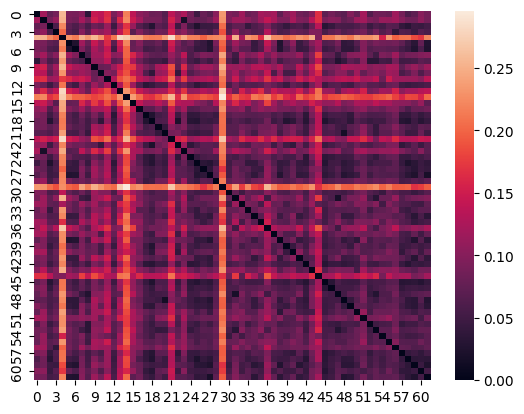

In [ ]:
import seaborn as sns
sns.heatmap(np.array(jsds).reshape(62,-1))

In [ ]:
np.array(jsds).shape

(7260,)

In [ ]:
#topics, probs = topic_model.transform(te_corpus2)
#topic_distr, topic_token_distr = topic_model.approximate_distribution(te_corpus2, calculate_tokens=True)
new_dict_te_2 = defaultdict(list)

for k, v in new_counter_te.items():
    sum_per_author = np.zeros(probs.shape[1])
    n_doc = len(v)
    for i in range(len(v)):
        sum_per_author = sum([sum_per_author, probs[v[i]]], axis=0)
    mean_prob = sum_per_author/n_doc
    new_dict_te_2[k].append(mean_prob)
P1 = []
j = 0
for auth, m in new_dict_te_2.items():
    P1.append(m)
    j +=1

# calculating JS divergence between authors
print("calculating JS divergence..")
print("---------------------------")
P2 = P1
KL = []
for p in np.array(P1):
    kl = []
    for q in np.array(P2):
        ent = JSD(p.ravel(), q.ravel())
        kl.append(ent)
    KL.append(kl)
print("Average JS Divergence", np.mean(KL)) #scientific articles 40 auths, 80 docs


calculating JS divergence..
---------------------------
Average JS Divergence 0.17753033709895147


In [ ]:
#topics, probs = topic_model.transform(te_corpus2)
#topic_distr, topic_token_distr = topic_model.approximate_distribution(te_corpus2, calculate_tokens=True)
new_dict_te_2 = defaultdict(list)

for k, v in new_counter_te.items():
    sum_per_author = np.zeros(probs.shape[1])
    n_doc = len(v)
    for i in range(len(v)):
        sum_per_author = sum([sum_per_author, probs[v[i]]], axis=0)
    mean_prob = sum_per_author/n_doc
    new_dict_te_2[k].append(mean_prob)
P1 = []
j = 0
for auth, m in new_dict_te_2.items():
    P1.append(m)
    j +=1

# calculating JS divergence between authors
print("calculating JS divergence..")
print("---------------------------")
P2 = P1
KL = []
for p in np.array(P1):
    kl = []
    for q in np.array(P2):
        ent = JSD(p.ravel(), q.ravel())
        kl.append(ent)
    KL.append(kl)
print("Average JS Divergence", np.mean(KL)) #scientific articles 230 auths, 272 docs


calculating JS divergence..
---------------------------
Average JS Divergence 0.43446034418076257


In [ ]:
#topics, probs = topic_model.transform(te_corpus2)
#topic_distr, topic_token_distr = topic_model.approximate_distribution(te_corpus2, calculate_tokens=True)
new_dict_te_2 = defaultdict(list)

for k, v in new_counter_te.items():
    sum_per_author = np.zeros(probs.shape[1])
    n_doc = len(v)
    for i in range(len(v)):
        sum_per_author = sum([sum_per_author, probs[v[i]]], axis=0)
    mean_prob = sum_per_author/n_doc
    new_dict_te_2[k].append(mean_prob)
P1 = []
j = 0
for auth, m in new_dict_te_2.items():
    P1.append(m)
    j +=1

# calculating JS divergence between authors
print("calculating JS divergence..")
print("---------------------------")
P2 = P1
KL = []
for p in np.array(P1):
    kl = []
    for q in np.array(P2):
        ent = JSD(p.ravel(), q.ravel())
        kl.append(ent)
    KL.append(kl)
print("Average JS Divergence", np.mean(KL))


calculating JS divergence..
---------------------------
Average JS Divergence 0.1079708774705392


In [ ]:
len(P1),

(10,)

In [ ]:
import seaborn as sns

<Axes: >

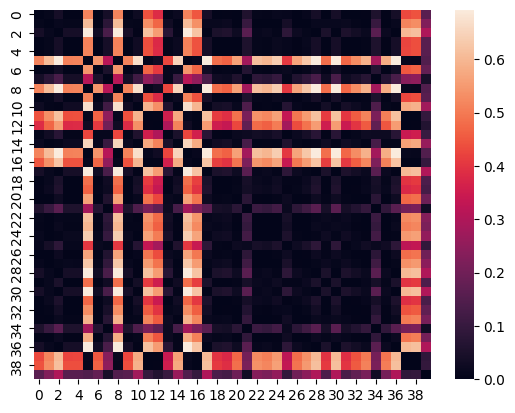

In [ ]:
sns.heatmap(np.array(KL)) #80 docs 40 auths scit articles

<Axes: >

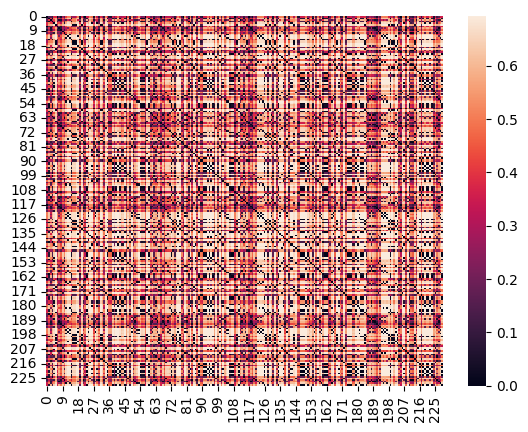

In [ ]:

sns.heatmap(np.array(KL)) # 230 auths 272 docs

<Axes: >

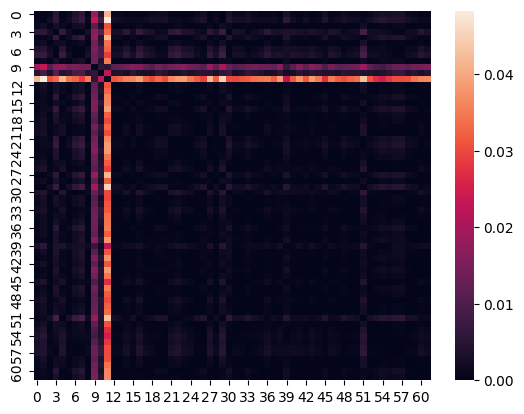

In [ ]:
sns.heatmap(np.array(KL))

In [ ]:
topics, probs = topic_model.fit_transform(tr.text.values)
topic_distr, topic_token_distr = topic_model.approximate_distribution(tr.text.values, calculate_tokens=True)
new_dict_2 = defaultdict(list)
for k, v in new_dict.items():
    sum_per_author = np.zeros(topic_distr.shape[1])
    n_doc = len(v)
    for i in range(len(v)):
        sum_per_author = sum([sum_per_author, topic_distr[v[i]]], axis=0)
    mean_prob = sum_per_author/n_doc
    new_dict_2[k].append(mean_prob)
P1 = []
j = 0
for auth, m in new_dict_2.items():
    P1.append(m)
    j +=1

# calculating JS divergence between authors
print("calculating JS divergence..")
print("---------------------------")
P2 = P1
KL = []
for p in np.array(P1):
    kl = []
    for q in np.array(P2):
        ent = JSD(p.ravel(), q.ravel())
        kl.append(ent)
    KL.append(kl)
print("Average JS Divergence", np.mean(KL))

calculating JS divergence..
---------------------------
Average JS Divergence 0.07903945404420963


In [ ]:
topic_distr, topic_token_distr = topic_model.approximate_distribution(tr_corpus2, calculate_tokens=True)
topic_distr

array([[0.        , 0.        , 0.03856131, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.03832204, 0.01187055, ..., 0.        , 0.408955  ,
        0.        ],
       [0.00405916, 0.        , 0.        , ..., 0.00894052, 0.02392481,
        0.        ],
       ...,
       [0.        , 0.        , 0.84425173, ..., 0.01469603, 0.        ,
        0.        ],
       [0.        , 0.        , 0.02722584, ..., 0.        , 0.        ,
        0.00904016],
       [0.92387116, 0.        , 0.00882756, ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
len(topic_token_distr)

800

In [ ]:
topic_distr.shape

(800, 18)

In [ ]:
new_dict_te_2 = defaultdict(list)
for k, v in new_dict.items():
    sum_per_author = np.zeros(15)
    n_doc = len(v)
    for i in range(len(v)):
        sum_per_author = sum([sum_per_author, topic_distr[v[i]]], axis=0)
    mean_prob = sum_per_author/n_doc
    new_dict_te_2[k].append(mean_prob)
new_dict_te_2

defaultdict(list,
            {8: [array([0.29546924, 0.08921178, 0.11163805, 0.04266306, 0.03934298,
                     0.0906914 , 0.07446219, 0.03338515, 0.0344845 , 0.04450134,
                     0.04183332, 0.02408223, 0.01353272, 0.0228368 , 0.04186524])],
             2: [array([0.05989161, 0.03801502, 0.04728386, 0.03441314, 0.14476902,
                     0.09448764, 0.03534083, 0.09069132, 0.13165232, 0.02049212,
                     0.07553062, 0.07861806, 0.01633762, 0.04245934, 0.09001747])],
             1: [array([0.19585104, 0.08309118, 0.10883712, 0.04588759, 0.05822404,
                     0.10478353, 0.08330364, 0.04648614, 0.04425963, 0.03965777,
                     0.05168775, 0.03319801, 0.02438395, 0.0234285 , 0.05692011])],
             4: [array([0.0617617 , 0.04303852, 0.04791424, 0.03018176, 0.08811643,
                     0.10199746, 0.04098645, 0.13979763, 0.08582989, 0.0265744 ,
                     0.08973587, 0.08839615, 0.01848912, 0.04512167, 0

In [ ]:
P1 = []
j = 0
for auth, m in new_dict_2.items():
    P1.append(m)
    j +=1

# calculating JS divergence between authors
print("calculating JS divergence..")
print("---------------------------")
P2 = P1
KL = []
for p in np.array(P1):
    kl = []
    for q in np.array(P2):
        ent = JSD(p.ravel(), q.ravel())
        kl.append(ent)
    KL.append(kl)
print("Average JS Divergence", np.mean(KL))


calculating JS divergence..
---------------------------
Average JS Divergence 0.3661405396693695


# Aggregated bertopic-based KL Divergence

In [ ]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [ ]:
import pandas as pd
import numpy as np
import math
import nltk
import sklearn
import re
import os
from sklearn.feature_extraction.text import CountVectorizer
import spacy
nlp = spacy.load("en_core_web_sm")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from __future__ import division, print_function
from collections import defaultdict
from numpy import sum
#import numpy as np
#import matplotlib.pyplot as plt
#import seaborn as sns
from scipy.stats import entropy
from numpy.linalg import norm
from collections import Counter
#import argparse
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
np.random.seed(1337)

In [ ]:
infix_re = spacy.util.compile_infix_regex([r'''[~]'''])
tokenizer = spacy.tokenizer.Tokenizer(nlp.vocab, infix_finditer=infix_re.finditer)
nlp.tokenizer = tokenizer
stop_words = set(stopwords.words('english'))

RE_DIGITS = re.compile(r'\d+(th|st|nd|nth)|[\'`´‘]?\d+[\'`´‘]?s?\b|\d')
def clean_str2(sentence):
    sentence = RE_DIGITS.sub(r'#', sentence)
    sentence = re.sub("&amp;","",sentence)
    sentence = re.sub("^\\$|\d+", "#", sentence) #https://stackoverflow.com/questions/60741977/simplified-regex-to-remove-dollar-sign-and-anything-after-the-decimal-point-in-a
    sentence = re.sub(' +', ' ',sentence)
    sentence = re.sub(r"([\w/'+$\s-]+|[^\w/'+$\s-]+)\s*", r"\1 ", sentence) #https://stackoverflow.com/questions/27810884/python-how-do-i-separate-punctuation-from-words-by-white-space-leaving-only-on
    #masked_sentence = re.sub(' +', ' ',sentence)
    word_tokens = word_tokenize(sentence)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    sentence = ' '.join(filtered_sentence)
    sentence = sentence.replace(" ,",",")
    sentence = sentence.replace(" . ",". ")
    sentence = sentence.replace(" .",".")
    sentence = sentence.replace(" - ","-")
    sentence = sentence.replace(" ; ","; ")
    sentence = re.sub(r'"\s*(.*?)\s*"', r'"\1"', sentence)

    #masked_sentence = re.sub(r'"\s*([^"]*?)\s*"',"\1",masked_sentence)

    sentence = sentence.replace(" ' ","'")
    sentence = sentence.replace(" 's","'s")
    sentence = sentence.replace("''",'')
    sentence = sentence.replace('""','')
    sentence = sentence.replace('``','')
    sentence = re.sub(r"\s{2,}", " ", sentence)

    return sentence

In [ ]:
def JSD(P, Q):
    _P = P / norm(P, ord=1)
    _Q = Q / norm(Q, ord=1)
    _M = 0.5 * (_P + _Q)
    return 0.5 * (entropy(_P, _M) + entropy(_Q, _M))


In [ ]:
from bertopic import BERTopic
new_topic_model = BERTopic(calculate_probabilities=True)

def get_topic_div(tr,model=None):

    tr_corpus = [clean_str2(i) for i in tr.text.values]
    #tr_corpus = tr.text.values
    tr_y = tr.author.values
    print(len(tr_corpus))
    dict_tr = {}
    for i in range(len(tr_corpus)):
        dict_tr[i] = tr_y[i]    #index:author pairs
    if model!=None:
        topic_model = model
        topics, probs = topic_model.transform(tr_corpus)
    else:
        topic_model = new_topic_model
        topics, probs = topic_model.fit_transform(tr_corpus)
    topics_inf = topic_model.get_topic_info()
    #print(topics_inf)
    #num_topics = topics_inf.shape[0]-1
#topics, probs = topic_model.transform(te_corpus2)
    topic_distr, topic_token_distr = topic_model.approximate_distribution(tr_corpus, calculate_tokens=True)
    num_topics = topic_distr.shape[1]
    print(f"{num_topics = }")
    new_dict_tr = defaultdict(list)
    for k, v in dict_tr.items():
        new_dict_tr[v].append(k) #author:[list of his indices] pair

    new_counter_tr=defaultdict(list)
    #for i in range(num_author):
        #auth=[]
        #for k, v in new_dict_tr.items():
        #    if v == i:
        #        auth.append(k)
        #new_counter_tr[i] = auth
#new_counter_tr

    for k, v in new_dict_tr.items():
        sum_per_author = np.zeros(num_topics)
        n_doc = len(v)
        for i in range(len(v)):
            sum_per_author = sum([sum_per_author, topic_distr[v[i]]], axis=0)
        mean_prob = sum_per_author/n_doc
        new_counter_tr[k].append(mean_prob) #{author:mean_prob_of_all_his_writings'_topic_distrib} pair ==> considering #ofdocs per author
    P1 = []

    for auth, m in new_counter_tr.items():
        P1.append(m)


    # calculating JS divergence between authors
    print("calculating JS divergence..")
    print("---------------------------")
    P2 = P1
    KL = []
    for p in np.array(P1):
        kl = []
        for q in np.array(P2):
            ent = JSD(p.ravel(), q.ravel())
            kl.append(ent)
        KL.append(kl)
    print("Average JS Divergence", np.mean(KL))
    return {'topic_model':topic_model, 'topic_distr':topic_distr}

In [ ]:
tr = pd.read_csv('/content/80-20 TRAIN SET CCAT10 WITH AGG LABELS AND POS_MASKED_CLEANED_TXT.csv',index_col = 'Unnamed: 0')
te = pd.read_csv('/content/80-20 TEST SET CCAT10 WITH AGG LABELS AND POS_MASKED_CLEANED_TXT.csv',index_col = 'Unnamed: 0')
ccat_10_tr_model = get_topic_div(tr)

num_topics = 24
calculating JS divergence..
---------------------------
Average JS Divergence 0.3844448920618446


In [ ]:
ccat_10_te_model = get_topic_div(te, model = ccat_10_tr_model)

num_topics = 24
calculating JS divergence..
---------------------------
Average JS Divergence 0.3706993520386033


In [ ]:
tr = pd.read_csv('/content/TRAIN 80-20 CAT 50 STYLOMETRIX_AND_SENT_AGG_LABELS.csv',index_col = 'Unnamed: 0')
te = pd.read_csv('/content/TEST 80-20 CAT 50 STYLOMETRIX_AND_SENT_AGG_LABELS.csv',index_col = 'Unnamed: 0')
ccat_50_tr_model = get_topic_div(tr)

num_topics = 111
calculating JS divergence..
---------------------------
Average JS Divergence 0.42952405173402075


In [ ]:
ccat_50_te_model = get_topic_div(te, model = ccat_50_tr_model)

num_topics = 111
calculating JS divergence..
---------------------------
Average JS Divergence 0.4468211279102993


In [ ]:
tr = pd.read_csv('/content/judgement_80-20_train.csv')#,index_col = 'Unnamed: 0')
te = pd.read_csv('/content/judgement_80-20_test.csv')#,index_col = 'Unnamed: 0')
tr

,text,author
0,"The judgment of Mann J. is, in my opinion, rig...",1
1,These appeals from the board of review were br...,2
2,This appeal is an incident in a lamentable dis...,2
3,These appeals are from the Full Court of the S...,1
4,This action is brought with the aid of s. 30 (...,1
...,...,...
1387,On 9th March 1925 the registered proprietors o...,0
1388,The order of the Court of Bankruptcy for the a...,0
1389,The fresh evidence upon which the Supreme Cour...,1
1390,This is an appeal by special leave from a deci...,2


In [ ]:
judgement_3_tr_model = get_topic_div(tr)

num_topics = 19
calculating JS divergence..
---------------------------
Average JS Divergence 0.004688391437643163


In [ ]:
judgement_3_te_model = get_topic_div(te,model = judgement_3_tr_model)

num_topics = 19
calculating JS divergence..
---------------------------
Average JS Divergence 0.006063067668420809


## IMDB62

In [ ]:
#tr = pd.read_csv('/content/IMDB62_train_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')
#te = pd.read_csv('/content/IMDB62_test_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')


#tr
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.1430062584749043

#te
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.2090045003458438

te = pd.read_csv('/content/60-20-20 TEST IMDB62w100txt stylometrix.csv')
val = pd.read_csv('/content/60-20-20 VAL IMDB62w100txt stylometrix.csv')
tr = pd.read_csv('/content/60-20-20 TRAIN IMDB62w100txt stylometrix.csv')
tr

,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,POS_NUM,...,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author
0,"Jean Rollin artistic nonsense about vampires ,...",0.15,0.20,0.10,0.04,0.10,0.00,0.09,0.05,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.07,0.00,0.00,47
1,I liked this better than I thought I would . I...,0.15,0.17,0.09,0.07,0.11,0.00,0.05,0.03,0.01,...,0.00,0.00,0.00,0.00,0.01,0.00,0.07,0.00,0.00,53
2,"Rachel McAdams is very good as smart , efficie...",0.16,0.19,0.08,0.05,0.10,0.00,0.06,0.02,0.00,...,0.00,0.01,0.01,0.00,0.00,0.01,0.06,0.00,0.00,18
3,SUKKAR BANAT ( CARAMEL ) marks a fine director...,0.12,0.18,0.11,0.04,0.10,0.00,0.04,0.01,0.00,...,0.00,0.01,0.00,0.00,0.00,0.00,0.06,0.00,0.00,49
4,The last film in the series RoboCop 3 is diffe...,0.17,0.17,0.09,0.04,0.10,0.00,0.07,0.02,0.02,...,0.00,0.01,0.01,0.00,0.01,0.00,0.08,0.00,0.01,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3715,"Ace in the Hole's main character , Chuck Tatum...",0.13,0.17,0.10,0.06,0.10,0.00,0.06,0.03,0.01,...,0.00,0.01,0.00,0.00,0.00,0.00,0.08,0.00,0.00,9
3716,"Since I am not American , I have no idea what ...",0.16,0.16,0.10,0.06,0.09,0.00,0.08,0.03,0.00,...,0.00,0.01,0.01,0.00,0.01,0.01,0.06,0.00,0.00,2
3717,"Buddies Matt Damon and Ben Affleck , combined ...",0.11,0.22,0.06,0.02,0.09,0.00,0.04,0.02,0.01,...,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.00,8
3718,When we watch movies and cartoons from the ' 4...,0.17,0.17,0.06,0.05,0.09,0.00,0.06,0.03,0.01,...,0.00,0.01,0.01,0.00,0.00,0.00,0.06,0.00,0.00,55


**BERTOPIC coling cleaned**

In [ ]:
TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords not removed

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

num_topics = 77
calculating JS divergence..
---------------------------
Average JS Divergence 0.024811818304786716


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3524,-1_the_and_of_to,"[the, and, of, to, is, in, it, that, as, this]",[After a promising start that sees our hero lo...
1,0,273,0_the_of_show_to,"[the, of, show, to, and, was, comedy, it, as, in]",[Although I have not personally seen the entir...
2,1,164,1_it_movie_this_the,"[it, movie, this, the, and, is, nt, of, that, to]",[This has got stuff going for it . It ignores ...
3,2,150,2_french_of_the_in,"[french, of, the, in, and, to, his, is, her, t...",[I sensed that Luc Besson \( director of The F...
4,3,124,3_wayne_western_the_in,"[wayne, western, the, in, of, his, to, roy, an...",[West of the Divide finds the Duke as a man se...
...,...,...,...,...,...
73,72,10,72_viktor_russian_russia_moscow,"[viktor, russian, russia, moscow, belushi, dan...","[The Governator plays Captain Ivan Danko , a h..."
74,73,10,73_good_tremors_great_was,"[good, tremors, great, was, krull, flash, my, ...",[Flash Gordan is a excellent film with great e...
75,74,10,74_family_gidget_jackie_son,"[family, gidget, jackie, son, townhouse, mothe...",[for The Squid and the Whale . This picture ha...
76,75,10,75_slugs_bigfoot_creature_sasquatch,"[slugs, bigfoot, creature, sasquatch, marx, tr...",[The meteoric success of The Legend of Boggy C...


In [ ]:
print(imdb_no_clean_tr_tp.shape)

(6200, 77)


In [ ]:
stop_words = set(stopwords.words('english'))
def clean_str_modified_with_stopwrds(string):
    string = re.sub(r"[^A-Za-z0-9(),!?\'\`.]", " ", string)
    string = re.sub(r"\d+", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string)
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    word_tokens = word_tokenize(string)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    string = ' '.join(filtered_sentence)
    return string.strip()

In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned - stopwords removed

num_topics = 78
calculating JS divergence..
---------------------------
Average JS Divergence 0.16144427456965482
(6200, 78)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3724,-1_film_nt_movie_one,"[film, nt, movie, one, like, good, story, well...",[good could expect movie ' hip ' title Joy Rid...
1,0,176,0_french_jean_la_le,"[french, jean, la, le, de, les, film, chabrol,...",[great films Claude Chabrol made Breach one of...
2,1,154,1_japanese_chinese_chan_one,"[japanese, chinese, chan, one, film, movie, ma...",[interesting coincidence television programing...
3,2,126,2_western_wayne_roy_westerns,"[western, wayne, roy, westerns, john, eastwood...","[Western film fans trivia enthusiasts , one bl..."
4,3,105,3_film_davis_wife_nt,"[film, davis, wife, nt, great, life, husband, ...",[Secret Success owes minimal success casting M...
...,...,...,...,...,...
74,73,12,73_precinct_police_academy_sequels,"[precinct, police, academy, sequels, lasard, h...",['s amazing number film franchises 's relative...
75,74,11,74_island_maynard_shrews_nau,"[island, maynard, shrews, nau, justin, dogs, p...",[Knowing several actors movie turned remarkabl...
76,75,11,75_hanks_viktor_dicaprio_number,"[hanks, viktor, dicaprio, number, imposter, te...",[. . . Steven Spielberg 's latest Blockbuster ...
77,76,11,76_walt_donald_disney_duck,"[walt, donald, disney, duck, mickey, animated,...",[Walt Disney DONALD DUCK Cartoon . two tiny CO...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #cleanstr2 (cleaned with stopwords not removed)

num_topics = 67
calculating JS divergence..
---------------------------
Average JS Divergence 0.14805246996198324
(6200, 67)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3557,-1_film_nt_one_movie,"[film, nt, one, movie, like, good, story, time...",[movie never promised ultimate definite histor...
1,0,291,0_comedy_funny_show_one,"[comedy, funny, show, one, movie, jokes, would...",[movie features kinds different comedy. Slapst...
2,1,277,1_horror_house_film_nt,"[horror, house, film, nt, one, movie, dead, li...",[Legend Hell House starts ageing millionaire R...
3,2,146,2_french_la_de_les,"[french, la, de, les, le, jean, france, one, f...",['s dream come true : favourite French directo...
4,3,110,3_war_soldiers_american_documentary,"[war, soldiers, american, documentary, nt, fil...",['s also good refreshing sometimes also import...
...,...,...,...,...,...
63,62,12,62_war_civil_confederate_union,"[war, civil, confederate, union, twain, lincol...","[episode, learn ( least, familiar man ) Bedfor..."
64,63,10,63_gwen_divorce_brownings_characters,"[gwen, divorce, brownings, characters, ril, fe...","[Welcome world Tod Browning, world sideshows t..."
65,64,10,64_reginald_sir_kitty_married,"[reginald, sir, kitty, married, husband, diamo...",[Enjoyed British film concerns woman named Ter...
66,65,10,65_beckman_devlin_hoot_cagney,"[beckman, devlin, hoot, cagney, race, car, bla...",[Blackjack starts former FED Jack Devlin ( Dol...


**BERTOPIC IMDB62 with no cleaning**

In [ ]:

imdb_dict_tr_no_clean = get_topic_div(tr)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.0007054152650759933


,Topic,Count,Name,Representation,Representative_Docs
0,0,3708,0_the_and_of_to,"[the, and, of, to, in, is, that, it, as, this]",[The remake of Ocean's 11 is a tremendously en...
1,1,12,1_the_archer_tpol_and,"[the, archer, tpol, and, of, to, enterprise, i...",[The Enterprise locates an uninhabited planet ...


In [ ]:
imdb_62_val_no_clean = get_topic_div(val,imdb_62_tr_model_no_clean)
imdb_no_clean_val_tp = imdb_62_val_no_clean['topic_distr']
np.save('imdb_no_clean_val_topic_distr.npy',imdb_no_clean_val_tp)
imdb_62_val_model_no_clean = imdb_62_val_no_clean['topic_model']
imdb_62_val_model_no_clean.get_topic_info()

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.0007690812468489596


,Topic,Count,Name,Representation,Representative_Docs
0,0,3708,0_the_and_of_to,"[the, and, of, to, in, is, that, it, as, this]",[The remake of Ocean's 11 is a tremendously en...
1,1,12,1_the_archer_tpol_and,"[the, archer, tpol, and, of, to, enterprise, i...",[The Enterprise locates an uninhabited planet ...


In [ ]:
imdb_62_te_no_clean = get_topic_div(te,imdb_62_tr_model_no_clean)
imdb_no_clean_te_tp = imdb_62_te_no_clean['topic_distr']
np.save('imdb_no_clean_te_topic_distr.npy',imdb_no_clean_te_tp)
imdb_62_te_model_no_clean = imdb_62_te_no_clean['topic_model']
imdb_62_te_model_no_clean.get_topic_info()

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.0005931374981255281


,Topic,Count,Name,Representation,Representative_Docs
0,0,3708,0_the_and_of_to,"[the, and, of, to, in, is, that, it, as, this]",[The remake of Ocean's 11 is a tremendously en...
1,1,12,1_the_archer_tpol_and,"[the, archer, tpol, and, of, to, enterprise, i...",[The Enterprise locates an uninhabited planet ...


**BERTOPIC after cleaning**

In [ ]:
imdb_tr_dict = get_topic_div(tr)
imdb_62_tr_tp = imdb_tr_dict['topic_distr']
np.save('imdb_tr_topic_distr.npy',imdb_62_tr_tp)
imdb_62_tr_model = imdb_tr_dict['topic_model']
imdb_62_tr_model.get_topic_info()

KeyboardInterrupt: 

In [ ]:
imdb_62_val = get_topic_div(val,imdb_62_tr_model)
imdb_62_val_tp = imdb_62_val['topic_distr']
np.save('imdb_val_topic_distr.npy',imdb_62_val_tp)
imdb_62_val_model = imdb_62_val['topic_model']
imdb_62_val_model.get_topic_info()

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.014681663626325938


,Topic,Count,Name,Representation,Representative_Docs
0,0,3709,0_film_one_nt_movie,"[film, one, nt, movie, like, good, also, story...",[Vampire Lovers original Hammer movie much pre...
1,1,11,1_archer_tpol_enterprise_planet,"[archer, tpol, enterprise, planet, captain, tr...",[Archer Daniels trapped destroyed # century wi...


In [ ]:
imdb_62_val_tp.shape

(1240, 2)

In [ ]:
imdb_62_te = get_topic_div(te,imdb_62_tr_model)
imdb_62_te_tp = imdb_62_te['topic_distr']
np.save('imdb_te_topic_distr.npy',imdb_62_te_tp)
print(imdb_62_te_tp.shape)
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info()

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.013933797330892509
(1240, 2)


,Topic,Count,Name,Representation,Representative_Docs
0,0,3709,0_film_one_nt_movie,"[film, one, nt, movie, like, good, also, story...",[Vampire Lovers original Hammer movie much pre...
1,1,11,1_archer_tpol_enterprise_planet,"[archer, tpol, enterprise, planet, captain, tr...",[Archer Daniels trapped destroyed # century wi...


## JUDGEMENT3

In [ ]:
#tr = pd.read_csv('/content/IMDB62_train_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')
#te = pd.read_csv('/content/IMDB62_test_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')


#tr
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.1430062584749043

#te
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.2090045003458438

tr = pd.read_csv('/content/judgements3_stylo_train_sampled_112.csv')
val = pd.read_csv('/content/judgements3_stylo_val_sampled_38.csv')
te = pd.read_csv('/content/judgements3_stylo_test_sampled_37.csv')
tr

,Unnamed: 0,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,...,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author
0,458,I agree that the appeal should be allowed. The...,0.195084,0.201229,0.058372,0.023041,0.144393,0.000000,0.064516,0.041475,...,0.000000,0.009217,0.003072,0.0,0.000000,0.000000,0.112135,0.000000,0.000000,0
1,299,The complaints made by the plaintiff against t...,0.178501,0.206114,0.062130,0.032544,0.126233,0.000000,0.064103,0.040434,...,0.000000,0.004931,0.001972,0.0,0.000000,0.000000,0.094675,0.000000,0.000986,0
2,467,"The reasons, which I have given for my opinion...",0.138298,0.244681,0.021277,0.021277,0.138298,0.000000,0.031915,0.010638,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.127660,0.000000,0.000000,0
3,477,The question for decision upon this appeal is ...,0.198460,0.180496,0.042344,0.026091,0.157399,0.000000,0.068435,0.036356,...,0.000000,0.005133,0.000855,0.0,0.000428,0.000000,0.125749,0.000000,0.000000,0
4,320,Before a Court of Petty Sessions in Sydney the...,0.168563,0.207754,0.075432,0.020228,0.134429,0.000000,0.069111,0.025706,...,0.000421,0.005478,0.001686,0.0,0.001264,0.000421,0.096081,0.000421,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,195,The Little Company of Mary (South Australia) I...,0.146179,0.202658,0.068660,0.028239,0.133998,0.002769,0.076412,0.027685,...,0.000000,0.007198,0.001107,0.0,0.000000,0.000000,0.097453,0.000000,0.000000,2
332,528,In this matter a summons under the provisions ...,0.152279,0.176528,0.048497,0.022308,0.149370,0.000000,0.066925,0.030068,...,0.000000,0.004850,0.000970,0.0,0.003880,0.000000,0.107662,0.000000,0.000970,2
333,225,I realize that it is very advisable to deliver...,0.189189,0.174174,0.057057,0.042042,0.123123,0.000000,0.075075,0.036036,...,0.000000,0.003003,0.003003,0.0,0.000000,0.000000,0.126126,0.000000,0.000000,2
334,240,The question raised for our decision in this a...,0.185801,0.234139,0.033233,0.022659,0.141994,0.000000,0.064955,0.043807,...,0.000000,0.004532,0.000000,0.0,0.003021,0.000000,0.098187,0.000000,0.000000,2


**JUDGEMENT3 with str2 cleaning**

In [ ]:
TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('judgement_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info() #cleanstr2

num_topics = 12
calculating JS divergence..
---------------------------
Average JS Divergence 0.009006321787894157
(561, 12)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,211,-1_act_upon_court_case,"[act, upon, court, case, may, would, land, mad...",[question decision appeal cross-appeal whether...
1,0,55,0_act_power_regulations_commonwealth,"[act, power, regulations, commonwealth, parlia...",[determination three cases turns upon question...
2,1,48,1_tax_income_company_assessment,"[tax, income, company, assessment, shares, act...",[Employers'Mutual Indemnity Association incorp...
3,2,48,2_act_court_commonwealth_accused,"[act, court, commonwealth, accused, case, offe...",[appellant appeared stipendiary magistrate Vic...
4,3,33,3_industrial_award_court_power,"[industrial, award, court, power, dispute, arb...",[Victorian Railways Commissioners # February #...
5,4,26,4_negligence_plaintiff_evidence_jury,"[negligence, plaintiff, evidence, jury, defend...",[action claim damages based Compensation Relat...
6,5,26,5_income_death_estate_gift,"[income, death, estate, gift, testatrix, inter...",[appeal order Supreme Court New South Stamp Du...
7,6,25,6_contract_defendant_plaintiff_sale,"[contract, defendant, plaintiff, sale, company...","[action commenced # May #, brought wife reside..."
8,7,23,7_mortgage_land_interest_upon,"[mortgage, land, interest, upon, covenant, opt...",[active life respondent company brought end # ...
9,8,21,8_injury_employment_compensation_worker,"[injury, employment, compensation, worker, inc...","[appeal Dowell Australia Limited ( Dowells ), ..."


In [ ]:
TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('judgement_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info() #coling18 cleaner+ stopwords removal

num_topics = 10
calculating JS divergence..
---------------------------
Average JS Divergence 0.00850988202158548
(561, 10)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,207,-1_act_court_upon_case,"[act, court, upon, case, may, would, made, sai...",[question case stripped nonessentials claim tr...
1,0,61,0_company_income_tax_assessment,"[company, income, tax, assessment, commissione...",[suit brought Commissioner Taxation due provis...
2,1,50,1_contract_mortgage_company_upon,"[contract, mortgage, company, upon, land, woul...","[th August respondent 's husband , Estyn Jones..."
3,2,47,2_plaintiff_defendant_negligence_jury,"[plaintiff, defendant, negligence, jury, evide...",[appeal relates action negligence arose collid...
4,3,42,3_regulations_power_act_commonwealth,"[regulations, power, act, commonwealth, reg, p...",[first question decided action whether Women '...
5,4,37,4_trust_gift_death_testator,"[trust, gift, death, testator, property, estat...",[question decision whether property subject tr...
6,5,32,5_court_act_order_accused,"[court, act, order, accused, offence, law, jur...",[appellant convicted Supreme Court Northern Te...
7,6,32,6_industrial_award_court_act,"[industrial, award, court, act, dispute, emplo...",[two appeals brought sec . \ ( \ ) Judiciary A...
8,7,22,7_injury_employment_compensation_worker,"[injury, employment, compensation, worker, inc...",[decision Workers ' Compensation Commission ca...
9,8,19,8_state_milk_inter_act,"[state, milk, inter, act, commerce, trade, clr...","[necessary consider , first place , whether , ..."


In [ ]:
TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('judgement_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info() #coling18 cleaner

num_topics = 13
calculating JS divergence..
---------------------------
Average JS Divergence 0.00040503709681491564
(561, 13)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,250,-1_the_of_to_in,"[the, of, to, in, and, that, is, it, by, be]","[In this suit , brought in the original jurisd..."
1,0,67,0_the_of_to_in,"[the, of, to, in, is, tax, income, and, that, ...",[If there is any ground upon which the plan ad...
2,1,36,1_the_to_of_that,"[the, to, of, that, in, and, is, it, was, you]",[This is an application for special leave to a...
3,2,32,2_the_of_to_that,"[the, of, to, that, was, in, and, it, is, at]",[The action is a claim for damages based on th...
4,3,28,3_the_of_to_in,"[the, of, to, in, injury, that, is, his, worke...",[The Workers' Compensation Commission of New S...
5,4,23,4_the_of_to_in,"[the, of, to, in, and, award, is, an, industri...",[The proceeding before us is an order nisi for...
6,5,21,5_the_of_to_and,"[the, of, to, and, in, that, land, or, is, be]",[This is an appeal from a judgment of Virtue J...
7,6,20,6_the_of_her_to,"[the, of, her, to, will, that, in, and, testat...","[Elizabeth Bull , a spinster , died on st July..."
8,7,17,7_the_of_in_is,"[the, of, in, is, to, and, that, or, trade, it]",[This case stated raises the question whether ...
9,8,15,8_the_of_to_in,"[the, of, to, in, mortgage, and, by, that, is,...",[This is an appeal from the Central Court of t...


**BERTOPIC IMDB62 with no cleaning**

In [ ]:
imdb_dict_tr_no_clean = get_topic_div(tr)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
np.save('judgement_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()

num_topics = 7
calculating JS divergence..
---------------------------
Average JS Divergence 0.00016161999436882025


,Topic,Count,Name,Representation,Representative_Docs
0,-1,137,-1_the_of_to_in,"[the, of, to, in, and, that, is, it, or, be]",[The determination of these three cases turns ...
1,0,40,0_the_of_to_in,"[the, of, to, in, that, is, and, it, by, be]",[This is an appeal by special leave from an or...
2,1,33,1_the_of_in_to,"[the, of, in, to, is, income, company, and, ta...",[The taxpayer is a company incorporated in Eng...
3,2,32,2_the_of_to_that,"[the, of, to, that, in, and, was, it, at, is]",[This is an appeal as of right by the defendan...
4,3,26,3_the_of_to_in,"[the, of, to, in, her, and, that, is, she, it]","[This action was commenced on 25th May 1928, a..."
5,4,26,4_the_of_to_in,"[the, of, to, in, that, and, is, was, his, by]",[This is an appeal by Dowell Australia Limited...
6,5,22,5_the_of_to_in,"[the, of, to, in, and, is, that, it, an, award]",[The Victorian Railways Commissioners on 14th ...
7,6,20,6_the_of_to_in,"[the, of, to, in, and, is, milk, that, by, or]","[ It is necessary to consider, in the first pl..."


In [ ]:
print(imdb_no_clean_tr_tp.shape)

(336, 7)


In [ ]:
imdb_62_val_no_clean = get_topic_div(val,imdb_62_tr_model_no_clean)
imdb_no_clean_val_tp = imdb_62_val_no_clean['topic_distr']
np.save('judgement_no_clean_val_topic_distr.npy',imdb_no_clean_val_tp)
print(imdb_no_clean_val_tp.shape)
imdb_62_val_model_no_clean = imdb_62_val_no_clean['topic_model']
imdb_62_val_model_no_clean.get_topic_info()

num_topics = 7
calculating JS divergence..
---------------------------
Average JS Divergence 9.204966023625296e-05
(114, 7)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,137,-1_the_of_to_in,"[the, of, to, in, and, that, is, it, or, be]",[The determination of these three cases turns ...
1,0,40,0_the_of_to_in,"[the, of, to, in, that, is, and, it, by, be]",[This is an appeal by special leave from an or...
2,1,33,1_the_of_in_to,"[the, of, in, to, is, income, company, and, ta...",[The taxpayer is a company incorporated in Eng...
3,2,32,2_the_of_to_that,"[the, of, to, that, in, and, was, it, at, is]",[This is an appeal as of right by the defendan...
4,3,26,3_the_of_to_in,"[the, of, to, in, her, and, that, is, she, it]","[This action was commenced on 25th May 1928, a..."
5,4,26,4_the_of_to_in,"[the, of, to, in, that, and, is, was, his, by]",[This is an appeal by Dowell Australia Limited...
6,5,22,5_the_of_to_in,"[the, of, to, in, and, is, that, it, an, award]",[The Victorian Railways Commissioners on 14th ...
7,6,20,6_the_of_to_in,"[the, of, to, in, and, is, milk, that, by, or]","[ It is necessary to consider, in the first pl..."


In [ ]:
imdb_62_te_no_clean = get_topic_div(te,imdb_62_tr_model_no_clean)
imdb_no_clean_te_tp = imdb_62_te_no_clean['topic_distr']
np.save('judgement_no_clean_te_topic_distr.npy',imdb_no_clean_te_tp)
print(imdb_no_clean_te_tp.shape)
imdb_62_te_model_no_clean = imdb_62_te_no_clean['topic_model']
imdb_62_te_model_no_clean.get_topic_info()

num_topics = 7
calculating JS divergence..
---------------------------
Average JS Divergence 0.00010740810135861185
(111, 7)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,137,-1_the_of_to_in,"[the, of, to, in, and, that, is, it, or, be]",[The determination of these three cases turns ...
1,0,40,0_the_of_to_in,"[the, of, to, in, that, is, and, it, by, be]",[This is an appeal by special leave from an or...
2,1,33,1_the_of_in_to,"[the, of, in, to, is, income, company, and, ta...",[The taxpayer is a company incorporated in Eng...
3,2,32,2_the_of_to_that,"[the, of, to, that, in, and, was, it, at, is]",[This is an appeal as of right by the defendan...
4,3,26,3_the_of_to_in,"[the, of, to, in, her, and, that, is, she, it]","[This action was commenced on 25th May 1928, a..."
5,4,26,4_the_of_to_in,"[the, of, to, in, that, and, is, was, his, by]",[This is an appeal by Dowell Australia Limited...
6,5,22,5_the_of_to_in,"[the, of, to, in, and, is, that, it, an, award]",[The Victorian Railways Commissioners on 14th ...
7,6,20,6_the_of_to_in,"[the, of, to, in, and, is, milk, that, by, or]","[ It is necessary to consider, in the first pl..."


In [ ]:
y_val = np.load('y_val_judgement.npy')
y_test = np.load('y_test_judgement.npy')
y_train = np.load('y_train_judgement.npy')
TR = pd.concat((tr,val,te),axis=0)
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
imdb_62_te = get_topic_div(TR)
imdb_62_te_tp = imdb_62_te['topic_distr']
print(f'{imdb_62_te_tp.shape = }')
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info() #UNCLEANED

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 2.4782461079756e-06
imdb_62_te_tp.shape = (561, 2)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,518,-1_the_of_to_in,"[the, of, to, in, and, that, is, it, be, by]",[The proceeding before us consists of two appe...
1,0,31,0_the_of_to_in,"[the, of, to, in, and, that, is, it, be, or]",[This is an appeal from a judgment of Irvine C...
2,1,12,1_the_of_to_in,"[the, of, to, in, and, that, is, it, court, by]",[In this case the point in limine is whether t...


In [ ]:
#y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
#uncleaned LR train - check
ans2 = get_cv_from_model(imdb_62_te_tp,y,clf_topic_distr)
ans2.mean()

LogisticRegression(random_state=52, solver='sag')


,0
fit_time,0.004171
score_time,0.006546
test_precision_weighted,0.316116
test_recall_weighted,0.356542
test_f1_weighted,0.316094
test_accuracy,0.356542


In [ ]:
ans2

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,0.004725,0.007120,0.221427,0.336283,0.260928,0.336283
1,0.003881,0.006098,0.249366,0.375000,0.298714,0.375000
2,0.003811,0.005960,0.382800,0.357143,0.333217,0.357143
3,0.004151,0.007214,0.336057,0.339286,0.315408,0.339286
4,0.004286,0.006337,0.390931,0.375000,0.372205,0.375000


In [ ]:
y_val = np.load('y_val_judgement.npy')
y_test = np.load('y_test_judgement.npy')
y_train = np.load('y_train_judgement.npy')
TR = pd.concat((tr,val,te),axis=0)
print(TR.shape)
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
imdb_62_te = get_topic_div(TR)
imdb_62_te_tp = imdb_62_te['topic_distr']
print(f'{imdb_62_te_tp.shape = }')
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info() #CLEANED clean_str2

(561, 199)
561


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

num_topics = 11
calculating JS divergence..
---------------------------
Average JS Divergence 0.00861953112416203
imdb_62_te_tp.shape = (561, 11)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,213,-1_act_court_upon_may,"[act, court, upon, may, case, made, land, orde...",[subject upon Div. # Part IV. Maintenance Act ...
1,0,62,0_injury_case_evidence_negligence,"[injury, case, evidence, negligence, employmen...",[case meaning sec. # Workers'Compensation Act ...
2,1,49,1_tax_income_company_assessment,"[tax, income, company, assessment, act, shares...",[Employers'Mutual Indemnity Association incorp...
3,2,48,2_power_act_regulations_commonwealth,"[power, act, regulations, commonwealth, parlia...",[submissions plaintiffs support statement clai...
4,3,47,3_court_jury_act_accused,"[court, jury, act, accused, case, offence, per...",[action plaintiff seeks recover damages Common...
5,4,30,4_industrial_award_court_dispute,"[industrial, award, court, dispute, arbitratio...",[Victorian Railways Commissioners # February #...
6,5,29,5_gift_income_death_estate,"[gift, income, death, estate, testatrix, trust...",[appeal order Supreme Court New South Stamp Du...
7,6,28,6_mortgage_land_interest_upon,"[mortgage, land, interest, upon, notice, coven...",[appeal brought right order action damages bre...
8,7,16,7_contract_plaintiff_defendant_company,"[contract, plaintiff, defendant, company, sale...",[appeals Full Court Supreme Court #. appellant...
9,8,14,8_marriage_adultery_hospital_husband,"[marriage, adultery, hospital, husband, wife, ...",[order appeal brought made Full Court Supreme ...


In [ ]:
#y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
#uncleaned LR train - check
ans2 = get_cv_from_model(imdb_62_te_tp,y,clf_topic_distr)
ans2.mean()

LogisticRegression(random_state=52, solver='sag')


,0
fit_time,0.008980
score_time,0.009484
test_precision_weighted,0.437200
test_recall_weighted,0.442035
test_f1_weighted,0.430632
test_accuracy,0.442035


In [ ]:
ans2

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,0.010366,0.013093,0.454979,0.460177,0.443019,0.460177
1,0.009676,0.007584,0.503779,0.491071,0.488849,0.491071
2,0.008820,0.006837,0.354249,0.375000,0.357142,0.375000
3,0.007610,0.013168,0.402081,0.410714,0.393176,0.410714
4,0.008430,0.006738,0.470909,0.473214,0.470975,0.473214


**BERTOPIC after cleaning**

In [ ]:
imdb_tr_dict = get_topic_div(tr)
imdb_62_tr_tp = imdb_tr_dict['topic_distr']
np.save('judgement_tr_topic_distr.npy',imdb_62_tr_tp)
imdb_62_tr_model = imdb_tr_dict['topic_model']
imdb_62_tr_model.get_topic_info()

num_topics = 6
calculating JS divergence..
---------------------------
Average JS Divergence 0.006012809870241899


,Topic,Count,Name,Representation,Representative_Docs
0,-1,111,-1_act_court_upon_case,"[act, court, upon, case, may, order, question,...",[purpose suit establish plaintiff money upon s...
1,0,58,0_land_upon_would_contract,"[land, upon, would, contract, act, case, may, ...","[action commenced # May #, brought wife reside..."
2,1,49,1_injury_case_evidence_plaintiff,"[injury, case, evidence, plaintiff, would, def...",[case meaning sec. # Workers'Compensation Act ...
3,2,44,2_act_power_milk_regulations,"[act, power, milk, regulations, commonwealth, ...",[application Australian National Airways Pty. ...
4,3,27,3_award_power_employment_court,"[award, power, employment, court, act, upon, i...",[Victorian Railways Commissioners # February #...
5,4,24,4_death_gift_would_testatrix,"[death, gift, would, testatrix, made, upon, in...",[question issue upon appeal whether distributi...
6,5,23,5_tax_income_company_assessment,"[tax, income, company, assessment, year, act, ...",[McTIERNAN. C. J. matter consists reference bo...


In [ ]:
imdb_62_tr_tp.shape

(336, 6)

In [ ]:
imdb_62_val = get_topic_div(val,imdb_62_tr_model)
imdb_62_val_tp = imdb_62_val['topic_distr']
print(imdb_62_val_tp.shape)
np.save('judgement_val_topic_distr.npy',imdb_62_val_tp)
imdb_62_val_model = imdb_62_val['topic_model']
imdb_62_val_model.get_topic_info()

num_topics = 6
calculating JS divergence..
---------------------------
Average JS Divergence 0.006040841409821478
(114, 6)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,111,-1_act_court_upon_case,"[act, court, upon, case, may, order, question,...",[purpose suit establish plaintiff money upon s...
1,0,58,0_land_upon_would_contract,"[land, upon, would, contract, act, case, may, ...","[action commenced # May #, brought wife reside..."
2,1,49,1_injury_case_evidence_plaintiff,"[injury, case, evidence, plaintiff, would, def...",[case meaning sec. # Workers'Compensation Act ...
3,2,44,2_act_power_milk_regulations,"[act, power, milk, regulations, commonwealth, ...",[application Australian National Airways Pty. ...
4,3,27,3_award_power_employment_court,"[award, power, employment, court, act, upon, i...",[Victorian Railways Commissioners # February #...
5,4,24,4_death_gift_would_testatrix,"[death, gift, would, testatrix, made, upon, in...",[question issue upon appeal whether distributi...
6,5,23,5_tax_income_company_assessment,"[tax, income, company, assessment, year, act, ...",[McTIERNAN. C. J. matter consists reference bo...


In [ ]:
imdb_62_te = get_topic_div(te,imdb_62_tr_model)
imdb_62_te_tp = imdb_62_te['topic_distr']
np.save('judgement_te_topic_distr.npy',imdb_62_te_tp)
print(f'{imdb_62_te_tp.shape = }')
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info()

num_topics = 6
calculating JS divergence..
---------------------------
Average JS Divergence 0.007415893604058635
imdb_62_te_tp.shape = (111, 6)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,111,-1_act_court_upon_case,"[act, court, upon, case, may, order, question,...",[purpose suit establish plaintiff money upon s...
1,0,58,0_land_upon_would_contract,"[land, upon, would, contract, act, case, may, ...","[action commenced # May #, brought wife reside..."
2,1,49,1_injury_case_evidence_plaintiff,"[injury, case, evidence, plaintiff, would, def...",[case meaning sec. # Workers'Compensation Act ...
3,2,44,2_act_power_milk_regulations,"[act, power, milk, regulations, commonwealth, ...",[application Australian National Airways Pty. ...
4,3,27,3_award_power_employment_court,"[award, power, employment, court, act, upon, i...",[Victorian Railways Commissioners # February #...
5,4,24,4_death_gift_would_testatrix,"[death, gift, would, testatrix, made, upon, in...",[question issue upon appeal whether distributi...
6,5,23,5_tax_income_company_assessment,"[tax, income, company, assessment, year, act, ...",[McTIERNAN. C. J. matter consists reference bo...


## CCAT10

In [ ]:
#tr = pd.read_csv('/content/IMDB62_train_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')
#te = pd.read_csv('/content/IMDB62_test_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')


#tr
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.1430062584749043

#te
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.2090045003458438

tr = pd.read_csv('/content/ccat10_stylo_train_60.csv')
val = pd.read_csv('/content/ccat10_stylo_val_20.csv')
te = pd.read_csv('/content/ccat10_stylo_test_20.csv')
tr

,Unnamed: 0,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,...,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR,author
0,16,Germany's David Prinosil ended rising British ...,0.175214,0.183761,0.085470,0.068376,0.096154,0.0,0.049145,0.036325,...,0.000000,0.002137,0.000000,0.0,0.000000,0.0,0.066239,0.000000,0.0,0
1,27,Czech telephone operator SPT Telecom a.s. on T...,0.143713,0.248503,0.065868,0.032934,0.101796,0.0,0.032934,0.017964,...,0.000000,0.005988,0.000000,0.0,0.002994,0.0,0.074850,0.000000,0.0,0
2,514,Profit-taking and changing market sentiment pu...,0.177165,0.279528,0.068898,0.035433,0.110236,0.0,0.051181,0.023622,...,0.003937,0.005906,0.000000,0.0,0.005906,0.0,0.108268,0.000000,0.0,0
3,521,"The Prague Stock Exchange, boosted by strong b...",0.185259,0.260956,0.075697,0.045817,0.105578,0.0,0.055777,0.037849,...,0.001992,0.007968,0.000000,0.0,0.003984,0.0,0.107570,0.001992,0.0,0
4,549,The Czech Republic recorded its first budget d...,0.151899,0.278481,0.081013,0.022785,0.106329,0.0,0.055696,0.015190,...,0.000000,0.002532,0.000000,0.0,0.005063,0.0,0.075949,0.002532,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,955,Ford Motor Co. Wednesday threatened to halt pr...,0.188213,0.209125,0.064639,0.026616,0.087452,0.0,0.058935,0.034221,...,0.001901,0.007605,0.007605,0.0,0.001901,0.0,0.076046,0.000000,0.0,9
596,980,U.S. investigators began the grim task on Frid...,0.176329,0.256039,0.021739,0.033816,0.108696,0.0,0.033816,0.021739,...,0.000000,0.007246,0.004831,0.0,0.002415,0.0,0.079710,0.002415,0.0,9
597,987,The domestic auto industry's chief lobbyist pr...,0.165854,0.195122,0.087805,0.031707,0.131707,0.0,0.048780,0.029268,...,0.000000,0.002439,0.002439,0.0,0.007317,0.0,0.112195,0.000000,0.0,9
598,460,Bargainers for the United Auto Workers union a...,0.189583,0.222917,0.070833,0.014583,0.093750,0.0,0.041667,0.054167,...,0.000000,0.010417,0.000000,0.0,0.000000,0.0,0.058333,0.000000,0.0,9


In [ ]:
te_topic_stylo_pred_and_prob = np.load('/content/ccat10_topic_stylo_pred_and_proba_test.npy')
val_topic_stylo_pred_and_prob = np.load('/content/ccat10_topic_stylo_pred_and_proba_val.npy')

tr_lis = np.load('/content/bert_base_uncased_ccat10_train_60.npy')
val_lis = np.load('/content/bert_base_uncased_ccat10_val_20.npy')
tes_lis = np.load('/content/bert_base_uncased_ccat10_test_20.npy')

#ccat10
col_dim = te_topic_stylo_pred_and_prob.shape[1]
te_bert_probs = te_topic_stylo_pred_and_prob[:,:int(col_dim/2)-1]
te_bert_preds = te_topic_stylo_pred_and_prob[:,:int(col_dim/2)][:,-1]
te_stylo_probs = te_topic_stylo_pred_and_prob[:,int(col_dim/2):-1]
te_stylo_preds = te_topic_stylo_pred_and_prob[:,int(col_dim/2):][:,-1]

val_bert_probs = val_topic_stylo_pred_and_prob[:,:int(col_dim/2)-1]
val_bert_preds = val_topic_stylo_pred_and_prob[:,:int(col_dim/2)][:,-1]
val_stylo_probs = val_topic_stylo_pred_and_prob[:,int(col_dim/2):-1]
val_stylo_preds = val_topic_stylo_pred_and_prob[:,int(col_dim/2):][:,-1]

print(f"{col_dim = }, {te_bert_probs.shape = }, {te_bert_preds.shape = }, {te_stylo_probs.shape = }, {te_stylo_preds.shape = }")
y_val = np.load('y_val_cat10.npy')
y_test = np.load('y_test_cat10.npy')
y_train = np.load('y_train_cat10.npy')
y = np.concatenate((y_val,y_test),axis=0)

col_dim = 22, te_bert_probs.shape = (200, 10), te_bert_preds.shape = (200,), te_stylo_probs.shape = (200, 10), te_stylo_preds.shape = (200,)


In [ ]:
X1 = np.concatenate((val_bert_probs,te_bert_probs),axis=0) #print("BERT PROBS")
X2 = np.concatenate((val_bert_preds,te_bert_preds),axis=0) # print("BERT LABELS")
X3 = np.concatenate((val_stylo_probs,te_stylo_probs),axis=0) #print("STYLO PROBS")
X4 = np.concatenate((val_stylo_preds,te_stylo_preds),axis=0) #print("STYLO LABELS")
X5 = np.concatenate((X1,X3),axis=1) #print("BERT STYLO PROBS")
X6 = np.concatenate((X2.reshape(1,-1),X4.reshape(1,-1)),axis=1) #print("BERT STYLO LABELS")

from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
#from sklearn import metrics
from sklearn.metrics import *
import warnings
warnings.filterwarnings('ignore')

clf = LogisticRegression(random_state=101)
clf_bert = LogisticRegression(solver='sag',max_iter = 1000,random_state=101 )
def get_cv_from_model(X,y,model):
  scoring = ['precision_weighted', 'recall_weighted','f1_weighted','accuracy']
  scores = cross_validate(model,X,y,scoring=scoring)
  df = pd.DataFrame(scores)
  print(str(model))
  return df

In [ ]:
#ccat10
X = np.concatenate((tr_lis,val_lis,tes_lis),axis=0)
y = np.concatenate((y_train,y_val,y_test),axis=0)
Xy = pd.DataFrame(np.concatenate((X,y.reshape(-1,1)),axis=1),columns=[i for i in range(X.shape[1])]+['target'])
Xy = Xy.sample(frac=1)
Xx = Xy.drop(columns=['target'],axis=1).values
yy = Xy.target.values
ans = get_cv_from_model(Xx,yy,clf_bert)
ans.mean()

LogisticRegression(max_iter=1000, random_state=101, solver='sag')


,0
fit_time,7.452083
score_time,0.012225
test_precision_weighted,0.873956
test_recall_weighted,0.869000
test_f1_weighted,0.869365
test_accuracy,0.869000


In [ ]:
ans

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,9.307968,0.012539,0.894131,0.890,0.890171,0.890
1,6.294698,0.012199,0.861321,0.850,0.853148,0.850
2,7.577134,0.011693,0.878490,0.875,0.875964,0.875
3,6.648388,0.013395,0.861312,0.860,0.857866,0.860
4,7.432224,0.011302,0.874524,0.870,0.869673,0.870


In [ ]:
print("**************************** BERT STYLO PROBS **********************************")
y = np.concatenate((y_val,y_test),axis=0)
X5_y = pd.DataFrame(np.concatenate((X5,y.reshape(-1,1)),axis=1),columns=[i for i in range(X5.shape[1])]+['target'])
X5_y = X5_y.sample(frac=1)
X5_y

**************************** BERT STYLO PROBS **********************************


,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,target
130,0.003864,0.000138,0.001306,0.232875,0.000162,0.000323,0.000776,0.001037,0.001961,0.757559,...,3.034057e-03,0.000003,6.213925e-04,0.000283,9.180013e-02,7.750428e-04,0.000400,1.625211e-02,8.159208e-01,9.0
86,0.004360,0.000925,0.005973,0.001141,0.000685,0.000223,0.984333,0.000038,0.001775,0.000545,...,3.181360e-06,0.000685,9.715774e-02,0.000841,3.325184e-02,9.448748e-02,0.000029,6.836405e-01,5.518507e-02,6.0
220,0.000690,0.002248,0.000572,0.219958,0.000305,0.000266,0.000965,0.000880,0.002191,0.771925,...,7.457321e-03,0.527742,1.210997e-02,0.178749,7.303753e-04,3.001080e-02,0.036277,6.130704e-04,9.375408e-03,9.0
229,0.000335,0.000088,0.398766,0.000205,0.034745,0.000106,0.000245,0.564193,0.000512,0.000805,...,3.217750e-09,0.000907,4.722974e-11,0.000002,6.833373e-08,9.544626e-12,0.999091,1.755837e-10,1.782379e-10,7.0
214,0.989495,0.005794,0.000107,0.000091,0.000303,0.000573,0.002276,0.000079,0.001221,0.000061,...,1.279068e-03,0.000004,7.728145e-04,0.000187,8.825047e-04,1.786677e-04,0.001030,1.208953e-04,5.845447e-05,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,0.000045,0.000055,0.000185,0.982964,0.000009,0.000040,0.000033,0.000674,0.000423,0.015573,...,8.592442e-09,0.000004,9.988379e-01,0.000002,1.577066e-05,9.465928e-04,0.000080,8.692039e-05,7.979221e-06,3.0
205,0.000833,0.003716,0.000983,0.000075,0.000264,0.000271,0.993480,0.000002,0.000371,0.000004,...,1.684834e-02,0.000577,2.583881e-03,0.000187,2.804165e-04,8.053253e-01,0.000166,1.722517e-01,1.592018e-03,6.0
108,0.000089,0.000174,0.302393,0.000127,0.013720,0.000227,0.000324,0.682757,0.000021,0.000168,...,2.303997e-03,0.000212,7.684681e-07,0.001793,3.094650e-06,2.075527e-07,0.995683,1.736227e-07,1.349459e-06,7.0
204,0.000021,0.000007,0.998731,0.000003,0.000541,0.000052,0.000023,0.000611,0.000007,0.000002,...,1.475260e-04,0.973851,9.333359e-03,0.000200,8.124483e-04,1.020918e-02,0.004246,7.178366e-04,4.008897e-04,2.0


In [ ]:
X55 = X5_y.drop(columns=['target'],axis=1).values
print(X55.shape)
y_5 = X5_y.target.values

(400, 20)


In [ ]:
print("**************************** BERT STYLO PROBS **********************************")
#sc = StandardScaler()
#y = np.concatenate((y_val,y_test),axis=0)
#X2 = sc.fit_transform(X2.reshape(-1,1))
X5_res = get_cv_from_model(X55,y_5,clf)
X5_res

**************************** BERT STYLO PROBS **********************************
LogisticRegression(random_state=101)


,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,0.011833,0.013661,0.896111,0.8875,0.887997,0.8875
1,0.010677,0.010731,0.889167,0.8875,0.883135,0.8875
2,0.015922,0.016212,0.898770,0.8875,0.886122,0.8875
3,0.024560,0.022839,0.896429,0.8875,0.887381,0.8875
4,0.008610,0.010282,0.830339,0.8250,0.823704,0.8250


In [ ]:
X5_res.mean()

,0
fit_time,0.014320
score_time,0.014745
test_precision_weighted,0.882163
test_recall_weighted,0.875000
test_f1_weighted,0.873668
test_accuracy,0.875000


**BERTOPIC with coling18 cleaner**

In [ ]:
TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
#np.save('ccat10_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info() #coling18 cleaner

num_topics = 30
calculating JS divergence..
---------------------------
Average JS Divergence 0.1812462727138243
(1000, 30)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,117,-1_the_of_and_to,"[the, of, and, to, in, said, for, on, as, that]","[The effects of a strike by , Canadian autowor..."
1,0,103,0_cargo_hong_kong_air,"[cargo, hong, kong, air, is, airlines, to, the...",[Hong Kong 's air cargo industry has been cont...
2,1,65,1_sales_chrysler_ford_car,"[sales, chrysler, ford, car, the, to, in, of, ...",[Automakers ended a strong with a whimper Frid...
3,2,61,2_the_of_and_to,"[the, of, and, to, had, in, said, it, natwest,...","[Martin Owen , chief executive of NatWest Mark..."
4,3,54,3_taiwan_china_beijing_to,"[taiwan, china, beijing, to, the, chinese, of,...",[Taiwanese business leader Kao Ching yuan has ...
5,4,46,4_thomson_french_lagardere_the,"[thomson, french, lagardere, the, electronics,...",[France announced plans to create a major new ...
6,5,45,5_china_of_the_in,"[china, of, the, in, said, to, percent, yuan, ...",[China 's economy grew by . percent in the fir...
7,6,42,6_conrail_csx_norfolk_southern,"[conrail, csx, norfolk, southern, offer, share...",[Conrail Inc. on Friday spurned a sweetened . ...
8,7,41,7_wang_court_trial_the,"[wang, court, trial, the, his, dissident, in, ...","[One of China 's most prominent dissidents , W..."
9,8,36,8_market_the_index_investors,"[market, the, index, investors, of, prague, pe...",[Shares on most central and eastern European b...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
#np.save('ccat10_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info() #coling18 cleaner with stop words removed

num_topics = 26
calculating JS divergence..
---------------------------
Average JS Divergence 0.38474829728145254
(1000, 26)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,80,-1_said_natwest_cable_china,"[said, natwest, cable, china, amp, would, comp...",[NatWest Bank admitted Thursday multi million ...
1,0,101,0_cargo_hong_kong_air,"[cargo, hong, kong, air, airlines, airport, ne...",[Hong Kong 's air cargo industry continuing en...
2,1,90,1_sales_chrysler_ford_car,"[sales, chrysler, ford, car, million, quarter,...",[General Motors Corp. 's move deflate Wall Str...
3,2,73,2_said_investment_pounds_bank,"[said, investment, pounds, bank, fund, mgam, b...",[Britain 's Serious Fraud Office \ ( SFO \ ) T...
4,3,68,3_thomson_french_francs_lagardere,"[thomson, french, francs, lagardere, billion, ...",[French government Wednesday called controvers...
5,4,60,4_gm_workers_uaw_plant,"[gm, workers, uaw, plant, strike, plants, unio...",[General Motors Corp. United Auto Workers resu...
6,5,53,5_market_index_prague_investors,"[market, index, prague, investors, czech, week...",[Markets across Eastern Europe remained mired ...
7,6,51,6_company_inc_said_revco,"[company, inc, said, revco, adt, merger, stock...",[Drugstore giant Revco D.S . Inc. said Monday ...
8,7,48,7_wang_court_trial_rights,"[wang, court, trial, rights, human, dissident,...",[father Chinese dissident Wang Dan protested s...
9,8,42,8_conrail_csx_norfolk_southern,"[conrail, csx, norfolk, southern, offer, share...",[Conrail Inc. CSX Corp. far convinced courts ....


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
#np.save('ccat10_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info() #cleanstr2

num_topics = 29
calculating JS divergence..
---------------------------
Average JS Divergence 0.39588205700900486
(1000, 29)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,183,-1_said_million_gm_new,"[said, million, gm, new, ford, company, percen...","[General Motors Corp., facing rancorous strike..."
1,0,103,0_cargo_hong_kong_air,"[cargo, hong, kong, air, airlines, airport, ne...",[Hong Kong's air cargo industry continuing enj...
2,1,66,1_thomson_french_francs_lagardere,"[thomson, french, francs, lagardere, billion, ...",[France announced plans create major new force...
3,2,60,2_market_czech_prague_investors,"[market, czech, prague, investors, index, perc...",[Markets across Eastern Europe remained mired ...
4,3,46,3_wang_court_trial_rights,"[wang, court, trial, rights, human, dissidents...","[One China's prominent dissidents, Wang Dan, e..."
5,4,42,4_yuan_state_said_percent,"[yuan, state, said, percent, chinas, china, ye...",[China's economy grew #. # percent first nine ...
6,5,38,5_property_pounds_said_pence,"[property, pounds, said, pence, million, inves...","[British merchant bank Hambros, fire rebel Hon..."
7,6,37,6_conrail_csx_norfolk_southern,"[conrail, csx, norfolk, southern, offer, share...",[Conrail Inc. Friday spurned sweetened $ #. # ...
8,7,34,7_revco_inc_merger_food,"[revco, inc, merger, food, said, company, acqu...",[union CVS Corp Revco.. Inc creates drugstore ...
9,8,31,8_uaw_gm_workers_union,"[uaw, gm, workers, union, strike, yokich, plan...",[Negotiators General Motors Corp. United Auto ...


**BERTOPIC IMDB62 with no cleaning**

In [ ]:

imdb_dict_tr_no_clean = get_topic_div(tr)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
np.save('ccat10_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

num_topics = 12
calculating JS divergence..
---------------------------
Average JS Divergence 0.05873881511582219
(600, 12)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,33,-1_the_to_of_in,"[the, to, of, in, said, and, beijing, china, o...",[China's troubled relations with the United St...
1,0,115,0_the_to_of_and,"[the, to, of, and, in, said, for, it, that, co...",[Conrail Inc. Wednesday revised its takeover a...
2,1,112,1_the_to_and_of,"[the, to, and, of, gm, in, said, that, ford, for]",[Local strikes in Wisconsin and Indiana began ...
3,2,69,2_cargo_the_hong_to,"[cargo, the, hong, to, and, kong, air, is, sai...",[Hong Kong's air cargo industry has been conti...
4,3,66,3_the_in_of_to,"[the, in, of, to, and, french, on, said, for, ...",[The French government is moving edgily toward...
5,4,58,4_the_of_percent_in,"[the, of, percent, in, czech, to, and, on, cro...","[The Prague Stock Exchange, boosted by strong ..."
6,5,30,5_wang_the_of_in,"[wang, the, of, in, to, court, was, his, said,...",[The family of detained Chinese dissident Wang...
7,6,27,6_of_the_to_in,"[of, the, to, in, said, and, percent, state, c...",[China's economy grew by 9.6 percent in the fi...
8,7,22,7_the_of_in_and,"[the, of, in, and, to, said, china, dalai, reg...",[China has issued a call to crack down on inde...
9,8,22,8_deng_his_the_of,"[deng, his, the, of, to, in, and, dengs, jiang...",[China on Thursday began six days of mourning ...


In [ ]:
imdb_62_val_no_clean = get_topic_div(val,imdb_62_tr_model_no_clean)
imdb_no_clean_val_tp = imdb_62_val_no_clean['topic_distr']
np.save('ccat10_no_clean_val_topic_distr.npy',imdb_no_clean_val_tp)
print(imdb_no_clean_val_tp.shape)
imdb_62_val_model_no_clean = imdb_62_val_no_clean['topic_model']
imdb_62_val_model_no_clean.get_topic_info()

num_topics = 12
calculating JS divergence..
---------------------------
Average JS Divergence 0.04814846406489614
(200, 12)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,33,-1_the_to_of_in,"[the, to, of, in, said, and, beijing, china, o...",[China's troubled relations with the United St...
1,0,115,0_the_to_of_and,"[the, to, of, and, in, said, for, it, that, co...",[Conrail Inc. Wednesday revised its takeover a...
2,1,112,1_the_to_and_of,"[the, to, and, of, gm, in, said, that, ford, for]",[Local strikes in Wisconsin and Indiana began ...
3,2,69,2_cargo_the_hong_to,"[cargo, the, hong, to, and, kong, air, is, sai...",[Hong Kong's air cargo industry has been conti...
4,3,66,3_the_in_of_to,"[the, in, of, to, and, french, on, said, for, ...",[The French government is moving edgily toward...
5,4,58,4_the_of_percent_in,"[the, of, percent, in, czech, to, and, on, cro...","[The Prague Stock Exchange, boosted by strong ..."
6,5,30,5_wang_the_of_in,"[wang, the, of, in, to, court, was, his, said,...",[The family of detained Chinese dissident Wang...
7,6,27,6_of_the_to_in,"[of, the, to, in, said, and, percent, state, c...",[China's economy grew by 9.6 percent in the fi...
8,7,22,7_the_of_in_and,"[the, of, in, and, to, said, china, dalai, reg...",[China has issued a call to crack down on inde...
9,8,22,8_deng_his_the_of,"[deng, his, the, of, to, in, and, dengs, jiang...",[China on Thursday began six days of mourning ...


In [ ]:
imdb_62_te_no_clean = get_topic_div(te,imdb_62_tr_model_no_clean)
imdb_no_clean_te_tp = imdb_62_te_no_clean['topic_distr']
np.save('ccat10_no_clean_te_topic_distr.npy',imdb_no_clean_te_tp)
print(imdb_no_clean_te_tp.shape)
imdb_62_te_model_no_clean = imdb_62_te_no_clean['topic_model']
imdb_62_te_model_no_clean.get_topic_info()

num_topics = 12
calculating JS divergence..
---------------------------
Average JS Divergence 0.04852317677825507
(200, 12)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,33,-1_the_to_of_in,"[the, to, of, in, said, and, beijing, china, o...",[China's troubled relations with the United St...
1,0,115,0_the_to_of_and,"[the, to, of, and, in, said, for, it, that, co...",[Conrail Inc. Wednesday revised its takeover a...
2,1,112,1_the_to_and_of,"[the, to, and, of, gm, in, said, that, ford, for]",[Local strikes in Wisconsin and Indiana began ...
3,2,69,2_cargo_the_hong_to,"[cargo, the, hong, to, and, kong, air, is, sai...",[Hong Kong's air cargo industry has been conti...
4,3,66,3_the_in_of_to,"[the, in, of, to, and, french, on, said, for, ...",[The French government is moving edgily toward...
5,4,58,4_the_of_percent_in,"[the, of, percent, in, czech, to, and, on, cro...","[The Prague Stock Exchange, boosted by strong ..."
6,5,30,5_wang_the_of_in,"[wang, the, of, in, to, court, was, his, said,...",[The family of detained Chinese dissident Wang...
7,6,27,6_of_the_to_in,"[of, the, to, in, said, and, percent, state, c...",[China's economy grew by 9.6 percent in the fi...
8,7,22,7_the_of_in_and,"[the, of, in, and, to, said, china, dalai, reg...",[China has issued a call to crack down on inde...
9,8,22,8_deng_his_the_of,"[deng, his, the, of, to, in, and, dengs, jiang...",[China on Thursday began six days of mourning ...


**BERTOPIC after cleaning**

In [ ]:
imdb_tr_dict = get_topic_div(tr)
imdb_62_tr_tp = imdb_tr_dict['topic_distr']
np.save('ccat10_tr_topic_distr.npy',imdb_62_tr_tp)
imdb_62_tr_model = imdb_tr_dict['topic_model']
imdb_62_tr_model.get_topic_info()

num_topics = 8
calculating JS divergence..
---------------------------
Average JS Divergence 0.32882996519134267


,Topic,Count,Name,Representation,Representative_Docs
0,-1,39,-1_said_itt_company_business,"[said, itt, company, business, hughes, cable, ...",[Ending fierce bidding war one last big merger...
1,0,180,0_said_china_beijing_chinese,"[said, china, beijing, chinese, chinas, wang, ...",[Chinese dissident Wang Dan appealed # -year j...
2,1,110,1_gm_said_ford_workers,"[gm, said, ford, workers, sales, uaw, new, chr...",[Boosting pressure General Motors Corp. new la...
3,2,67,2_french_said_france_francs,"[french, said, france, francs, thomson, group,...",[South Korea's Daewoo Electronics Thursday def...
4,3,60,3_cargo_hong_kong_air,"[cargo, hong, kong, air, airlines, said, new, ...",[Hong Kong's air cargo industry continuing enj...
5,4,57,4_percent_czech_crown_market,"[percent, czech, crown, market, crowns, said, ...","[Czech crown, boosted recently demand brought ..."
6,5,48,5_said_bank_pounds_investment,"[said, bank, pounds, investment, fund, would, ...",[Deutsche Morgan Grenfell unlikely offer Nicol...
7,6,25,6_conrail_csx_norfolk_southern,"[conrail, csx, norfolk, southern, offer, share...",[Conrail Inc. Friday spurned sweetened $ #. # ...
8,7,14,7_waste_ashland_said_inc,"[waste, ashland, said, inc, company, revco, am...","[threatened proxy fight Ashland Inc, coming ti..."


In [ ]:
['china_beijing_chinese','ford_workers_sales','french_france_francs','cargo_hong_kong_air','percent_czech_crown_market','bank_pounds_investment','conrail_csx_norfolk_southern','waste_ashland_inc']

In [ ]:
imdb_62_tr_tp.shape

(600, 8)

In [ ]:
imdb_62_val = get_topic_div(val,imdb_62_tr_model)
imdb_62_val_tp = imdb_62_val['topic_distr']
print(imdb_62_val_tp.shape)
np.save('ccat10_val_topic_distr.npy',imdb_62_val_tp)
imdb_62_val_model = imdb_62_val['topic_model']
imdb_62_val_model.get_topic_info()

num_topics = 8
calculating JS divergence..
---------------------------
Average JS Divergence 0.3021938786370128
(200, 8)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,39,-1_said_itt_company_business,"[said, itt, company, business, hughes, cable, ...",[Ending fierce bidding war one last big merger...
1,0,180,0_said_china_beijing_chinese,"[said, china, beijing, chinese, chinas, wang, ...",[Chinese dissident Wang Dan appealed # -year j...
2,1,110,1_gm_said_ford_workers,"[gm, said, ford, workers, sales, uaw, new, chr...",[Boosting pressure General Motors Corp. new la...
3,2,67,2_french_said_france_francs,"[french, said, france, francs, thomson, group,...",[South Korea's Daewoo Electronics Thursday def...
4,3,60,3_cargo_hong_kong_air,"[cargo, hong, kong, air, airlines, said, new, ...",[Hong Kong's air cargo industry continuing enj...
5,4,57,4_percent_czech_crown_market,"[percent, czech, crown, market, crowns, said, ...","[Czech crown, boosted recently demand brought ..."
6,5,48,5_said_bank_pounds_investment,"[said, bank, pounds, investment, fund, would, ...",[Deutsche Morgan Grenfell unlikely offer Nicol...
7,6,25,6_conrail_csx_norfolk_southern,"[conrail, csx, norfolk, southern, offer, share...",[Conrail Inc. Friday spurned sweetened $ #. # ...
8,7,14,7_waste_ashland_said_inc,"[waste, ashland, said, inc, company, revco, am...","[threatened proxy fight Ashland Inc, coming ti..."


In [ ]:
imdb_62_te = get_topic_div(te,imdb_62_tr_model)
imdb_62_te_tp = imdb_62_te['topic_distr']
np.save('ccat10_te_topic_distr.npy',imdb_62_te_tp)
print(f'{imdb_62_te_tp.shape = }')
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info()

num_topics = 8
calculating JS divergence..
---------------------------
Average JS Divergence 0.2903951228222801
imdb_62_te_tp.shape = (200, 8)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,39,-1_said_itt_company_business,"[said, itt, company, business, hughes, cable, ...",[Ending fierce bidding war one last big merger...
1,0,180,0_said_china_beijing_chinese,"[said, china, beijing, chinese, chinas, wang, ...",[Chinese dissident Wang Dan appealed # -year j...
2,1,110,1_gm_said_ford_workers,"[gm, said, ford, workers, sales, uaw, new, chr...",[Boosting pressure General Motors Corp. new la...
3,2,67,2_french_said_france_francs,"[french, said, france, francs, thomson, group,...",[South Korea's Daewoo Electronics Thursday def...
4,3,60,3_cargo_hong_kong_air,"[cargo, hong, kong, air, airlines, said, new, ...",[Hong Kong's air cargo industry continuing enj...
5,4,57,4_percent_czech_crown_market,"[percent, czech, crown, market, crowns, said, ...","[Czech crown, boosted recently demand brought ..."
6,5,48,5_said_bank_pounds_investment,"[said, bank, pounds, investment, fund, would, ...",[Deutsche Morgan Grenfell unlikely offer Nicol...
7,6,25,6_conrail_csx_norfolk_southern,"[conrail, csx, norfolk, southern, offer, share...",[Conrail Inc. Friday spurned sweetened $ #. # ...
8,7,14,7_waste_ashland_said_inc,"[waste, ashland, said, inc, company, revco, am...","[threatened proxy fight Ashland Inc, coming ti..."


In [ ]:
y_val = np.load('y_val_cat10.npy')
y_test = np.load('y_test_cat10.npy')
y_train = np.load('y_train_cat10.npy')
tr = pd.read_csv('/content/ccat10_stylo_train_60.csv')
val = pd.read_csv('/content/ccat10_stylo_val_20.csv')
te = pd.read_csv('/content/ccat10_stylo_test_20.csv')
TR = pd.concat((tr,val,te),axis=0)
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
imdb_62_te = get_topic_div(TR)
imdb_62_te_tp = imdb_62_te['topic_distr']
print(f'{imdb_62_te_tp.shape = }')
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info() #UNCLEANED

num_topics = 9
calculating JS divergence..
---------------------------
Average JS Divergence 0.06362070277191342
imdb_62_te_tp.shape = (1000, 9)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,289,-1_the_of_to_in,"[the, of, to, in, and, said, for, that, on, is]",[The U.S. auto industry celebrated its 100th b...
1,0,269,0_the_of_to_in,"[the, of, to, in, and, said, china, on, for, c...",[China began the trial of prominent dissident ...
2,1,175,1_the_of_to_and,"[the, of, to, and, in, said, it, for, on, its]",[The French government is moving edgily toward...
3,2,89,2_cargo_hong_the_kong,"[cargo, hong, the, kong, to, air, and, is, air...",[This is Reuters' 2nd ex-Hong Kong air cargo m...
4,3,55,3_gm_the_workers_uaw,"[gm, the, workers, uaw, to, and, plants, strik...",[Local strikes in Wisconsin and Indiana began ...
5,4,38,4_the_market_of_to,"[the, market, of, to, investors, on, and, inde...",[The Prague Stock Exchange continued to gain g...
6,5,34,5_conrail_csx_norfolk_southern,"[conrail, csx, norfolk, southern, the, to, off...",[Conrail Inc. on Friday spurned a sweetened $1...
7,6,22,6_the_percent_deficit_czech,"[the, percent, deficit, czech, in, crowns, bil...",[The Czech trade deficit jumped sharply in Oct...
8,7,17,7_sales_million_quarter_the,"[sales, million, quarter, the, percent, in, to...",[Ford Motor Co. said Wednesday profits jumped ...
9,8,12,8_the_in_match_his,"[the, in, match, his, world, czech, to, korda,...",[Germany's David Prinosil ended rising British...


In [ ]:
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
#uncleaned LR train - check
ans2 = get_cv_from_model(imdb_62_te_tp,y,clf_topic_distr)
ans2.mean()


LogisticRegression(random_state=52, solver='sag')


,0
fit_time,0.045171
score_time,0.021307
test_precision_weighted,0.573981
test_recall_weighted,0.563000
test_f1_weighted,0.542062
test_accuracy,0.563000


In [ ]:
ans2

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,0.045355,0.026101,0.631812,0.605,0.586162,0.605
1,0.055801,0.022029,0.538917,0.540,0.516088,0.540
2,0.038740,0.024083,0.571565,0.560,0.538186,0.560
3,0.041720,0.024419,0.612307,0.595,0.584519,0.595
4,0.044238,0.009902,0.515302,0.515,0.485356,0.515


In [ ]:
y_val = np.load('y_val_cat10.npy')
y_test = np.load('y_test_cat10.npy')
y_train = np.load('y_train_cat10.npy')
tr = pd.read_csv('/content/ccat10_stylo_train_60.csv')
val = pd.read_csv('/content/ccat10_stylo_val_20.csv')
te = pd.read_csv('/content/ccat10_stylo_test_20.csv')
TR = pd.concat((tr,val,te),axis=0)
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
imdb_62_te = get_topic_div(TR)
imdb_62_te_tp = imdb_62_te['topic_distr']
print(f'{imdb_62_te_tp.shape = }')
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info() #CLEANED - cleanstr2

1000
num_topics = 33
calculating JS divergence..
---------------------------
Average JS Divergence 0.38848941082703076
imdb_62_te_tp.shape = (1000, 33)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,156,-1_said_new_company_percent,"[said, new, company, percent, would, million, ...",[Contract talks resumed Sunday American Axle M...
1,0,103,0_cargo_hong_kong_airlines,"[cargo, hong, kong, airlines, air, airport, ne...",[Hong Kong's air cargo industry continuing enj...
2,1,55,1_market_prague_czech_investors,"[market, prague, czech, investors, index, week...",[Markets across Eastern Europe remained mired ...
3,2,46,2_wang_court_trial_human,"[wang, court, trial, human, rights, dissidents...","[One China's prominent dissidents, Wang Dan, e..."
4,3,43,3_thomson_french_lagardere_thomsoncsf,"[thomson, french, lagardere, thomsoncsf, elect...",[France announced plans create major new force...
5,4,40,4_yuan_state_said_chinas,"[yuan, state, said, chinas, percent, china, en...",[China announced major reform huge agricultura...
6,5,39,5_property_pounds_pence_said,"[property, pounds, pence, said, million, would...","[British merchant bank Hambros, fire rebel Hon..."
7,6,37,6_revco_inc_merger_said,"[revco, inc, merger, said, food, company, acqu...",[union CVS Corp Revco.. Inc creates drugstore ...
8,7,36,7_conrail_csx_norfolk_southern,"[conrail, csx, norfolk, southern, offer, share...",[Conrail Inc. Friday spurned sweetened $ #. # ...
9,8,30,8_uaw_gm_workers_union,"[uaw, gm, workers, union, yokich, plants, stri...",[Negotiators General Motors Corp. United Auto ...


In [ ]:
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
#uncleaned LR train - check
ans2 = get_cv_from_model(imdb_62_te_tp,y,clf_topic_distr)
ans2.mean()

LogisticRegression(random_state=52, solver='sag')


,0
fit_time,0.033864
score_time,0.007592
test_precision_weighted,0.782650
test_recall_weighted,0.777000
test_f1_weighted,0.774653
test_accuracy,0.777000


In [ ]:
ans2

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,0.035620,0.008046,0.802521,0.785,0.784329,0.785
1,0.031877,0.007289,0.790428,0.785,0.782911,0.785
2,0.032562,0.007474,0.777485,0.780,0.775905,0.780
3,0.036891,0.007149,0.754506,0.750,0.748495,0.750
4,0.032368,0.008001,0.788311,0.785,0.781625,0.785


## CCAT50

In [ ]:
#tr = pd.read_csv('/content/IMDB62_train_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')
#te = pd.read_csv('/content/IMDB62_test_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')

tr_ind = np.load('train_index.npy')
val_ind = np.load('val_index.npy')

#tr
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.1430062584749043

#te
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.2090045003458438


tr = pd.read_csv('/content/TRAIN 80-20 CAT 50 STYLOMETRIX_AND_SENT_AGG_LABELS.csv').iloc[tr_ind]
val = pd.read_csv('/content/TRAIN 80-20 CAT 50 STYLOMETRIX_AND_SENT_AGG_LABELS.csv').iloc[val_ind]
te = pd.read_csv('/content/TEST 80-20 CAT 50 STYLOMETRIX_AND_SENT_AGG_LABELS.csv')
tr

,Unnamed: 0,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,...,ASM,OM,RCI,DMC,OR,QAS,PA,PR,sent_transformer_aggcluster_labels,author
827,673,China's economic growth is likely to accelerat...,0.183521,0.237828,0.104869,0.028090,0.091760,0.0,0.031835,0.035581,...,0.001873,0.000000,0.0,0.005618,0.0,0.059925,0.005618,0.000000,1,14
413,277,Mercantile Bancorp Inc. said Monday it agreed ...,0.205298,0.173841,0.054636,0.034768,0.071192,0.0,0.046358,0.034768,...,0.003311,0.000000,0.0,0.006623,0.0,0.061258,0.000000,0.001656,0,5
2664,3995,Alcatel Alsthom said on Monday it was in talks...,0.154989,0.216561,0.057325,0.027601,0.118896,0.0,0.050955,0.031847,...,0.000000,0.000000,0.0,0.004246,0.0,0.082803,0.002123,0.000000,0,29
2603,4871,"The growth in fast-food, snacking and eating o...",0.162907,0.258145,0.067669,0.030075,0.085213,0.0,0.030075,0.035088,...,0.000000,0.000000,0.0,0.005013,0.0,0.075188,0.000000,0.000000,0,47
1334,2410,Bargainers for the United Auto Workers union a...,0.189583,0.222917,0.070833,0.014583,0.093750,0.0,0.041667,0.054167,...,0.010417,0.000000,0.0,0.000000,0.0,0.058333,0.000000,0.000000,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2650,270,A brisk start to holiday shopping should help ...,0.152905,0.264526,0.085627,0.038226,0.068807,0.0,0.042813,0.036697,...,0.001529,0.000000,0.0,0.006116,0.0,0.038226,0.000000,0.001529,0,5
596,3393,A long-awaited early 1997 measure of Czech M2 ...,0.179966,0.225806,0.088285,0.047538,0.105263,0.0,0.035654,0.037351,...,0.000000,0.001698,0.0,0.001698,0.0,0.073005,0.001698,0.000000,0,18
3659,1084,Britain's Ladbroke Group and the U.S. Hilton H...,0.164969,0.213849,0.075356,0.026477,0.087576,0.0,0.048880,0.028513,...,0.002037,0.000000,0.0,0.000000,0.0,0.073320,0.000000,0.000000,0,21
3911,2382,Luxury goods maker Vendome on Wednesday blamed...,0.132558,0.265116,0.076744,0.018605,0.083721,0.0,0.039535,0.006977,...,0.000000,0.000000,0.0,0.002326,0.0,0.069767,0.000000,0.000000,0,47


In [ ]:
TR = pd.concat((tr,val,te),axis=0)


**BERTOPIC with coling cleaned all**

In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords not removed

num_topics = 154
calculating JS divergence..
---------------------------
Average JS Divergence 0.43581376577591163


,Topic,Count,Name,Representation,Representative_Docs
0,-1,858,-1_said_million_percent_year,"[said, million, percent, year, company, new, b...",[General Motors Corp. stock rose Friday wideni...
1,0,199,0_hong_kong_tung_kongs,"[hong, kong, tung, kongs, legislature, handove...",[Hong Kong's leader-designate Tung Chee-hwa sa...
2,1,119,1_cargo_airlines_air_airport,"[cargo, airlines, air, airport, cathay, hong, ...",[Hong Kong's air cargo industry continuing enj...
3,2,86,2_brex_busang_gold_indonesian,"[brex, busang, gold, indonesian, barrick, mini...",[story Bre-X Minerals Ltd. fabulous Indonesian...
4,3,82,3_torontos_stocks_toronto_index,"[torontos, stocks, toronto, index, points, gol...","[Toronto stocks rallied close higher Tuesday, ..."
...,...,...,...,...,...
150,149,12,149_hockey_cup_molson_game,"[hockey, cup, molson, game, cfl, league, canad...",[Canadians experiencing winter dismay national...
151,150,11,150_optus_telstra_vision_switkowski,"[optus, telstra, vision, switkowski, float, bl...",[Australia's second largest telephone carrier ...
152,151,11,151_ibm_internet_ibms_lotus,"[ibm, internet, ibms, lotus, computer, mainfra...",[International Business Machines Corp. Tuesday...
153,152,10,152_courtaulds_coatings_chemicals_paints,"[courtaulds, coatings, chemicals, paints, ici,...",[Britain's biggest chemical company ICI said T...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords removed

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

num_topics = 151
calculating JS divergence..
---------------------------
Average JS Divergence 0.4364572726834454
(5000, 151)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,768,-1_kong_hong_said_china,"[kong, hong, said, china, million, percent, ne...",[Chinese officials sent positive signals Beiji...
1,0,119,0_cargo_air_airlines_airport,"[cargo, air, airlines, airport, cathay, hong, ...",[Hong Kong 's air cargo industry continuing en...
2,1,116,1_drug_drugs_medical_cancer,"[drug, drugs, medical, cancer, revco, glaxo, h...",[British Biotech Plc published evidence Monday...
3,2,88,2_northern_electric_pence_ce,"[northern, electric, pence, ce, electricity, b...",[British utility Northern Electric pumped defe...
4,3,83,3_toronto_stocks_canada_index,"[toronto, stocks, canada, index, points, gold,...",[Toronto Stock Exchange closed mixed heavy tra...
...,...,...,...,...,...
147,146,11,146_internet_web_technology_software,"[internet, web, technology, software, informat...",[two years hype euphoria Internet sweeping imp...
148,147,11,147_internet_society_domains_names,"[internet, society, domains, names, addresses,...","[may many places hang hat cyberspace soon , th..."
149,148,11,148_coles_kmart_jones_harvey,"[coles, kmart, jones, harvey, profit, david, m...",[Retailing group Coles Myer Ltd expected repor...
150,149,10,149_ford_rental_car_trotman,"[ford, rental, car, trotman, budget, automotiv...",[Ford Motor Co joined U.S. automakers Wednesda...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords not removed

num_topics = 143
calculating JS divergence..
---------------------------
Average JS Divergence 0.3034427037019706
(5000, 143)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,862,-1_of_the_in_and,"[of, the, in, and, to, said, for, is, it, its]","[Now that China 's Deng Xiaoping is dead , Hon..."
1,0,242,0_kong_hong_tung_china,"[kong, hong, tung, china, handover, territory,...",[Hong Kong 's leader designate Tung Chee hwa s...
2,1,120,1_cargo_air_airlines_hong,"[cargo, air, airlines, hong, cathay, kong, air...",[Hong Kong 's air cargo industry has been cont...
3,2,83,2_news_murdoch_media_fairfax,"[news, murdoch, media, fairfax, television, wa...",[Rupert Murdoch predicted he would win his leg...
4,3,81,3_toronto_stocks_canada_gold,"[toronto, stocks, canada, gold, index, points,...",[Toronto stocks rallied to close higher on Tue...
...,...,...,...,...,...
139,138,11,138_itt_hilton_araskog_offer,"[itt, hilton, araskog, offer, bollenbach, hote...",[ITT Corp will have a difficult time convincin...
140,139,11,139_monsanto_chemical_soybeans_roundup,"[monsanto, chemical, soybeans, roundup, corn, ...",[Genetically altered soybeans at the centre of...
141,140,11,140_bat_tobacco_broughton_insurance,"[bat, tobacco, broughton, insurance, claims, d...",[Tobacco to insurance group B.A.T Industries P...
142,141,11,141_ford_rental_car_budget,"[ford, rental, car, budget, trotman, hertz, na...",[Ford Motor Co joined other U.S. automakers We...


**BERTOPIC IMDB62 with no cleaning**

In [ ]:

imdb_dict_tr_no_clean = get_topic_div(tr)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
np.save('ccat50_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()

num_topics = 94
calculating JS divergence..
---------------------------
Average JS Divergence 0.25393072023747487
(3200, 94)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,567,-1_the_to_of_in,"[the, to, of, in, and, said, for, is, its, that]","[Shares of leading U.S. technology companies, ..."
1,0,85,0_toronto_canadas_canadian_bank,"[toronto, canadas, canadian, bank, stocks, can...",[Toronto stocks posted their 51st record close...
2,1,83,1_oil_russian_russias_russia,"[oil, russian, russias, russia, output, nickel...","[Russia, dramatically changing its approach to..."
3,2,80,2_cargo_air_airport_hong,"[cargo, air, airport, hong, 171, airlines, 542...",[Cargo airlines may fly elsewhere if the cost ...
4,3,66,3_brex_gold_busang_indonesian,"[brex, gold, busang, indonesian, barrick, mini...",[The fallout from news that Bre-X Minerals Ltd...
...,...,...,...,...,...
90,89,11,89_sprint_bell_quarter_growth,"[sprint, bell, quarter, growth, communications...",[Fourth quarter results from Sprint Corp showe...
91,90,11,90_mcdonalds_restaurants_franchisees_promotion,"[mcdonalds, restaurants, franchisees, promotio...",[McDonald's Corp. has turned up the heat in th...
92,91,11,91_match_ferreira_korda_becker,"[match, ferreira, korda, becker, seed, ranked,...","[Third seed Boris Becker, fresh from his first..."
93,92,11,92_crown_parity_basket_central,"[crown, parity, basket, central, crowns, czech...",[Profit-taking and changing market sentiment p...


In [ ]:
imdb_62_val_no_clean = get_topic_div(val,imdb_62_tr_model_no_clean)
imdb_no_clean_val_tp = imdb_62_val_no_clean['topic_distr']
np.save('ccat50_no_clean_val_topic_distr.npy',imdb_no_clean_val_tp)
print(imdb_no_clean_val_tp.shape)
imdb_62_val_model_no_clean = imdb_62_val_no_clean['topic_model']
imdb_62_val_model_no_clean.get_topic_info()

num_topics = 94
calculating JS divergence..
---------------------------
Average JS Divergence 0.24338982887758911
(800, 94)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,567,-1_the_to_of_in,"[the, to, of, in, and, said, for, is, its, that]","[Shares of leading U.S. technology companies, ..."
1,0,85,0_toronto_canadas_canadian_bank,"[toronto, canadas, canadian, bank, stocks, can...",[Toronto stocks posted their 51st record close...
2,1,83,1_oil_russian_russias_russia,"[oil, russian, russias, russia, output, nickel...","[Russia, dramatically changing its approach to..."
3,2,80,2_cargo_air_airport_hong,"[cargo, air, airport, hong, 171, airlines, 542...",[Cargo airlines may fly elsewhere if the cost ...
4,3,66,3_brex_gold_busang_indonesian,"[brex, gold, busang, indonesian, barrick, mini...",[The fallout from news that Bre-X Minerals Ltd...
...,...,...,...,...,...
90,89,11,89_sprint_bell_quarter_growth,"[sprint, bell, quarter, growth, communications...",[Fourth quarter results from Sprint Corp showe...
91,90,11,90_mcdonalds_restaurants_franchisees_promotion,"[mcdonalds, restaurants, franchisees, promotio...",[McDonald's Corp. has turned up the heat in th...
92,91,11,91_match_ferreira_korda_becker,"[match, ferreira, korda, becker, seed, ranked,...","[Third seed Boris Becker, fresh from his first..."
93,92,11,92_crown_parity_basket_central,"[crown, parity, basket, central, crowns, czech...",[Profit-taking and changing market sentiment p...


In [ ]:
imdb_62_te_no_clean = get_topic_div(te,imdb_62_tr_model_no_clean)
imdb_no_clean_te_tp = imdb_62_te_no_clean['topic_distr']
np.save('ccat50_no_clean_te_topic_distr.npy',imdb_no_clean_te_tp)
print(imdb_no_clean_te_tp.shape)
imdb_62_te_model_no_clean = imdb_62_te_no_clean['topic_model']
imdb_62_te_model_no_clean.get_topic_info()

num_topics = 94
calculating JS divergence..
---------------------------
Average JS Divergence 0.24419671447159572
(1000, 94)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,567,-1_the_to_of_in,"[the, to, of, in, and, said, for, is, its, that]","[Shares of leading U.S. technology companies, ..."
1,0,85,0_toronto_canadas_canadian_bank,"[toronto, canadas, canadian, bank, stocks, can...",[Toronto stocks posted their 51st record close...
2,1,83,1_oil_russian_russias_russia,"[oil, russian, russias, russia, output, nickel...","[Russia, dramatically changing its approach to..."
3,2,80,2_cargo_air_airport_hong,"[cargo, air, airport, hong, 171, airlines, 542...",[Cargo airlines may fly elsewhere if the cost ...
4,3,66,3_brex_gold_busang_indonesian,"[brex, gold, busang, indonesian, barrick, mini...",[The fallout from news that Bre-X Minerals Ltd...
...,...,...,...,...,...
90,89,11,89_sprint_bell_quarter_growth,"[sprint, bell, quarter, growth, communications...",[Fourth quarter results from Sprint Corp showe...
91,90,11,90_mcdonalds_restaurants_franchisees_promotion,"[mcdonalds, restaurants, franchisees, promotio...",[McDonald's Corp. has turned up the heat in th...
92,91,11,91_match_ferreira_korda_becker,"[match, ferreira, korda, becker, seed, ranked,...","[Third seed Boris Becker, fresh from his first..."
93,92,11,92_crown_parity_basket_central,"[crown, parity, basket, central, crowns, czech...",[Profit-taking and changing market sentiment p...


In [ ]:
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info() #UNCLEANED

num_topics = 12
calculating JS divergence..
---------------------------
Average JS Divergence 0.03251258533830429
(5000, 12)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2477,-1_the_to_of_in,"[the, to, of, in, and, said, for, on, that, is]",[China's financial markets have made significa...
1,0,1730,0_the_to_of_in,"[the, to, of, in, and, said, for, its, on, that]",[British insurer Legal &amp; General (L&amp;G)...
2,1,477,1_the_to_of_hong,"[the, to, of, hong, in, and, china, on, kong, ...",[Hong Kong's ride to Chinese rule hit a new bu...
3,2,58,2_the_of_in_and,"[the, of, in, and, to, on, colombia, drug, was...",[Fierce fighting for control of this mountain ...
4,3,50,3_tonnes_chinese_said_copper,"[tonnes, chinese, said, copper, the, of, in, t...",[Far East metals traders were preoccupied with...
5,4,44,4_the_of_to_said,"[the, of, to, said, in, and, markets, on, shan...",[Last week's stern crackdown on China's stock ...
6,5,37,5_gm_workers_uaw_the,"[gm, workers, uaw, the, plants, ford, to, plan...",[Boosting the pressure on General Motors Corp....
7,6,36,6_tonnes_crop_cocoa_of,"[tonnes, crop, cocoa, of, said, coffee, in, th...",[Ivory Coast's 1996/97 cocoa crop is likely to...
8,7,24,7_the_czech_declaration_of,"[the, czech, declaration, of, to, party, for, ...",[Opposition leader Milos Zeman asked Czech par...
9,8,19,8_mci_bt_telecom_british,"[mci, bt, telecom, british, the, and, deal, wo...",[British Telecom and MCI Communications Sunday...


In [ ]:
y_train = tr.author.values
y_val = val.author.values
y_test = te.author.values
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
#uncleaned LR train - check
ans2 = get_cv_from_model(imdb_no_clean_tr_tp,y,clf_topic_distr)
ans2.mean()

LogisticRegression(random_state=52, solver='sag')


,0
fit_time,0.316794
score_time,0.016879
test_precision_weighted,0.161645
test_recall_weighted,0.209400
test_f1_weighted,0.140555
test_accuracy,0.209400


In [ ]:
ans2

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,0.403846,0.036511,0.187340,0.218,0.149758,0.218
1,0.415504,0.014582,0.142891,0.204,0.135011,0.204
2,0.289270,0.011796,0.183122,0.220,0.149924,0.220
3,0.239502,0.010641,0.147703,0.200,0.132850,0.200
4,0.235850,0.010864,0.147167,0.205,0.135230,0.205


In [ ]:
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info() #CLEANED - clean_str2

5000
num_topics = 149
calculating JS divergence..
---------------------------
Average JS Divergence 0.43308874336837816
(5000, 149)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,847,-1_million_said_company_year,"[million, said, company, year, percent, new, b...",[Sun Microsystems Inc. stock took beating Wedn...
1,0,193,0_hong_kong_tung_kongs,"[hong, kong, tung, kongs, legislature, handove...",[tough line unshaken death leader Deng Xiaopin...
2,1,126,1_cargo_airlines_air_airport,"[cargo, airlines, air, airport, cathay, hong, ...",[Major airlines operating cargo flights Europe...
3,2,96,2_cocoa_coffee_ivory_tonnes,"[cocoa, coffee, ivory, tonnes, crop, exporters...",[Ivorian coffee exports set rise late February...
4,3,84,3_czech_crowns_banka_prague,"[czech, crowns, banka, prague, klaus, komercni...",[Prague Stock Exchange's # bull run ground hal...
...,...,...,...,...,...
145,144,11,144_enterprises_bankruptcies_ye_urban,"[enterprises, bankruptcies, ye, urban, state, ...",[China's economic growth likely accelerate # B...
146,145,11,145_optus_telstra_vision_switkowski,"[optus, telstra, vision, switkowski, float, bl...",[Australia's second largest telephone carrier ...
147,146,11,146_emap_arculus_hollick_newspapers,"[emap, arculus, hollick, newspapers, express, ...",[Shares British media group EMAP Plc tumbled t...
148,147,11,147_vodafone_mobile_orange_numbers,"[vodafone, mobile, orange, numbers, bt, cw, su...","[Orange Plc, Britain's youngest mobile telepho..."


In [ ]:
y_train = tr.author.values
y_val = val.author.values
y_test = te.author.values
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
#uncleaned LR train - check
ans2 = get_cv_from_model(imdb_no_clean_tr_tp,y,clf_topic_distr)
ans2.mean()

LogisticRegression(random_state=52, solver='sag')


,0
fit_time,2.295060
score_time,0.020030
test_precision_weighted,0.631571
test_recall_weighted,0.622000
test_f1_weighted,0.605379
test_accuracy,0.622000


In [ ]:
ans2

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,2.556416,0.047014,0.623314,0.623,0.604251,0.623
1,2.731953,0.012629,0.633380,0.627,0.610853,0.627
2,1.915273,0.014385,0.656895,0.630,0.611342,0.630
3,2.081660,0.013114,0.610795,0.608,0.591764,0.608
4,2.189998,0.013007,0.633474,0.622,0.608686,0.622


**BERTOPIC after cleaning**

In [ ]:
imdb_tr_dict = get_topic_div(tr)
imdb_62_tr_tp = imdb_tr_dict['topic_distr']
np.save('ccat50_tr_topic_distr.npy',imdb_62_tr_tp)
imdb_62_tr_model = imdb_tr_dict['topic_model']
imdb_62_tr_model.get_topic_info()

num_topics = 92
calculating JS divergence..
---------------------------
Average JS Divergence 0.4153832092160192


,Topic,Count,Name,Representation,Representative_Docs
0,-1,580,-1_said_million_percent_year,"[said, million, percent, year, company, would,...","[Cable Wireless Plc, Britain's second biggest ..."
1,0,160,0_hong_kong_kongs_tung,"[hong, kong, kongs, tung, china, legislature, ...",[Hong Kong's future lawmakers drew howls prote...
2,1,116,1_software_computer_microsoft_intel,"[software, computer, microsoft, intel, interne...",[Software giant Microsoft Corp. Thursday unvei...
3,2,93,2_toronto_canadian_canadas_canada,"[toronto, canadian, canadas, canada, stocks, b...","[Toronto stocks rallied close higher Tuesday, ..."
4,3,79,3_cargo_air_airport_airlines,"[cargo, air, airport, airlines, hong, kong, ca...",[Major airlines including Lufthansa Cargo Air ...
...,...,...,...,...,...
88,87,11,87_quaker_snapple_triarc_beverage,"[quaker, snapple, triarc, beverage, gatorade, ...",[Quaker Oats Co. looking shed Snapple beverage...
89,88,11,88_wickes_outboard_pounds_harnischfeger,"[wickes, outboard, pounds, harnischfeger, gidd...",[Britain's biggest textiles group Coats Viyell...
90,89,11,89_mcdonalds_restaurants_franchisees_promotion,"[mcdonalds, restaurants, franchisees, promotio...",[McDonald's Corp. turned heat fast-food busine...
91,90,11,90_adm_whitacre_andreas_adms,"[adm, whitacre, andreas, adms, antitrust, laws...",[Former Archer Daniels Midland Co. executive M...


In [ ]:
imdb_62_tr_tp.shape

(3200, 92)

In [ ]:
imdb_62_val = get_topic_div(val,imdb_62_tr_model)
imdb_62_val_tp = imdb_62_val['topic_distr']
print(imdb_62_val_tp.shape)
np.save('ccat50_val_topic_distr.npy',imdb_62_val_tp)
imdb_62_val_model = imdb_62_val['topic_model']
imdb_62_val_model.get_topic_info()

num_topics = 92
calculating JS divergence..
---------------------------
Average JS Divergence 0.4263448899428831
(800, 92)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,580,-1_said_million_percent_year,"[said, million, percent, year, company, would,...","[Cable Wireless Plc, Britain's second biggest ..."
1,0,160,0_hong_kong_kongs_tung,"[hong, kong, kongs, tung, china, legislature, ...",[Hong Kong's future lawmakers drew howls prote...
2,1,116,1_software_computer_microsoft_intel,"[software, computer, microsoft, intel, interne...",[Software giant Microsoft Corp. Thursday unvei...
3,2,93,2_toronto_canadian_canadas_canada,"[toronto, canadian, canadas, canada, stocks, b...","[Toronto stocks rallied close higher Tuesday, ..."
4,3,79,3_cargo_air_airport_airlines,"[cargo, air, airport, airlines, hong, kong, ca...",[Major airlines including Lufthansa Cargo Air ...
...,...,...,...,...,...
88,87,11,87_quaker_snapple_triarc_beverage,"[quaker, snapple, triarc, beverage, gatorade, ...",[Quaker Oats Co. looking shed Snapple beverage...
89,88,11,88_wickes_outboard_pounds_harnischfeger,"[wickes, outboard, pounds, harnischfeger, gidd...",[Britain's biggest textiles group Coats Viyell...
90,89,11,89_mcdonalds_restaurants_franchisees_promotion,"[mcdonalds, restaurants, franchisees, promotio...",[McDonald's Corp. turned heat fast-food busine...
91,90,11,90_adm_whitacre_andreas_adms,"[adm, whitacre, andreas, adms, antitrust, laws...",[Former Archer Daniels Midland Co. executive M...


In [ ]:
imdb_62_te = get_topic_div(te,imdb_62_tr_model)
imdb_62_te_tp = imdb_62_te['topic_distr']
np.save('ccat50_te_topic_distr.npy',imdb_62_te_tp)
print(f'{imdb_62_te_tp.shape = }')
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info()

num_topics = 92
calculating JS divergence..
---------------------------
Average JS Divergence 0.4275606576210682
imdb_62_te_tp.shape = (1000, 92)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,580,-1_said_million_percent_year,"[said, million, percent, year, company, would,...","[Cable Wireless Plc, Britain's second biggest ..."
1,0,160,0_hong_kong_kongs_tung,"[hong, kong, kongs, tung, china, legislature, ...",[Hong Kong's future lawmakers drew howls prote...
2,1,116,1_software_computer_microsoft_intel,"[software, computer, microsoft, intel, interne...",[Software giant Microsoft Corp. Thursday unvei...
3,2,93,2_toronto_canadian_canadas_canada,"[toronto, canadian, canadas, canada, stocks, b...","[Toronto stocks rallied close higher Tuesday, ..."
4,3,79,3_cargo_air_airport_airlines,"[cargo, air, airport, airlines, hong, kong, ca...",[Major airlines including Lufthansa Cargo Air ...
...,...,...,...,...,...
88,87,11,87_quaker_snapple_triarc_beverage,"[quaker, snapple, triarc, beverage, gatorade, ...",[Quaker Oats Co. looking shed Snapple beverage...
89,88,11,88_wickes_outboard_pounds_harnischfeger,"[wickes, outboard, pounds, harnischfeger, gidd...",[Britain's biggest textiles group Coats Viyell...
90,89,11,89_mcdonalds_restaurants_franchisees_promotion,"[mcdonalds, restaurants, franchisees, promotio...",[McDonald's Corp. turned heat fast-food busine...
91,90,11,90_adm_whitacre_andreas_adms,"[adm, whitacre, andreas, adms, antitrust, laws...",[Former Archer Daniels Midland Co. executive M...


##arxiv papers

In [ ]:
df = pd.read_csv('/content/arXiv_100authors_comp_sci.csv')
df

,id,title,abstract,author
0,1806.08874v1,The Foundations of Deep Learning with a Path T...,"Like any field of empirical science, AI may be...",Eray Özkural
1,1509.00913v3,On-the-Fly Learning in a Perpetual Learning Ma...,Despite the promise of brain-inspired machine ...,Andrew J. R. Simpson
2,1404.7828v4,Deep Learning in Neural Networks: An Overview,"In recent years, deep artificial neural networ...",Juergen Schmidhuber
3,1308.4922v2,Learning Deep Representation Without Parameter...,Unsupervised deep learning is one of the most ...,Xiao-Lei Zhang
4,1801.05457v1,Solutions to problems with deep learning,Despite the several successes of deep learning...,J Gerard Wolff
...,...,...,...,...
1464,1303.0691v3,Learning AMP Chain Graphs and some Marginal Mo...,This paper deals with chain graphs under the A...,Jose M. Peña
1465,0909.4588v1,Discrete MDL Predicts in Total Variation,The Minimum Description Length (MDL) principle...,Marcus Hutter
1466,0712.3402v1,Graph kernels between point clouds,Point clouds are sets of points in two or thre...,Francis Bach
1467,0901.4137v1,Practical Robust Estimators for the Imprecise ...,Walley's Imprecise Dirichlet Model (IDM) for c...,Marcus Hutter


In [ ]:
df['text'] = df.apply(lambda x: x['title']+" "+x['abstract'],axis=1)
df

,id,title,abstract,author,text
0,1806.08874v1,The Foundations of Deep Learning with a Path T...,"Like any field of empirical science, AI may be...",Eray Özkural,The Foundations of Deep Learning with a Path T...
1,1509.00913v3,On-the-Fly Learning in a Perpetual Learning Ma...,Despite the promise of brain-inspired machine ...,Andrew J. R. Simpson,On-the-Fly Learning in a Perpetual Learning Ma...
2,1404.7828v4,Deep Learning in Neural Networks: An Overview,"In recent years, deep artificial neural networ...",Juergen Schmidhuber,Deep Learning in Neural Networks: An Overview ...
3,1308.4922v2,Learning Deep Representation Without Parameter...,Unsupervised deep learning is one of the most ...,Xiao-Lei Zhang,Learning Deep Representation Without Parameter...
4,1801.05457v1,Solutions to problems with deep learning,Despite the several successes of deep learning...,J Gerard Wolff,Solutions to problems with deep learning Despi...
...,...,...,...,...,...
1464,1303.0691v3,Learning AMP Chain Graphs and some Marginal Mo...,This paper deals with chain graphs under the A...,Jose M. Peña,Learning AMP Chain Graphs and some Marginal Mo...
1465,0909.4588v1,Discrete MDL Predicts in Total Variation,The Minimum Description Length (MDL) principle...,Marcus Hutter,Discrete MDL Predicts in Total Variation The M...
1466,0712.3402v1,Graph kernels between point clouds,Point clouds are sets of points in two or thre...,Francis Bach,Graph kernels between point clouds Point cloud...
1467,0901.4137v1,Practical Robust Estimators for the Imprecise ...,Walley's Imprecise Dirichlet Model (IDM) for c...,Marcus Hutter,Practical Robust Estimators for the Imprecise ...


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['author'] = le.fit_transform(df.author.values)
df

,id,title,abstract,author,text
0,1806.08874v1,The Foundations of Deep Learning with a Path T...,"Like any field of empirical science, AI may be...",21,The Foundations of Deep Learning with a Path T...
1,1509.00913v3,On-the-Fly Learning in a Perpetual Learning Ma...,Despite the promise of brain-inspired machine ...,7,On-the-Fly Learning in a Perpetual Learning Ma...
2,1404.7828v4,Deep Learning in Neural Networks: An Overview,"In recent years, deep artificial neural networ...",42,Deep Learning in Neural Networks: An Overview ...
3,1308.4922v2,Learning Deep Representation Without Parameter...,Unsupervised deep learning is one of the most ...,95,Learning Deep Representation Without Parameter...
4,1801.05457v1,Solutions to problems with deep learning,Despite the several successes of deep learning...,33,Solutions to problems with deep learning Despi...
...,...,...,...,...,...
1464,1303.0691v3,Learning AMP Chain Graphs and some Marginal Mo...,This paper deals with chain graphs under the A...,39,Learning AMP Chain Graphs and some Marginal Mo...
1465,0909.4588v1,Discrete MDL Predicts in Total Variation,The Minimum Description Length (MDL) principle...,51,Discrete MDL Predicts in Total Variation The M...
1466,0712.3402v1,Graph kernels between point clouds,Point clouds are sets of points in two or thre...,24,Graph kernels between point clouds Point cloud...
1467,0901.4137v1,Practical Robust Estimators for the Imprecise ...,Walley's Imprecise Dirichlet Model (IDM) for c...,51,Practical Robust Estimators for the Imprecise ...


In [ ]:
#unclean
dict_clean = get_topic_div(df)
#imdb_62_tr_model,
imdb_no_clean = dict_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean.shape)
imdb_62_tr_model_no_clean = dict_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()#['Representation'].values

num_topics = 5
calculating JS divergence..
---------------------------
Average JS Divergence 0.030820970551776638
(1469, 5)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,844,-1_the_of_and_in,"[the, of, and, in, to, is, that, for, informat...",[A deep learning-inspired model of the hippoca...
1,0,326,0_the_of_to_and,"[the, of, to, and, in, is, for, that, we, this]",[A Reflection on the Structure and Process of ...
2,1,90,1_the_and_in_tetraquark,"[the, and, in, tetraquark, of, vector, with, q...",[Analysis of the $Z(4430)$ as the first radial...
3,2,88,2_the_of_in_and,"[the, of, in, and, is, to, with, by, data, for]",[A remark on finding the coefficient of the di...
4,3,78,3_quantum_the_of_is,"[quantum, the, of, is, and, in, computing, to,...",[Programmable Quantum Networks with Pure State...
5,4,43,4_logic_of_computability_the,"[logic, of, computability, the, and, is, to, s...",[Sequential operators in computability logic C...


In [ ]:
#clean_str2
dict_clean = get_topic_div(df)
#imdb_62_tr_model,
imdb_no_clean = dict_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean.shape)
imdb_62_tr_model_no_clean = dict_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()#['Representation'].values

num_topics = 3
calculating JS divergence..
---------------------------
Average JS Divergence 0.2099011247646978
(1469, 3)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,711,-1_information_quantum_data_theory,"[information, quantum, data, theory, problem, ...",[complexity incompleteness treatable informati...
1,0,597,0_data_paper_system_information,"[data, paper, system, information, model, theo...",[Solutions problems deep learning Despite seve...
2,1,85,1_quantum_computing_computation_classical,"[quantum, computing, computation, classical, s...",[Controlled Quantum Open Systems theory contro...
3,2,76,2_tetraquark_vector_qcd_bar,"[tetraquark, vector, qcd, bar, state, gamma, a...","[Reanalysis $ X ( # ) $, $ X ( # ) $ $ X ( # )..."


In [ ]:
auths_20 = list(df.author.value_counts()[:18].index)
df_20 = pd.concat((df[df.author==i].sample(20) for i in auths_20),axis=0,ignore_index=True)
df_20

,id,title,abstract,author
0,cs/0508053v1,Measuring Semantic Similarity by Latent Relati...,This paper introduces Latent Relational Analys...,Peter D. Turney
1,cs/0212029v1,A Theory of Cross-Validation Error,This paper presents a theory of error in cross...,Peter D. Turney
2,1107.4573v1,Analogy perception applied to seven tests of w...,It has been argued that analogy is the core of...,Peter D. Turney
3,cs/0212032v1,Thumbs Up or Thumbs Down? Semantic Orientation...,This paper presents a simple unsupervised lear...,Peter D. Turney
4,cs/0212013v1,Learning to Extract Keyphrases from Text,Many academic journals ask their authors to pr...,Peter D. Turney
...,...,...,...,...
355,1204.0183v1,Neural Network Model for Path-Planning of Robo...,"Today, robotics is an auspicious and fast-grow...",Youssef Bassil
356,1212.2065v1,"A Survey on Information Retrieval, Text Catego...",This paper is a survey discussing Information ...,Youssef Bassil
357,1212.2071v1,A Data Warehouse Design for a Typical Universi...,"Presently, large enterprises rely on database ...",Youssef Bassil
358,1212.6259v1,Image Steganography based on a Parameterized C...,Steganography is the science of hiding digital...,Youssef Bassil


In [ ]:
df_20['text'] = df_20.apply(lambda x: x['title']+" "+x['abstract'],axis=1)
df_20

,id,title,abstract,author,text
0,cs/0508053v1,Measuring Semantic Similarity by Latent Relati...,This paper introduces Latent Relational Analys...,Peter D. Turney,Measuring Semantic Similarity by Latent Relati...
1,cs/0212029v1,A Theory of Cross-Validation Error,This paper presents a theory of error in cross...,Peter D. Turney,A Theory of Cross-Validation Error This paper ...
2,1107.4573v1,Analogy perception applied to seven tests of w...,It has been argued that analogy is the core of...,Peter D. Turney,Analogy perception applied to seven tests of w...
3,cs/0212032v1,Thumbs Up or Thumbs Down? Semantic Orientation...,This paper presents a simple unsupervised lear...,Peter D. Turney,Thumbs Up or Thumbs Down? Semantic Orientation...
4,cs/0212013v1,Learning to Extract Keyphrases from Text,Many academic journals ask their authors to pr...,Peter D. Turney,Learning to Extract Keyphrases from Text Many ...
...,...,...,...,...,...
355,1204.0183v1,Neural Network Model for Path-Planning of Robo...,"Today, robotics is an auspicious and fast-grow...",Youssef Bassil,Neural Network Model for Path-Planning of Robo...
356,1212.2065v1,"A Survey on Information Retrieval, Text Catego...",This paper is a survey discussing Information ...,Youssef Bassil,"A Survey on Information Retrieval, Text Catego..."
357,1212.2071v1,A Data Warehouse Design for a Typical Universi...,"Presently, large enterprises rely on database ...",Youssef Bassil,A Data Warehouse Design for a Typical Universi...
358,1212.6259v1,Image Steganography based on a Parameterized C...,Steganography is the science of hiding digital...,Youssef Bassil,Image Steganography based on a Parameterized C...


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_20['author'] = le.fit_transform(df_20.author.values)
df_20

,id,title,abstract,author,text
0,cs/0508053v1,Measuring Semantic Similarity by Latent Relati...,This paper introduces Latent Relational Analys...,10,Measuring Semantic Similarity by Latent Relati...
1,cs/0212029v1,A Theory of Cross-Validation Error,This paper presents a theory of error in cross...,10,A Theory of Cross-Validation Error This paper ...
2,1107.4573v1,Analogy perception applied to seven tests of w...,It has been argued that analogy is the core of...,10,Analogy perception applied to seven tests of w...
3,cs/0212032v1,Thumbs Up or Thumbs Down? Semantic Orientation...,This paper presents a simple unsupervised lear...,10,Thumbs Up or Thumbs Down? Semantic Orientation...
4,cs/0212013v1,Learning to Extract Keyphrases from Text,Many academic journals ask their authors to pr...,10,Learning to Extract Keyphrases from Text Many ...
...,...,...,...,...,...
355,1204.0183v1,Neural Network Model for Path-Planning of Robo...,"Today, robotics is an auspicious and fast-grow...",16,Neural Network Model for Path-Planning of Robo...
356,1212.2065v1,"A Survey on Information Retrieval, Text Catego...",This paper is a survey discussing Information ...,16,"A Survey on Information Retrieval, Text Catego..."
357,1212.2071v1,A Data Warehouse Design for a Typical Universi...,"Presently, large enterprises rely on database ...",16,A Data Warehouse Design for a Typical Universi...
358,1212.6259v1,Image Steganography based on a Parameterized C...,Steganography is the science of hiding digital...,16,Image Steganography based on a Parameterized C...


In [ ]:
df_20 = df_20.sample(frac=1)
df_20.author.value_counts()

,count
author,
10,20
11,20
9,20
15,20
6,20
0,20
5,20
1,20
14,20


In [ ]:
#clean_str2
dict_clean = get_topic_div(df_20)
#imdb_62_tr_model,
imdb_no_clean = dict_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.08130685538327174
(360, 2)


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
imdb_62_tr_model_no_clean = dict_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()#['Representation'].values   #coling 18- cleaned with stopwords removed - clean_str2

,Topic,Count,Name,Representation,Representative_Docs
0,0,340,0_data_information_system_problems,"[data, information, system, problems, paper, t...",[Introduction SP theory intelligence article p...
1,1,20,1_tetraquark_state_bar_gamma,"[tetraquark, state, bar, gamma, type, qcd, rm,...",[Scalar tetraquark state candidates : $ X ( # ...


In [ ]:
#unclean
dict_clean = get_topic_div(df_20)
#imdb_62_tr_model,
imdb_no_clean = dict_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean.shape)
imdb_62_tr_model_no_clean = dict_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()#['Representation'].values

num_topics = 3
calculating JS divergence..
---------------------------
Average JS Divergence 0.021805978944388547
(360, 3)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,25,-1_of_the_and_to,"[of, the, and, to, as, in, clustering, is, qua...","[""Meaning"" as a sociological concept: A review..."
1,0,294,0_the_of_and_in,"[the, of, and, in, to, is, for, that, are, as]",[The SP Theory of Intelligence as a Foundation...
2,1,21,1_the_of_in_and,"[the, of, in, and, orbital, to, with, by, eart...",[On the possibility of measuring the post-Newt...
3,2,20,2_the_tetraquark_state_type,"[the, tetraquark, state, type, and, qcd, sum, ...",[Scalar tetraquark state candidates: $X(3915)$...


## FANFIC22

In [ ]:
#tr = pd.read_csv('/content/IMDB62_train_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')
#te = pd.read_csv('/content/IMDB62_test_stylometrix_with_sentence_transformer-agg-labels.csv')#,index_col = 'Unnamed: 0')

#tr_ind = np.load('train_index.npy')
#val_ind = np.load('val_index.npy')

#tr
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.1430062584749043

#te
#num_topics = 59
#calculating JS divergence..
#---------------------------
#Average JS Divergence 0.2090045003458438

tr = pd.read_csv('fanfic_22_stylo_train_60_20_20.csv')
val = pd.read_csv('fanfic_22_stylo_val_60_20_20.csv')
te = pd.read_csv('fanfic_22_stylo_test_60_20_20.csv')
tr

,Unnamed: 0,text,true_index,author,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,...,RE,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR
0,76,out in the clear night and only someone like m...,76,13,0.238,0.130,0.064,0.071,0.065,0.010,...,0.002,0.001,0.027,0.009,0.0,0.002,0.002,0.038,0.000,0.000
1,92,"he distracted her easily. Nobody knew. ""You st...",92,11,0.286,0.120,0.037,0.050,0.074,0.004,...,0.001,0.003,0.037,0.000,0.0,0.003,0.003,0.048,0.000,0.000
2,418,and Sharkey's bully-boys. Directions were give...,418,9,0.247,0.109,0.053,0.068,0.073,0.003,...,0.006,0.002,0.016,0.006,0.0,0.008,0.000,0.066,0.002,0.001
3,293,"with your leg."" He stepped on his injured leg ...",293,16,0.249,0.150,0.057,0.070,0.075,0.002,...,0.004,0.000,0.021,0.005,0.0,0.006,0.000,0.053,0.000,0.000
4,231,His eyes were fixed on the two figures in the ...,231,5,0.223,0.174,0.058,0.068,0.088,0.001,...,0.005,0.003,0.016,0.001,0.0,0.001,0.001,0.064,0.001,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,228,of being hexed or cursed before Snape suddenly...,228,5,0.243,0.116,0.060,0.079,0.075,0.005,...,0.002,0.000,0.023,0.005,0.0,0.004,0.001,0.046,0.000,0.000
238,86,"conference rooms. Penelope, laden with her fol...",86,11,0.210,0.198,0.057,0.045,0.096,0.010,...,0.003,0.000,0.008,0.003,0.0,0.004,0.002,0.064,0.001,0.000
239,387,bundle when the cannon sounds. Her heart sinks...,387,0,0.246,0.137,0.039,0.046,0.070,0.001,...,0.004,0.000,0.015,0.005,0.0,0.006,0.000,0.055,0.000,0.000
240,412,humor and a hint of wistfulness she found prom...,412,9,0.241,0.117,0.060,0.082,0.058,0.009,...,0.000,0.001,0.019,0.008,0.0,0.002,0.001,0.040,0.001,0.000


In [ ]:
TR = pd.concat((tr,val,te),axis=0)


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords removed - clean_str2

num_topics = 9
calculating JS divergence..
---------------------------
Average JS Divergence 0.22609891984166355
(440, 9)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,60,-1_nt_back_said_like,"[nt, back, said, like, know, could, one, would...",[fall hard fast cry scream confines rental car...
1,0,103,0_would_legolas_could_one,"[would, legolas, could, one, elrond, aragorn, ...","[said, sake. Queen ? Go lightly. pretend notic..."
2,1,54,1_pippin_frodo_merry_sam,"[pippin, frodo, merry, sam, nt, bilbo, would, ...","[sat huddled miserably, anger, fear worry face..."
3,2,51,2_katniss_peeta_nt_eyes,"[katniss, peeta, nt, eyes, said, prim, like, o...",[Haymitch's laughter draws attention back. two...
4,3,47,3_nt_edward_bella_love,"[nt, edward, bella, love, know, back, please, ...","[future together. knowing felt times, allowed ..."
5,4,41,4_nt_said_back_kingsley,"[nt, said, back, kingsley, going, re, eyes, co...","[way, managing avoid swing. n't manage miss se..."
6,5,25,5_nt_back_legs_lips,"[nt, back, legs, lips, edward, body, hips, han...","[god, n't even know want. groaned frustration ..."
7,6,25,6_percy_nico_percys_little,"[percy, nico, percys, little, re, nicos, nt, l...",[bit embarrassed. ... feel better sitting lap....
8,7,22,7_brutus_says_nt_lyme,"[brutus, says, nt, lyme, like, back, devon, cl...","[taking window side. focuses drive, paved stre..."
9,8,12,8_jacob_embry_edward_nt,"[jacob, embry, edward, nt, bella, jacobs, alic...",[ six months Six months ? Edward glanced Rosal...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(tr)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords removed - clean_str2

num_topics = 6
calculating JS divergence..
---------------------------
Average JS Divergence 0.15459161219778922
(242, 6)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,26,-1_nt_back_said_one,"[nt, back, said, one, lyme, like, annabeth, sa...","[bright, ? Nina raised children. Well,'s matro..."
1,0,89,0_would_frodo_legolas_could,"[would, frodo, legolas, could, one, said, pipp...","[define'shoot straight ', Elfling, spending ne..."
2,1,42,1_nt_bella_edward_back,"[nt, bella, edward, back, jacob, know, love, e...",[relaxed bench despite cold surface butts. enj...
3,2,27,2_nt_re_back_said,"[nt, re, back, said, hand, could, going, say, ...","[sit weeks knows., n't know Albus would react ..."
4,3,27,3_peeta_katniss_nt_eyes,"[peeta, katniss, nt, eyes, prim, says, said, l...","[Peeta's best man. still dress, Madge added pl..."
5,4,18,4_nt_back_lips_hands,"[nt, back, lips, hands, body, want, legs, hips...",[effect.'s inch skin shoulder meets neck atten...
6,5,13,5_percy_nico_percys_little,"[percy, nico, percys, little, like, nt, nicos,...",[enthusiastic way Percy would talk worth liste...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_val_no_clean = get_topic_div(val,imdb_62_tr_model_no_clean)
#imdb_62_tr_model,
imdb_no_clean_val_tp = imdb_dict_val_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_val_tp.shape)
imdb_62_val_model_no_clean = imdb_dict_val_no_clean['topic_model']
imdb_62_val_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords removed - clean_str2

num_topics = 6
calculating JS divergence..
---------------------------
Average JS Divergence 0.1504902089885788
(110, 6)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,26,-1_nt_back_said_one,"[nt, back, said, one, lyme, like, annabeth, sa...","[bright, ? Nina raised children. Well,'s matro..."
1,0,89,0_would_frodo_legolas_could,"[would, frodo, legolas, could, one, said, pipp...","[define'shoot straight ', Elfling, spending ne..."
2,1,42,1_nt_bella_edward_back,"[nt, bella, edward, back, jacob, know, love, e...",[relaxed bench despite cold surface butts. enj...
3,2,27,2_nt_re_back_said,"[nt, re, back, said, hand, could, going, say, ...","[sit weeks knows., n't know Albus would react ..."
4,3,27,3_peeta_katniss_nt_eyes,"[peeta, katniss, nt, eyes, prim, says, said, l...","[Peeta's best man. still dress, Madge added pl..."
5,4,18,4_nt_back_lips_hands,"[nt, back, lips, hands, body, want, legs, hips...",[effect.'s inch skin shoulder meets neck atten...
6,5,13,5_percy_nico_percys_little,"[percy, nico, percys, little, like, nt, nicos,...",[enthusiastic way Percy would talk worth liste...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_te_no_clean = get_topic_div(te,imdb_62_tr_model_no_clean)
#imdb_62_tr_model,
imdb_no_clean_te_tp = imdb_dict_te_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_te_tp.shape)
imdb_62_te_model_no_clean = imdb_dict_te_no_clean['topic_model']
imdb_62_te_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords removed - clean_str2

num_topics = 6
calculating JS divergence..
---------------------------
Average JS Divergence 0.15828352434148157
(88, 6)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,26,-1_nt_back_said_one,"[nt, back, said, one, lyme, like, annabeth, sa...","[bright, ? Nina raised children. Well,'s matro..."
1,0,89,0_would_frodo_legolas_could,"[would, frodo, legolas, could, one, said, pipp...","[define'shoot straight ', Elfling, spending ne..."
2,1,42,1_nt_bella_edward_back,"[nt, bella, edward, back, jacob, know, love, e...",[relaxed bench despite cold surface butts. enj...
3,2,27,2_nt_re_back_said,"[nt, re, back, said, hand, could, going, say, ...","[sit weeks knows., n't know Albus would react ..."
4,3,27,3_peeta_katniss_nt_eyes,"[peeta, katniss, nt, eyes, prim, says, said, l...","[Peeta's best man. still dress, Madge added pl..."
5,4,18,4_nt_back_lips_hands,"[nt, back, lips, hands, body, want, legs, hips...",[effect.'s inch skin shoulder meets neck atten...
6,5,13,5_percy_nico_percys_little,"[percy, nico, percys, little, like, nt, nicos,...",[enthusiastic way Percy would talk worth liste...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_te_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_te_tp = imdb_dict_te_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_te_tp.shape)
imdb_62_te_model_no_clean = imdb_dict_te_no_clean['topic_model']
imdb_62_te_model_no_clean.get_topic_info()   #UNCLEANED

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

num_topics = 3
calculating JS divergence..
---------------------------
Average JS Divergence 0.0033208987877516812
(440, 3)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,258,-1_the_and_to_her,"[the, and, to, her, he, of, his, you, my, she]","[off him, I raise my hand. ""Two thousand!"" The..."
1,0,158,0_the_and_to_he,"[the, and, to, he, of, you, his, was, in, that]",[and the long dark lashes contrasted sharply w...
2,1,13,1_the_to_and_you,"[the, to, and, you, edward, his, he, of, jacob...","[outcome. And now that he thought of it, it oc..."
3,2,11,2_her_the_to_she,"[her, the, to, she, katniss, peeta, you, and, ...","[tea cup. ""I just had no one else to come here..."


In [ ]:
y_test = np.load('y_test_fanfic22.npy')
y_val = np.load('y_val_fanfic22.npy')
y_train = np.load('y_train_fanfic22.npy')

In [ ]:
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
#uncleaned LR train - check
ans2 = get_cv_from_model(imdb_no_clean_te_tp,y,clf_topic_distr)
ans2.mean()


LogisticRegression(random_state=52, solver='sag')


,0
fit_time,0.010985
score_time,0.015321
test_precision_weighted,0.049292
test_recall_weighted,0.131818
test_f1_weighted,0.052688
test_accuracy,0.131818


In [ ]:
ans2

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,0.014697,0.023423,0.038725,0.125000,0.043016,0.125000
1,0.010267,0.010849,0.049980,0.136364,0.057565,0.136364
2,0.009726,0.017436,0.080136,0.125000,0.063742,0.125000
3,0.010193,0.011168,0.058856,0.159091,0.067164,0.159091
4,0.010042,0.013731,0.018762,0.113636,0.031954,0.113636


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_te_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_te_tp = imdb_dict_te_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_te_tp.shape)
imdb_62_te_model_no_clean = imdb_dict_te_no_clean['topic_model']
imdb_62_te_model_no_clean.get_topic_info()   #CLEANED - cleanstr2

440
num_topics = 9
calculating JS divergence..
---------------------------
Average JS Divergence 0.23050838775807722
(440, 9)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,61,-1_nt_back_said_like,"[nt, back, said, like, could, know, one, would...","[looked like way … smirk, enjoying way mouth m..."
1,0,104,0_would_legolas_could_one,"[would, legolas, could, one, elrond, aragorn, ...","[said, sake. Queen ? Go lightly. pretend notic..."
2,1,54,1_pippin_frodo_merry_sam,"[pippin, frodo, merry, sam, nt, bilbo, would, ...","[sat huddled miserably, anger, fear worry face..."
3,2,52,2_katniss_peeta_nt_eyes,"[katniss, peeta, nt, eyes, said, prim, like, o...",[Haymitch's laughter draws attention back. two...
4,3,46,3_bella_edward_nt_love,"[bella, edward, nt, love, know, please, back, ...",[relaxed bench despite cold surface butts. enj...
5,4,40,4_nt_said_back_kingsley,"[nt, said, back, kingsley, going, eyes, re, co...","[thinking n't –, say office. shook head slowly..."
6,5,26,5_nt_back_legs_lips,"[nt, back, legs, lips, hips, edward, love, bod...","[god, n't even know want. groaned frustration ..."
7,6,25,6_percy_nico_percys_little,"[percy, nico, percys, little, re, nicos, nt, l...",[bit embarrassed. ... feel better sitting lap....
8,7,20,7_brutus_says_nt_lyme,"[brutus, says, nt, lyme, devon, claudius, re, ...","[taking window side. focuses drive, paved stre..."
9,8,12,8_jacob_embry_edward_nt,"[jacob, embry, edward, nt, bella, jacobs, alic...",[ six months Six months ? Edward glanced Rosal...


In [ ]:
y = np.concatenate((y_train,y_val,y_test),axis=0).reshape(-1,1)
#uncleaned LR train - check
ans2 = get_cv_from_model(imdb_no_clean_te_tp,y,clf_topic_distr)
ans2.mean()


LogisticRegression(random_state=52, solver='sag')


,0
fit_time,0.019538
score_time,0.011053
test_precision_weighted,0.386953
test_recall_weighted,0.431818
test_f1_weighted,0.357847
test_accuracy,0.431818


In [ ]:
ans2

,fit_time,score_time,test_precision_weighted,test_recall_weighted,test_f1_weighted,test_accuracy
0,0.025159,0.010591,0.426078,0.443182,0.376736,0.443182
1,0.019317,0.010247,0.329167,0.431818,0.343473,0.431818
2,0.018402,0.013205,0.380682,0.409091,0.344609,0.409091
3,0.017756,0.010327,0.418790,0.465909,0.383330,0.465909
4,0.017057,0.010896,0.380051,0.409091,0.341086,0.409091


In [ ]:
np.save('fanfic22_te_topic_distr.npy',imdb_no_clean_te_tp)
np.save('fanfic22_tr_topic_distr.npy',imdb_no_clean_tr_tp)
np.save('fanfic22_val_topic_distr.npy',imdb_no_clean_val_tp)

**BERTOPIC with coling cleaned all**

In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords removed - clean_str2

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.050074625461171786


,Topic,Count,Name,Representation,Representative_Docs
0,-1,196,-1_nt_back_one_could,"[nt, back, one, could, said, eyes, would, like...","[look face like, must see something makes chan..."
1,0,234,0_nt_would_said_could,"[nt, would, said, could, back, one, know, eyes...",[us. doctor anymore. Bella started laughing. ?...
2,1,10,1_katniss_peeta_eyes_prim,"[katniss, peeta, eyes, prim, nt, said, madge, ...","[move away — instead, watched thumb move small..."


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- clean_str

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.0017322468582944511
(440, 2)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,195,-1_the_to_and_her,"[the, to, and, her, he, his, she, of, you, my]",[be beneficial to her team 's mission. I 'll t...
1,0,229,0_the_and_to_he,"[the, and, to, he, of, you, his, that, it, was]","[come again , and his hands are those of the h..."
2,1,16,1_the_to_you_and,"[the, to, you, and, my, he, me, nt, of, edward]",[mean what I say. Do you know how old I am \? ...


In [ ]:
#TR = pd.concat((tr,val,te),axis=0)
imdb_dict_tr_no_clean = get_topic_div(TR)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
#np.save('imdb_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
print(imdb_no_clean_tr_tp.shape)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()   #coling 18- cleaned with stopwords removed

num_topics = 2
calculating JS divergence..
---------------------------
Average JS Divergence 0.05037565789686067
(440, 2)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,154,-1_nt_back_peeta_eyes,"[nt, back, peeta, eyes, could, one, would, kat...","[bra lifted eyes mine , seeking permission . n..."
1,0,276,0_nt_would_said_could,"[nt, would, said, could, one, back, know, eyes...",[sat sofa locked door removed spell . feet mom...
2,1,10,1_katniss_peeta_said_nt,"[katniss, peeta, said, nt, eyes, madge, haymit...","[move away instead , watched thumb move small ..."


**BERTOPIC IMDB62 with no cleaning**

In [ ]:
imdb_dict_tr_no_clean = get_topic_div(tr)
#imdb_62_tr_model,
imdb_no_clean_tr_tp = imdb_dict_tr_no_clean['topic_distr']
print(imdb_no_clean_tr_tp.shape)
np.save('fanfic22_no_clean_tr_topic_distr.npy',imdb_no_clean_tr_tp)
imdb_62_tr_model_no_clean = imdb_dict_tr_no_clean['topic_model']
imdb_62_tr_model_no_clean.get_topic_info()

ValueError: Found array with 0 sample(s) (shape=(0, 14150)) while a minimum of 1 is required by check_pairwise_arrays.

In [ ]:
imdb_62_val_no_clean = get_topic_div(val,imdb_62_tr_model_no_clean)
imdb_no_clean_val_tp = imdb_62_val_no_clean['topic_distr']
np.save('fanfic22_no_clean_val_topic_distr.npy',imdb_no_clean_val_tp)
print(imdb_no_clean_val_tp.shape)
imdb_62_val_model_no_clean = imdb_62_val_no_clean['topic_model']
imdb_62_val_model_no_clean.get_topic_info()

In [ ]:
imdb_62_te_no_clean = get_topic_div(te,imdb_62_tr_model_no_clean)
imdb_no_clean_te_tp = imdb_62_te_no_clean['topic_distr']
np.save('fanfic22_no_clean_te_topic_distr.npy',imdb_no_clean_te_tp)
print(imdb_no_clean_te_tp.shape)
imdb_62_te_model_no_clean = imdb_62_te_no_clean['topic_model']
imdb_62_te_model_no_clean.get_topic_info()

**BERTOPIC after cleaning**

In [ ]:
imdb_tr_dict = get_topic_div(tr)
imdb_62_tr_tp = imdb_tr_dict['topic_distr']
np.save('fanfic22_tr_topic_distr.npy',imdb_62_tr_tp)
imdb_62_tr_model = imdb_tr_dict['topic_model']
imdb_62_tr_model.get_topic_info()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

num_topics = 3
calculating JS divergence..
---------------------------
Average JS Divergence 0.00351036730642853


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3,-1_the_miranda_her_she,"[the, miranda, her, she, and, you, sweets, to,...",[and come inside. We usually have better manne...
1,0,109,0_the_to_and_my,"[the, to, and, my, his, he, her, you, me, of]","[and the tenth one is a liar?"" I smiled, smug...."
2,1,106,1_the_and_to_of,"[the, and, to, of, he, his, that, you, in, was]","[The cousins looked at Sam, wondering how he w..."
3,2,24,2_her_the_she_to,"[her, the, she, to, and, of, katniss, he, peet...",[And send it out tonight So we can start again...


In [ ]:
imdb_62_tr_tp.shape

(242, 3)

In [ ]:
imdb_62_val = get_topic_div(val,imdb_62_tr_model)
imdb_62_val_tp = imdb_62_val['topic_distr']
print(imdb_62_val_tp.shape)
np.save('fanfic22_val_topic_distr.npy',imdb_62_val_tp)
imdb_62_val_model = imdb_62_val['topic_model']
imdb_62_val_model.get_topic_info()

num_topics = 3
calculating JS divergence..
---------------------------
Average JS Divergence 0.0030709450304479877
(110, 3)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3,-1_the_miranda_her_she,"[the, miranda, her, she, and, you, sweets, to,...",[and come inside. We usually have better manne...
1,0,109,0_the_to_and_my,"[the, to, and, my, his, he, her, you, me, of]","[and the tenth one is a liar?"" I smiled, smug...."
2,1,106,1_the_and_to_of,"[the, and, to, of, he, his, that, you, in, was]","[The cousins looked at Sam, wondering how he w..."
3,2,24,2_her_the_she_to,"[her, the, she, to, and, of, katniss, he, peet...",[And send it out tonight So we can start again...


In [ ]:
imdb_62_te = get_topic_div(te,imdb_62_tr_model)
imdb_62_te_tp = imdb_62_te['topic_distr']
np.save('fanfic22_te_topic_distr.npy',imdb_62_te_tp)
print(f'{imdb_62_te_tp.shape = }')
imdb_62_te_model = imdb_62_te['topic_model']
imdb_62_te_model.get_topic_info()

num_topics = 3
calculating JS divergence..
---------------------------
Average JS Divergence 0.0031753717051223353
imdb_62_te_tp.shape = (88, 3)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3,-1_the_miranda_her_she,"[the, miranda, her, she, and, you, sweets, to,...",[and come inside. We usually have better manne...
1,0,109,0_the_to_and_my,"[the, to, and, my, his, he, her, you, me, of]","[and the tenth one is a liar?"" I smiled, smug...."
2,1,106,1_the_and_to_of,"[the, and, to, of, he, his, that, you, in, was]","[The cousins looked at Sam, wondering how he w..."
3,2,24,2_her_the_she_to,"[her, the, she, to, and, of, katniss, he, peet...",[And send it out tonight So we can start again...


## scientific articles csvs

In [ ]:
tr = pd.read_csv('/content/TRAIN - SUBSET STYLOMETRIX FEATURES_COLING_SENT-AGG-LABELS_POS_UNI_AND_BI.csv')#,index_col = 'Unnamed: 0')
te = pd.read_csv('/content/TEST - SUBSET STYLOMETRIX FEATURES_COLING_SENT-AGG-LABELS_POS_UNI_AND_BI.csv')#,index_col = 'Unnamed: 0')
tr

,index,text,author,sent_transformer_aggcluster_labels,G_PASSIVE,G_ACTIVE,L_TYPE_TOKEN_RATIO_LEMMAS,ST_REPETITIONS_WORDS,L_PUNCT_DOT,L_PUNCT_COM,...,PRON,DET,NOUN,VERB,ADJ,ADP,PROPN,CCONJ,ADV,SCONJ
0,374,"me."" Each man put a warm hand on the other's s...",1,1,0.002,0.120,0.393,0.675,0.058,0.061,...,0.15,0.08,0.15,0.15,0.07,0.11,0.05,0.04,0.09,0.03
1,117,and try to bolt toward the edge of the camp to...,4,1,0.029,0.096,0.435,0.593,0.053,0.048,...,0.09,0.08,0.19,0.13,0.07,0.11,0.08,0.04,0.06,0.01
2,195,and he plunged his tongue into my mouth as he ...,17,0,0.004,0.158,0.358,0.706,0.072,0.070,...,0.22,0.05,0.11,0.20,0.05,0.07,0.03,0.04,0.08,0.02
3,353,excited squeals from the children. Gimli hesit...,8,1,0.011,0.139,0.354,0.724,0.075,0.074,...,0.12,0.09,0.15,0.15,0.06,0.09,0.09,0.03,0.07,0.02
4,422,and come inside. We usually have better manner...,14,0,0.002,0.174,0.347,0.700,0.089,0.079,...,0.23,0.06,0.16,0.17,0.04,0.11,0.05,0.02,0.07,0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,5,"Idiot"", muttered Percy annoyed. ""And yes. Bed ...",18,1,0.002,0.120,0.388,0.685,0.075,0.079,...,0.13,0.06,0.15,0.18,0.06,0.09,0.09,0.05,0.10,0.03
348,140,"far down to be saved. ""Percy, let me go,"" she ...",6,1,0.007,0.167,0.350,0.732,0.094,0.066,...,0.18,0.06,0.15,0.17,0.05,0.10,0.05,0.04,0.09,0.02
349,201,"something. The dwarves looked at each other, a...",15,1,0.017,0.129,0.374,0.711,0.034,0.041,...,0.11,0.11,0.18,0.17,0.06,0.09,0.02,0.05,0.08,0.02
350,409,White Tree or the Shire's mallorn this morning...,9,1,0.023,0.109,0.377,0.690,0.050,0.068,...,0.15,0.11,0.13,0.14,0.04,0.11,0.07,0.04,0.07,0.03


In [ ]:
fanfic_22_tr_model = get_topic_div(tr)

num_topics = 7
calculating JS divergence..
---------------------------
Average JS Divergence 0.21979182956841406


In [ ]:
fanfic_22_te_model = get_topic_div(te,fanfic_22_tr_model)

num_topics = 7
calculating JS divergence..
---------------------------
Average JS Divergence 0.1928289491409495


## multiple shuffled run of jsd

In [ ]:
dict_tr={}
for i,j in zip(tr.index,tr.author.values):
  dict_tr[i]=j
len(dict_tr)

4000

In [ ]:
tr_topic

array([[1.03708127e-001, 1.56127930e-003, 5.85265710e-003, ...,
        1.64842963e-003, 2.08921512e-003, 1.09159365e-002],
       [5.98139446e-003, 9.52042035e-004, 4.78906033e-003, ...,
        1.02313142e-003, 1.38666633e-003, 6.86243915e-003],
       [1.73108219e-003, 5.75665480e-004, 2.52900552e-003, ...,
        6.40879179e-004, 9.42546207e-004, 4.22975766e-003],
       ...,
       [8.65760060e-004, 4.24371495e-003, 1.18690138e-003, ...,
        3.10079036e-003, 1.68001726e-003, 9.93186792e-004],
       [5.11765846e-004, 1.43799507e-003, 7.13334667e-004, ...,
        4.55519801e-003, 1.66442006e-003, 6.08312712e-004],
       [4.18820033e-308, 1.19587084e-307, 6.04615854e-308, ...,
        1.43882688e-307, 9.55787843e-308, 4.98910034e-308]])

In [ ]:
def JSD(P, Q):
    _P = P / norm(P, ord=1)
    _Q = Q / norm(Q, ord=1)
    _M = 0.5 * (_P + _Q)
    return 0.5 * (entropy(_P, _M) + entropy(_Q, _M))

def jsd_caclc(topic_distr):
    num_topics = topic_distr.shape[1]
    #print(f"{num_topics = }")
    new_dict_tr = defaultdict(list)
    for k, v in dict_tr.items():
        new_dict_tr[v].append(k) #author:[list of his indices] pair

    new_counter_tr=defaultdict(list)
    #for i in range(num_author):
        #auth=[]
        #for k, v in new_dict_tr.items():
        #    if v == i:
        #        auth.append(k)
        #new_counter_tr[i] = auth
#new_counter_tr

    for k, v in new_dict_tr.items():
        sum_per_author = np.zeros(num_topics)
        n_doc = len(v)
        for i in range(len(v)):
            sum_per_author = sum([sum_per_author, topic_distr[v[i]]], axis=0)
        mean_prob = sum_per_author/n_doc
        new_counter_tr[k].append(mean_prob) #{author:mean_prob_of_all_his_writings'_topic_distrib} pair ==> considering #ofdocs per author
    P1 = []

    for auth, m in new_counter_tr.items():
        P1.append(m)


    # calculating JS divergence between authors
    #print("calculating JS divergence..")
    #print("---------------------------")
    P2 = P1
    KL = []
    for p in np.array(P1):
        kl = []
        for q in np.array(P2):
            ent = JSD(p.ravel(), q.ravel())
            kl.append(ent)
        KL.append(kl)
    #print("Average JS Divergence", np.mean(KL))
    return np.mean(KL),np.array(KL)

In [ ]:
lis=[]
np.random.seed(seed=201)
for i in range(100):
  np.random.shuffle(tr_topic)
  lis.append(jsd_caclc(tr_topic))
  if i%10==0:
    print(i)

0
10
20
30
40
50
60
70
80
90


In [ ]:
lis_arr = np.array(lis)
lis_arr.shape

(100,)

In [ ]:
100-((0.05/1225)*100)

99.99591836734695

In [ ]:
np.percentile(lis_arr,99.995)

np.float64(0.188406953042512)

In [ ]:
a,b = jsd_caclc(tr_topic)

In [ ]:
b.shape

NameError: name 'b' is not defined

In [ ]:
a

np.float64(0.46010382384043624)

In [ ]:
np.percentile(b.reshape(2500),95)

np.float64(0.5757698000463055)

In [ ]:
a,b = np.mean(KL),np.array(KL)
c = np.percentile(b.reshape(40*40),95) #40 auths 80 docs (balanced, no dups), scit articles
c

np.float64(0.6134936496936655)

In [ ]:
#tr2_auths.drop(columns=['new_auth_labl'],axis=1,inplace=True)
dict_enc = {k:v for k,v in zip(list(tr.author.value_counts().index),list(range(40)))}
tr['auth_labl'] = tr['author'].apply(lambda x: dict_enc[x])
tr

,text,author,auth_labl
0,Increased bone resorption by osteoclasts is ch...,185,0
1,Head and neck squamous-cell carcinoma accounts...,185,0
2,Osteoporosis is an important global issue with...,37,1
3,Both obesity and metabolic syndrome (MetS) are...,37,1
4,Hypertensive left ventricular hypertrophy (LVH...,154,2
...,...,...,...
75,Rabies disease is a fatal mammalian encephalom...,227,37
76,It is estimated that a third of the world’s po...,118,38
77,According to the World Health Organization (20...,118,38
78,The question of whether playing violent video ...,122,39


In [ ]:
seti = set()
listi = []
dictii={}
for i in range(len(tr.author.value_counts())):
  for j in range(len(tr.author.value_counts())):
    if b[i,j]>=c:
      tmp = tuple((i,j))
      #if (j,i) not in listi:

      listi.append(tmp)

#seti.update(listi)
#listi

In [ ]:
import networkx as nx
G = nx.Graph()
G.add_edges_from(listi)

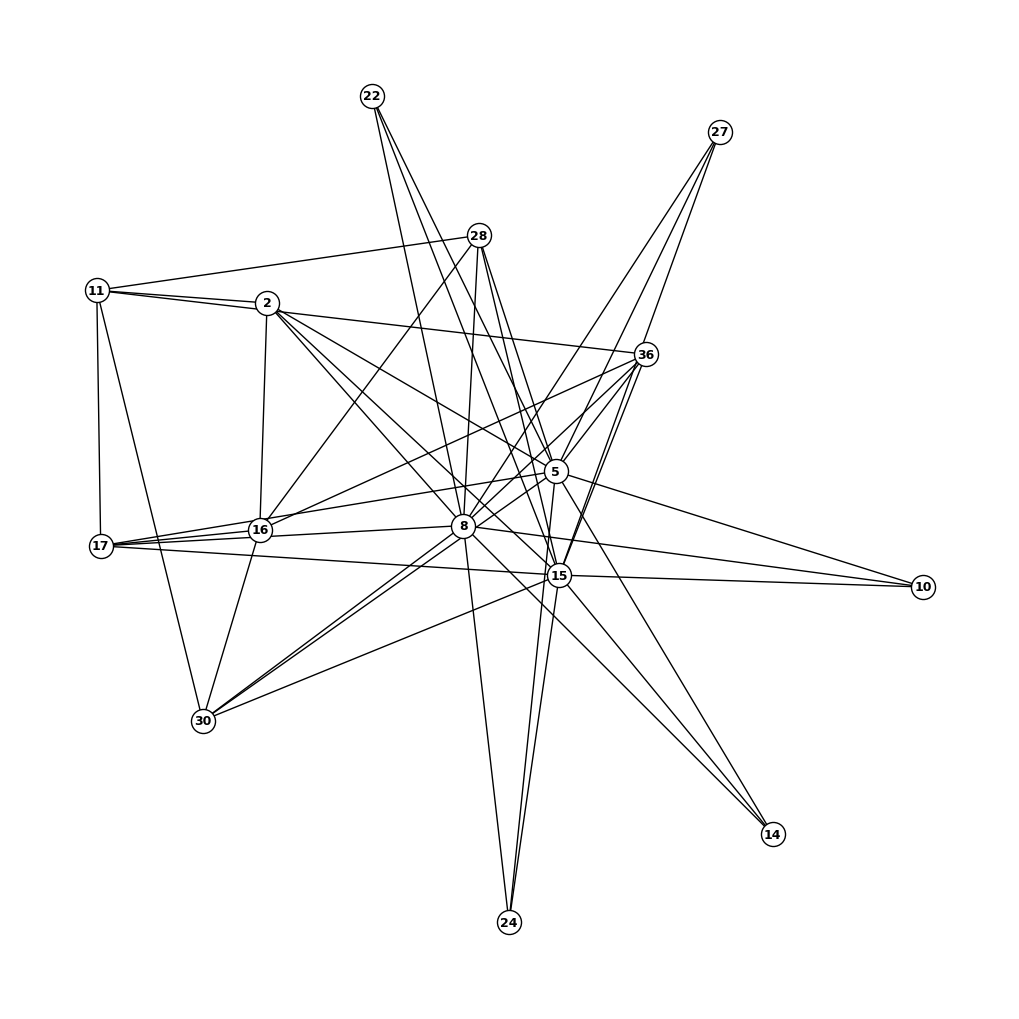

In [ ]:
plt.figure(figsize=(10,10))
options = {
    "font_size": 9,
    "node_size": 300,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}
nx.draw(G, with_labels=True,font_weight='bold',**options)

In [ ]:
dicti={}
for k,v in nx.degree(G):
  dicti[k] = v/len(tr.author.value_counts())
dicti

{2: 0.125,
 5: 0.25,
 8: 0.25,
 11: 0.125,
 15: 0.25,
 16: 0.125,
 10: 0.075,
 14: 0.075,
 17: 0.125,
 22: 0.075,
 24: 0.075,
 27: 0.075,
 28: 0.125,
 30: 0.125,
 36: 0.125}

In [ ]:
for i,j in zip(range(len(tr.author.value_counts())),np.mean(b,axis=0)):
  if i in dicti:
    dicti[i] = dicti[i]*j
  else:
    dicti[i] = j*0.01
#dicti

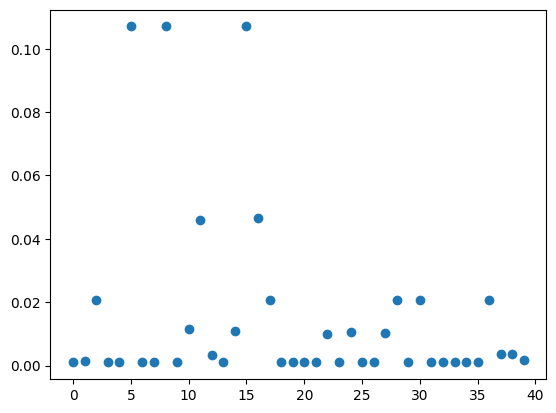

In [ ]:
tmp2 = {k: float(v) for k, v in sorted(dicti.items(), key=lambda item: item[0], reverse=False)}
plt.scatter(list(tmp2.keys()),list(tmp2.values()))

In [ ]:
topic_divergence_sensitivity = np.array(list(tmp2.values()))
np.save("scitific_arts_80doc40auth_topic_div_sensi.npy",topic_divergence_sensitivity)

In [ ]:
#nx.degree(G)
{k: float(v) for k, v in sorted(dict(nx.degree(G)).items(), key=lambda item: item[1], reverse=True)}

{5: 10.0,
 8: 10.0,
 15: 10.0,
 2: 5.0,
 11: 5.0,
 16: 5.0,
 17: 5.0,
 28: 5.0,
 30: 5.0,
 36: 5.0,
 10: 3.0,
 14: 3.0,
 22: 3.0,
 24: 3.0,
 27: 3.0}

In [ ]:
dicti

{2: np.float64(0.02060051117016617),
 5: np.float64(0.10701506907311009),
 8: np.float64(0.10701506907311009),
 11: np.float64(0.046087667809514996),
 15: np.float64(0.10701506907311009),
 16: np.float64(0.046498695568343615),
 10: np.float64(0.01143978265064437),
 14: np.float64(0.010846945203630014),
 17: np.float64(0.02060051117016617),
 22: np.float64(0.00988756972127112),
 24: np.float64(0.010515735710589528),
 27: np.float64(0.010199512927359876),
 28: np.float64(0.02060051117016617),
 30: np.float64(0.02060051117016617),
 36: np.float64(0.02060051117016617),
 0: np.float64(0.001087523947248675),
 1: np.float64(0.0012974162182832415),
 3: np.float64(0.0010781247545148492),
 4: np.float64(0.0010808896469969224),
 6: np.float64(0.0011301355544240477),
 7: np.float64(0.0010365281041482973),
 9: np.float64(0.001080032179995734),
 12: np.float64(0.0032487322880536905),
 13: np.float64(0.0009874910075462718),
 18: np.float64(0.0010368001867801146),
 19: np.float64(0.001014710629712002)

In [ ]:
tr[tr['auth_labl'].isin([5,8,15])]

,text,author,auth_labl
10,Mycobacterium tuberculosis (M.tb) is the causa...,206,5
11,The global burden of tuberculosis (TB) is vast...,206,5
16,Cholera is an acute diarrhoeal infection cause...,165,8
17,Cholera remains a major public health problem ...,165,8
30,"Tuberculosis (TB), an infectious disease cause...",104,15
31,"Tuberculosis (TB), an infectious disease cause...",104,15


In [ ]:
tr.iloc[[30,31]]['text'].values

array(['Tuberculosis (TB), an infectious disease caused by Mycobacterium tuberculosis (Mtb), remains one of the world’s deadliest communicable diseases, with 1.5 million deaths annually []. Due to the emergence of multidrug-resistant Mtb strains, co-infection with HIV, and the failure of BCG vaccine to control adult pulmonary TB [, ], there is an urgent need for new and more effective TB vaccines. However, achieving this goal relies on further investigation of the properties of protective T cells during Mtb infection [].',
       'Tuberculosis (TB), an infectious disease caused by Mycobacterium tuberculosis (Mtb) infection, remains a leading cause of morbidity and mortality worldwide . CD4+ and CD8+ T cells may be important for host immune resistance to TB in humans , , , . In mouse models of Mtb infection, IFN-γ and TNF-α produced by CD4+ and CD8+ T cells have been shown to be critical for immune control of Mtb infection , , .'],
      dtype=object)

In [ ]:
tr.iloc[[2,11,16]]['text'].values

array(['Osteoporosis is an important global issue with the growing aging population. In the United States, an estimated 9 million adults have osteoporosis and at least 48 million adults have an increased risk of osteoporosis related to low bone mass []. Bisphosphonates, a class of drugs which decrease osteoclast-mediated bone resorption, are often prescribed to prevent and treat osteoporosis []. When not taken as instructed (i.',
       'The global burden of tuberculosis (TB) is vast, with an estimated 8.6 million new TB cases and 1.3 million deaths due to the disease in 2012 , . Challenges in global TB control include human immunodeficiency virus (HIV)/TB co-infection and lack of effective vaccines and point of care diagnostics . Also, there are no well-validated or specific biomarkers that can predict transition from latent TB to active TB disease or are useful to monitor efficacy of anti-TB drugs , .',
       'Cholera is an acute diarrhoeal infection caused by ingestion of the bacte

In [ ]:
a,b = np.mean(KL),np.array(KL)
np.percentile(b.reshape(230*230),95) #230 auths 272 docs (imbalanced, no dups), scit articles

np.float64(0.6931471805599453)

In [ ]:
seti = set()
listi = []
dictii={}
for i in range(len(tr.author.value_counts())):
  for j in range(len(tr.author.value_counts())):
    if b[i,j]>=0.65229:
      tmp = tuple((i,j))
      #if (j,i) not in listi:

      listi.append(tmp)

#seti.update(listi)
#listi

In [ ]:
import networkx as nx
G = nx.Graph()
G.add_edges_from(listi)

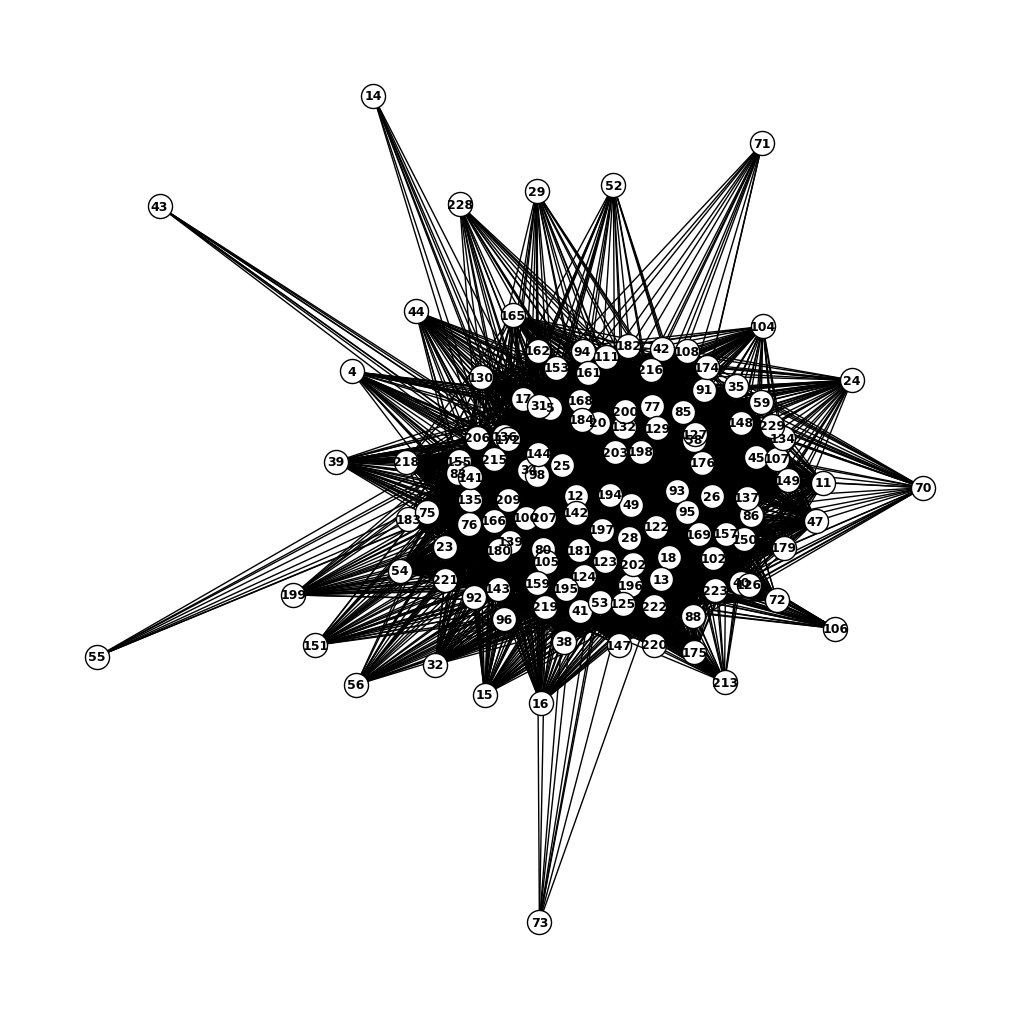

In [ ]:
plt.figure(figsize=(10,10))
options = {
    "font_size": 9,
    "node_size": 300,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}
nx.draw(G, with_labels=True,font_weight='bold',**options)

In [ ]:
dicti={}
for k,v in nx.degree(G):
  dicti[k] = v/230
dicti

{4: 0.17391304347826086,
 5: 0.4391304347826087,
 12: 0.4260869565217391,
 17: 0.4391304347826087,
 18: 0.4260869565217391,
 20: 0.4391304347826087,
 25: 0.5043478260869565,
 28: 0.4260869565217391,
 31: 0.4391304347826087,
 34: 0.5043478260869565,
 49: 0.4260869565217391,
 58: 0.4391304347826087,
 76: 0.4260869565217391,
 77: 0.4391304347826087,
 80: 0.4260869565217391,
 85: 0.4391304347826087,
 98: 0.5043478260869565,
 100: 0.4260869565217391,
 122: 0.4260869565217391,
 124: 0.4260869565217391,
 127: 0.4391304347826087,
 129: 0.4391304347826087,
 132: 0.4391304347826087,
 135: 0.4260869565217391,
 136: 0.5043478260869565,
 139: 0.4260869565217391,
 144: 0.5043478260869565,
 155: 0.4260869565217391,
 166: 0.4260869565217391,
 168: 0.4391304347826087,
 172: 0.5043478260869565,
 184: 0.4391304347826087,
 194: 0.4260869565217391,
 196: 0.4260869565217391,
 198: 0.4391304347826087,
 200: 0.4391304347826087,
 202: 0.4260869565217391,
 203: 0.4391304347826087,
 206: 0.5043478260869565,
 209

In [ ]:
for i,j in zip(range(230),np.mean(b,axis=0)):
  if i in dicti:
    dicti[i] = dicti[i]*j
  else:
    dicti[i] = j*0.01
#dicti

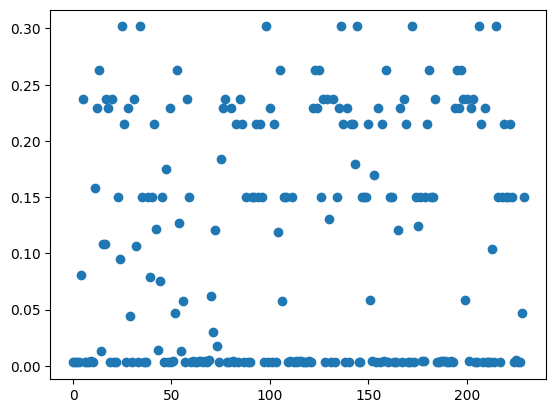

In [ ]:
tmp2 = {k: float(v) for k, v in sorted(dicti.items(), key=lambda item: item[0], reverse=False)}
plt.scatter(list(tmp2.keys()),list(tmp2.values()))

In [ ]:
topic_divergence_sensitivity = np.array(list(tmp2.values()))
np.save("scitific_arts_272doc230auth_topic_div_sensi.npy",topic_divergence_sensitivity)

In [ ]:
tmp2[25]

0.30178650267087626

In [ ]:
tr.author.value_counts()[:40].index

Index([185,  37, 154,  67, 184, 206, 137, 111, 165,  30,  76, 128, 142, 129,
       225, 104,  47,   0, 145,  60,  13, 109, 222,  42,   1, 167, 132, 148,
       194, 211,  89,  93,  71, 180, 190, 126,  40, 227, 118, 122],
      dtype='int64', name='author')

In [ ]:
tr[tr['author'].isin([25,34,98,136,144,172,206,215])]

,text,author
1,Infiltration of T cells into tumors has been c...,34
5,Mycobacterium tuberculosis (M.tb) is the causa...,206
41,The supply of n-3 long chain polyunsaturated f...,136
90,Breast cancer is recognized as the most freque...,98
109,Gastric cancer is the fifth common form of can...,215
142,Targeted therapies significantly increase the ...,172
172,Fatty liver disease (FLD) is caused by the exc...,144
192,There is an urgent need to identify new drugs ...,25
217,The global burden of tuberculosis (TB) is vast...,206


In [ ]:
#nx.degree(G)
{k: float(v) for k, v in sorted(dict(nx.degree(G)).items(), key=lambda item: item[1], reverse=True)}

{25: 116.0,
 34: 116.0,
 98: 116.0,
 136: 116.0,
 144: 116.0,
 172: 116.0,
 206: 116.0,
 215: 116.0,
 13: 107.0,
 53: 107.0,
 105: 107.0,
 123: 107.0,
 125: 107.0,
 159: 107.0,
 181: 107.0,
 195: 107.0,
 197: 107.0,
 5: 101.0,
 17: 101.0,
 20: 101.0,
 31: 101.0,
 58: 101.0,
 77: 101.0,
 85: 101.0,
 127: 101.0,
 129: 101.0,
 132: 101.0,
 168: 101.0,
 184: 101.0,
 198: 101.0,
 200: 101.0,
 203: 101.0,
 12: 98.0,
 18: 98.0,
 28: 98.0,
 49: 98.0,
 76: 98.0,
 80: 98.0,
 100: 98.0,
 122: 98.0,
 124: 98.0,
 135: 98.0,
 139: 98.0,
 155: 98.0,
 166: 98.0,
 194: 98.0,
 196: 98.0,
 202: 98.0,
 209: 98.0,
 26: 95.0,
 41: 95.0,
 83: 95.0,
 86: 95.0,
 93: 95.0,
 95: 95.0,
 102: 95.0,
 137: 95.0,
 141: 95.0,
 142: 95.0,
 150: 95.0,
 157: 95.0,
 169: 95.0,
 180: 95.0,
 207: 95.0,
 219: 95.0,
 222: 95.0,
 75: 83.0,
 143: 83.0,
 23: 76.0,
 35: 76.0,
 38: 76.0,
 40: 76.0,
 45: 76.0,
 59: 76.0,
 88: 76.0,
 91: 76.0,
 92: 76.0,
 94: 76.0,
 96: 76.0,
 107: 76.0,
 108: 76.0,
 111: 76.0,
 126: 76.0,
 134: 76.

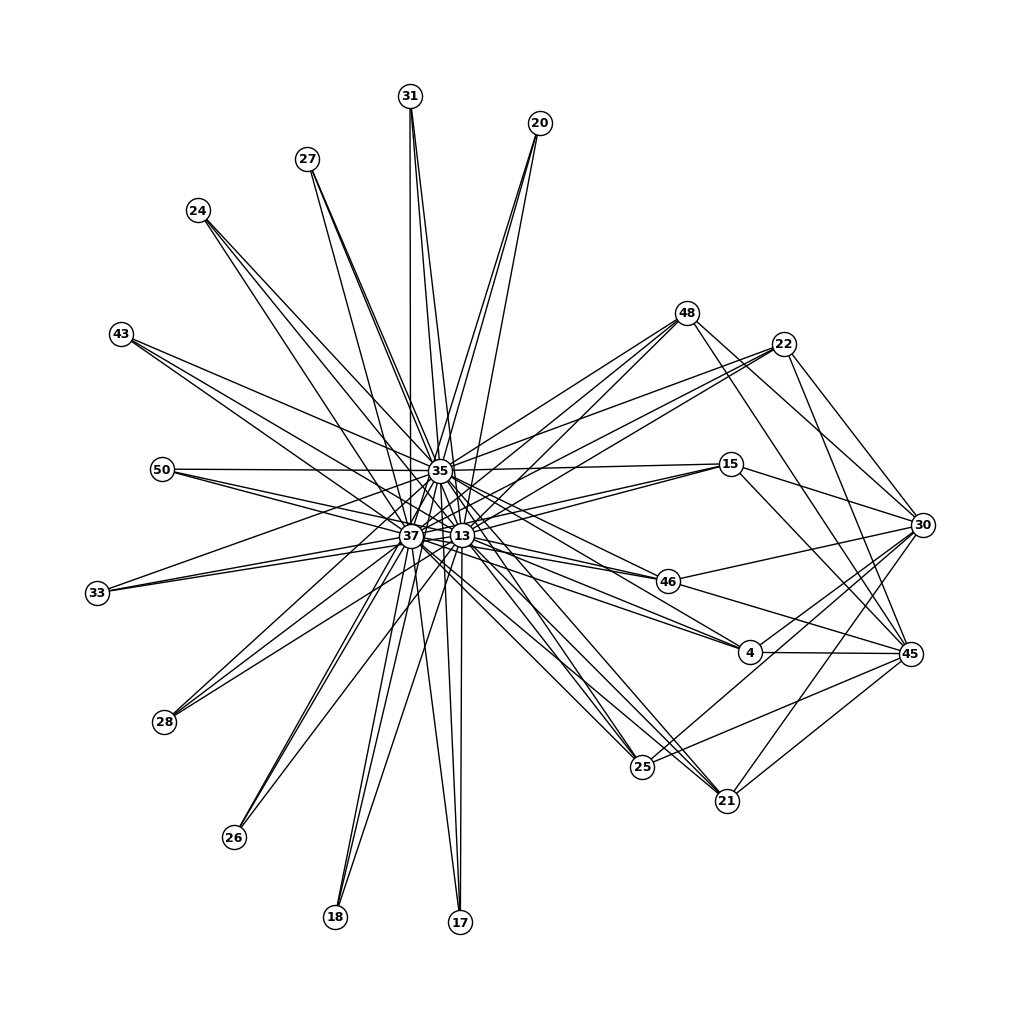

In [ ]:
plt.figure(figsize=(10,10))
options = {
    "font_size": 9,
    "node_size": 300,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}
nx.draw(G, with_labels=True,font_weight='bold',**options)

In [ ]:
dicti={}
for k,v in nx.degree(G):
  dicti[k] = v/51
dicti

{4: 0.09803921568627451,
 13: 0.35294117647058826,
 30: 0.13725490196078433,
 35: 0.35294117647058826,
 37: 0.35294117647058826,
 45: 0.13725490196078433,
 15: 0.09803921568627451,
 17: 0.058823529411764705,
 18: 0.058823529411764705,
 20: 0.058823529411764705,
 21: 0.09803921568627451,
 22: 0.09803921568627451,
 24: 0.058823529411764705,
 25: 0.09803921568627451,
 26: 0.058823529411764705,
 27: 0.058823529411764705,
 28: 0.058823529411764705,
 31: 0.058823529411764705,
 33: 0.058823529411764705,
 43: 0.058823529411764705,
 46: 0.09803921568627451,
 48: 0.09803921568627451,
 50: 0.058823529411764705}

In [ ]:
for i,j in zip(range(51),np.mean(b,axis=0)):
  if i in dicti:
    dicti[i] = dicti[i]*j
  else:
    dicti[i] = j*0.01
dicti

{4: np.float64(0.012257046143261209),
 13: np.float64(0.17997737081902662),
 30: np.float64(0.06562294032319327),
 35: np.float64(0.17997737081902662),
 37: np.float64(0.17997737081902662),
 45: np.float64(0.065922358661075),
 15: np.float64(0.012257046143261209),
 17: np.float64(0.006750632553050665),
 18: np.float64(0.006544737205543002),
 20: np.float64(0.006742147963941481),
 21: np.float64(0.012257046143261209),
 22: np.float64(0.012257046143261209),
 24: np.float64(0.006623623708666973),
 25: np.float64(0.012257046143261209),
 26: np.float64(0.00660391023466852),
 27: np.float64(0.0067681642368985565),
 28: np.float64(0.00663671492498644),
 31: np.float64(0.006646929668942923),
 33: np.float64(0.006681236163085772),
 43: np.float64(0.006574575062216742),
 46: np.float64(0.012257046143261209),
 48: np.float64(0.012257046143261209),
 50: np.float64(0.006559066839363495),
 0: np.float64(0.0010462872439221007),
 1: np.float64(0.004562057731508486),
 2: np.float64(0.000955830362046268

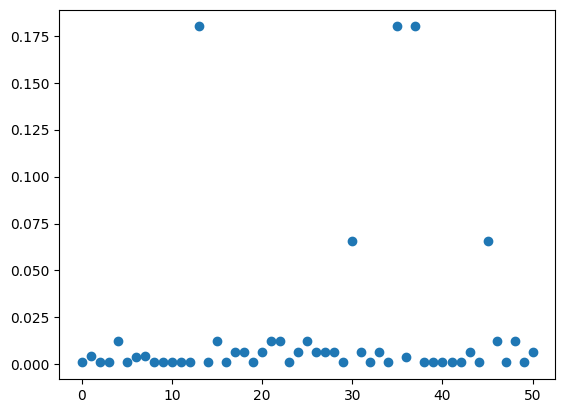

In [ ]:
tmp2 = {k: float(v) for k, v in sorted(dicti.items(), key=lambda item: item[0], reverse=False)}
plt.scatter(list(tmp2.keys()),list(tmp2.values()))

In [ ]:
topic_divergence_sensitivity = np.array(list(tmp2.values()))
np.save("plosone2doc51auth_topic_div_sensi.npy",topic_divergence_sensitivity)

In [ ]:
tmp2

{0: 0.0010462872439221007,
 1: 0.004562057731508486,
 2: 0.0009558303620462681,
 3: 0.0010119193708988728,
 4: 0.012257046143261209,
 5: 0.0009778420491632378,
 6: 0.004085666747526597,
 7: 0.004537908586552517,
 8: 0.0010328869786762611,
 9: 0.0010647442046979327,
 10: 0.001034915341602126,
 11: 0.0009556007748986048,
 12: 0.001031016539959166,
 13: 0.17997737081902662,
 14: 0.0009807826247236033,
 15: 0.012257046143261209,
 16: 0.0009645637031512762,
 17: 0.006750632553050665,
 18: 0.006544737205543002,
 19: 0.000993461595942601,
 20: 0.006742147963941481,
 21: 0.012257046143261209,
 22: 0.012257046143261209,
 23: 0.0009647675056550432,
 24: 0.006623623708666973,
 25: 0.012257046143261209,
 26: 0.00660391023466852,
 27: 0.0067681642368985565,
 28: 0.00663671492498644,
 29: 0.0010197566205571227,
 30: 0.06562294032319327,
 31: 0.006646929668942923,
 32: 0.0009561268957607995,
 33: 0.006681236163085772,
 34: 0.0010341188356939185,
 35: 0.17997737081902662,
 36: 0.00405737381710601,
 37

In [ ]:
[13,30,35,37,45]

In [ ]:
tr[tr['author'].isin([13,30,33])]['text'].values

array(['Obstructive sleep apnea (OSA) is a highly prevalent disorder affecting between 10–50% of middle-aged men []. OSA is characterized by recurrent upper airway obstruction associated with cyclic changes in oxyhemoglobin saturation, intermittent arousals from sleep and alterations in intrathoracic pressure. These alterations induce oxidative stress, sympathetic activation, and metabolic dysregulation [].',
       'Liver transplantation is presently the only proven treatment for many liver diseases but is not exempt from complications, thus increasing the need for a new approach using exogenous cell transplantation to restore liver functions[]. Experiments on animals have been performed to establish models and methodologies for liver repopulation using cells other than adult hepatocytes, including hepatic cell lines and hematopoietic, cord blood, mesenchymal stem cells, hepatic stem cells [].',
       'Obstructive sleep apnea (OSA) is highly prevalent, with approximately 20% of males

In [ ]:
seti = set()
listi = []
dictii={}
for i in range(50):
  for j in range(50):
    if b[i,j]>=0.5757:
      tmp = tuple((i,j))
      #if (j,i) not in listi:

      listi.append(tmp)

#seti.update(listi)
listi

[(0, 14),
 (0, 19),
 (0, 24),
 (0, 25),
 (0, 47),
 (1, 14),
 (1, 25),
 (1, 27),
 (1, 35),
 (2, 14),
 (2, 19),
 (2, 25),
 (2, 27),
 (2, 35),
 (2, 47),
 (5, 14),
 (5, 19),
 (5, 23),
 (5, 25),
 (5, 27),
 (5, 35),
 (5, 45),
 (5, 47),
 (6, 47),
 (7, 25),
 (7, 47),
 (12, 47),
 (13, 47),
 (14, 0),
 (14, 1),
 (14, 2),
 (14, 5),
 (14, 24),
 (14, 35),
 (14, 47),
 (17, 47),
 (18, 47),
 (19, 0),
 (19, 2),
 (19, 5),
 (19, 24),
 (19, 35),
 (19, 47),
 (20, 47),
 (21, 47),
 (23, 5),
 (23, 25),
 (23, 47),
 (24, 0),
 (24, 14),
 (24, 19),
 (24, 25),
 (24, 27),
 (24, 35),
 (25, 0),
 (25, 1),
 (25, 2),
 (25, 5),
 (25, 7),
 (25, 23),
 (25, 24),
 (25, 35),
 (25, 47),
 (27, 1),
 (27, 2),
 (27, 5),
 (27, 24),
 (27, 35),
 (27, 47),
 (28, 47),
 (29, 47),
 (30, 47),
 (31, 47),
 (32, 47),
 (33, 47),
 (35, 1),
 (35, 2),
 (35, 5),
 (35, 14),
 (35, 19),
 (35, 24),
 (35, 25),
 (35, 27),
 (35, 37),
 (35, 45),
 (35, 47),
 (36, 47),
 (37, 35),
 (39, 47),
 (40, 47),
 (42, 47),
 (44, 47),
 (45, 5),
 (45, 35),
 (45, 47),
 (

In [ ]:
import networkx as nx
G = nx.Graph()

In [ ]:
G.add_edges_from(listi)

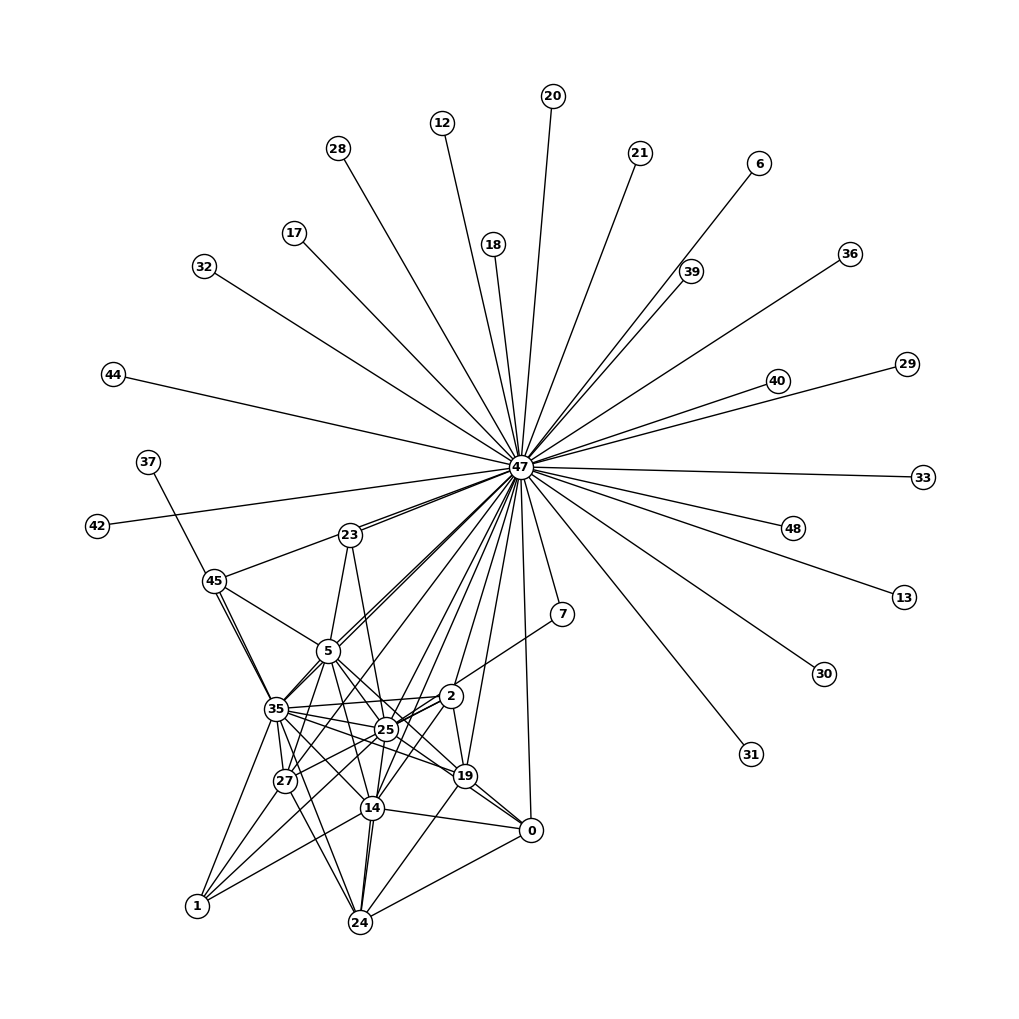

In [ ]:
plt.figure(figsize=(10,10))
options = {
    "font_size": 9,
    "node_size": 300,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 1,
    "width": 1,
}
nx.draw(G, with_labels=True,font_weight='bold',**options)

In [ ]:
from networkx.algorithms import approximation as appr

In [ ]:
import pprint  # for nice dictionary formatting
pprint.pprint(nx.all_pairs_node_connectivity(G))

{0: {1: 4,
     2: 5,
     5: 5,
     6: 1,
     7: 2,
     12: 1,
     13: 1,
     14: 5,
     17: 1,
     18: 1,
     19: 5,
     20: 1,
     21: 1,
     23: 3,
     24: 5,
     25: 5,
     27: 5,
     28: 1,
     29: 1,
     30: 1,
     31: 1,
     32: 1,
     33: 1,
     35: 5,
     36: 1,
     37: 1,
     39: 1,
     40: 1,
     42: 1,
     44: 1,
     45: 3,
     47: 5,
     48: 1},
 1: {0: 4,
     2: 4,
     5: 4,
     6: 1,
     7: 2,
     12: 1,
     13: 1,
     14: 4,
     17: 1,
     18: 1,
     19: 4,
     20: 1,
     21: 1,
     23: 3,
     24: 4,
     25: 4,
     27: 4,
     28: 1,
     29: 1,
     30: 1,
     31: 1,
     32: 1,
     33: 1,
     35: 4,
     36: 1,
     37: 1,
     39: 1,
     40: 1,
     42: 1,
     44: 1,
     45: 3,
     47: 4,
     48: 1},
 2: {0: 5,
     1: 4,
     5: 6,
     6: 1,
     7: 2,
     12: 1,
     13: 1,
     14: 6,
     17: 1,
     18: 1,
     19: 6,
     20: 1,
     21: 1,
     23: 3,
     24: 6,
     25: 6,
     27: 6,
     28: 1,
     

In [ ]:
nx.dominating_set(G)

{0,
 1,
 2,
 5,
 6,
 7,
 12,
 13,
 17,
 18,
 20,
 21,
 28,
 29,
 30,
 31,
 32,
 33,
 36,
 37,
 39,
 40,
 42,
 44,
 48}

In [ ]:
nx.average_node_connectivity(G)

1.5686274509803921

In [ ]:
from networkx.algorithms.connectivity import local_edge_connectivity
local_edge_connectivity(G,0,5)

5

In [ ]:
nx.local_efficiency(G),nx.global_efficiency(G)

(0.30439795911398343, 0.5383244206773614)

In [ ]:
dicti={}
for k,v in nx.degree(G):
  dicti[k] = v/49
dicti

{0: 0.10204081632653061,
 14: 0.14285714285714285,
 19: 0.12244897959183673,
 24: 0.12244897959183673,
 25: 0.1836734693877551,
 47: 0.6122448979591837,
 1: 0.08163265306122448,
 27: 0.12244897959183673,
 35: 0.22448979591836735,
 2: 0.12244897959183673,
 5: 0.16326530612244897,
 23: 0.061224489795918366,
 45: 0.061224489795918366,
 6: 0.02040816326530612,
 7: 0.04081632653061224,
 12: 0.02040816326530612,
 13: 0.02040816326530612,
 17: 0.02040816326530612,
 18: 0.02040816326530612,
 20: 0.02040816326530612,
 21: 0.02040816326530612,
 28: 0.02040816326530612,
 29: 0.02040816326530612,
 30: 0.02040816326530612,
 31: 0.02040816326530612,
 32: 0.02040816326530612,
 33: 0.02040816326530612,
 37: 0.02040816326530612,
 36: 0.02040816326530612,
 39: 0.02040816326530612,
 40: 0.02040816326530612,
 42: 0.02040816326530612,
 44: 0.02040816326530612,
 48: 0.02040816326530612}

In [ ]:
0.102/2

0.051

In [ ]:
for i,j in zip(range(50),np.mean(b_i,axis=0)):
  if i in dicti:
    dicti[i] = dicti[i]*j
  else:
    dicti[i] = j*0.01
dicti

{0: np.float64(0.048550413383322916),
 14: np.float64(0.07032613174599427),
 19: np.float64(0.06085545313378017),
 24: np.float64(0.0643864687623588),
 25: np.float64(0.09408365746962988),
 47: np.float64(0.34037014844439545),
 1: np.float64(0.04229574342568418),
 27: np.float64(0.06235513531426939),
 35: np.float64(0.11587600200480178),
 2: np.float64(0.066172188542709),
 5: np.float64(0.08904060078393765),
 23: np.float64(0.029999953804983392),
 45: np.float64(0.029032034475472833),
 6: np.float64(0.009363935247458172),
 7: np.float64(0.0191262873401777),
 12: np.float64(0.009887968707646449),
 13: np.float64(0.01008305185510045),
 17: np.float64(0.008913794932502555),
 18: np.float64(0.009402252576940507),
 20: np.float64(0.009788685005489604),
 21: np.float64(0.00890535214099838),
 28: np.float64(0.009373283197622262),
 29: np.float64(0.008875535867375235),
 30: np.float64(0.009527754396974245),
 31: np.float64(0.009078992351255038),
 32: np.float64(0.009184532739129152),
 33: np.f

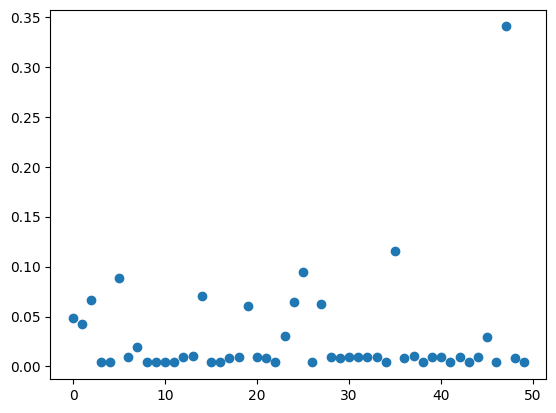

In [ ]:
tmp2 = {k: float(v) for k, v in sorted(dicti.items(), key=lambda item: item[0], reverse=False)}
plt.scatter(list(tmp2.keys()),list(tmp2.values()))

In [ ]:
topic_divergence_sensitivity = np.array(list(tmp2.values()))
np.save("ccat50_topic_div_sensi.npy",topic_divergence_sensitivity)

In [ ]:
tr

,text,author
0,U.S. Vice-President Al Gore could visit China ...,43
1,The right-wing Czech coalition government ende...,18
2,Ivory Coast has received three formal proposal...,32
3,British-based drugs group Medeva Plc said on W...,19
4,The U.S.-Australian development of the giant B...,4
...,...,...
3995,Japan Airlines (JAL) is expanding its new expr...,15
3996,China blamed criminal elements on Sunday for a...,49
3997,China has agreed not to enforce a ban on impor...,27
3998,The family of jailed Chinese dissident Wei Jin...,34


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
#tr_corpus = tr['text'].apply
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(tr_corpus2)
fs = vectorizer.get_feature_names_out()
tf_tr = pd.DataFrame(X.toarray(),columns=fs)
tf_tr

,aa,aaa,aaeu,aama,aan,aaron,aart,ab,aba,abandon,...,zuoyi,zurich,zuyao,zwanziger,zwetchenbaum,zwetchkenbaum,zx,zygmunt,zyprexa,zyrtec
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.feature_selection import mutual_info_classif
mutual_info_classif(tf_tr, tr.author.values)

KeyboardInterrupt: 

## flair embeds test - CCAT 50

In [ ]:
tr = pd.read_csv('/content/TRAIN 80-20 CAT 50 STYLOMETRIX_AND_SENT_AGG_LABELS.csv',index_col='Unnamed: 0')
te = pd.read_csv('/content/TEST 80-20 CAT 50 STYLOMETRIX_AND_SENT_AGG_LABELS.csv',index_col='Unnamed: 0')
tr

,text,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,POS_NUM,...,ASM,OM,RCI,DMC,OR,QAS,PA,PR,sent_transformer_aggcluster_labels,author
2163,U.S. Vice-President Al Gore could visit China ...,0.185751,0.195929,0.071247,0.030534,0.078880,0.000000,0.061069,0.043257,0.015267,...,0.002545,0.000000,0.0,0.002545,0.000000,0.043257,0.002545,0.0,1,43
3385,The right-wing Czech coalition government ende...,0.185393,0.193820,0.095506,0.030899,0.132022,0.000000,0.030899,0.033708,0.011236,...,0.005618,0.011236,0.0,0.005618,0.000000,0.095506,0.005618,0.0,0,18
4101,Ivory Coast has received three formal proposal...,0.181197,0.285470,0.075214,0.018803,0.063248,0.000000,0.032479,0.027350,0.064957,...,0.001709,0.001709,0.0,0.005128,0.005128,0.034188,0.003419,0.0,0,32
3418,British-based drugs group Medeva Plc said on W...,0.163043,0.219203,0.057971,0.025362,0.094203,0.000000,0.056159,0.019928,0.048913,...,0.000000,0.005435,0.0,0.001812,0.000000,0.083333,0.000000,0.0,0,19
2720,The U.S.-Australian development of the giant B...,0.185484,0.204839,0.067742,0.019355,0.122581,0.000000,0.051613,0.025806,0.069355,...,0.000000,0.000000,0.0,0.006452,0.000000,0.103226,0.001613,0.0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,Japan Airlines (JAL) is expanding its new expr...,0.157778,0.257778,0.091111,0.020000,0.084444,0.002222,0.044444,0.022222,0.024444,...,0.000000,0.002222,0.0,0.000000,0.000000,0.046667,0.000000,0.0,1,15
4971,China blamed criminal elements on Sunday for a...,0.184109,0.234496,0.087209,0.017442,0.112403,0.000000,0.038760,0.040698,0.023256,...,0.000000,0.003876,0.0,0.007752,0.000000,0.063953,0.000000,0.0,1,49
1366,China has agreed not to enforce a ban on impor...,0.181193,0.204128,0.059633,0.022936,0.075688,0.000000,0.059633,0.036697,0.016055,...,0.018349,0.004587,0.0,0.000000,0.000000,0.066514,0.002294,0.0,1,27
1718,The family of jailed Chinese dissident Wei Jin...,0.184725,0.214920,0.079929,0.024867,0.097691,0.000000,0.028419,0.031972,0.023091,...,0.001776,0.001776,0.0,0.005329,0.000000,0.063943,0.000000,0.0,1,34


In [ ]:
from flair.embeddings import TransformerDocumentEmbeddings
from flair.data import Sentence
# init embedding
embedding = TransformerDocumentEmbeddings('bert-base-uncased',layers="-1")

sentence = Sentence('The grass is green .')

# embed words in sentence
embedding.embed(sentence)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[Sentence[5]: "The grass is green ."]

In [ ]:
sentence.embedding.size()

torch.Size([768])

In [ ]:
tr_corpus=tr.text.values
te_corpus=te.text.values
s=Sentence(tr_corpus[0])
s

Sentence[437]: "U.S. Vice-President Al Gore could visit China in early 1997 if he was re-elected next month, a senior U.S. official said in Beijing on Saturday. "We have sent a proposal here and it's been reviewed and I don't think there's any real disagreement," U.S. Assistant Secretary of State for Oceans and International Environmental and Scientific Affairs Eileen Claussen said when asked if Gore had any plans to visit China. "The vice-president is very interested in trying to establish...a sustainable development forum here between (Chinese Premier) Li Peng and the vice-president," she told a news conference. No specific date has been set for Gore's visit. "We are now discussing terms of reference for that and there's every expectation that if those terms of reference are worked out, the vice-president will make a visit in the spring," she said. Asked to elaborate on the terms of reference, Claussen said: "We just have to have sort of a set of operating rules and subjects we're go

In [ ]:
embedding.embed(s)
s.embedding.size()

torch.Size([768])

In [ ]:
tr_lis=[]
for doc in tr_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  tr_lis.append(tmp.embedding)
tr_lis = np.array(tr_lis)
tr_lis.shape

(4000, 768)

In [ ]:
np.save("bert_base_uncased_ccat50_train.npy",tr_lis)

In [ ]:
tr_lis

array([[-0.6237901 , -0.4746582 , -0.7289688 , ..., -0.21951704,
         0.91329676,  0.11226951],
       [-1.2870274 , -0.54610807, -0.2652296 , ...,  0.6088875 ,
         0.8235748 ,  0.80457085],
       [-1.0393524 , -0.31276953, -0.17934918, ..., -0.05586929,
         0.6674643 , -0.09875611],
       ...,
       [-0.5978565 , -0.55412155, -0.6912632 , ...,  0.5326977 ,
         0.86792475,  0.15650856],
       [-0.89607763, -0.16014948, -0.3463263 , ...,  0.23819599,
         0.16274801,  0.45525464],
       [-1.1992273 , -0.5076651 , -0.7298012 , ...,  0.40810362,
         0.5319167 ,  0.01048373]], shape=(4000, 768), dtype=float32)

In [ ]:
te_lis=[]
for doc in te_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  te_lis.append(tmp.embedding)
te_lis = np.array(te_lis)
te_lis.shape

(1000, 768)

In [ ]:
np.save("bert_base_uncased_ccat50_test.npy",te_lis)

In [ ]:
tr_lis = np.load('/content/bert_base_uncased_ccat50_train.npy')
te_lis = np.load('/content/bert_base_uncased_ccat50_test.npy')

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [ ]:
clf = SVC(kernel='linear')
clf.fit(tr_lis,tr.author.values)
clf.score(te_lis,te.author.values)

0.799

In [ ]:
clf = SVC(kernel='linear')

In [ ]:
X = np.concatenate((tr_lis,te_lis),axis=0)

In [ ]:
y = np.concatenate((tr.author.values,te.author.values),axis=0)

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(clf, tr_lis,tr.author.values, cv=5)

array([0.7375 , 0.72625, 0.77875, 0.75   , 0.7575 ])

In [ ]:
np.array([0.7375 , 0.72625, 0.77875, 0.75   , 0.7575 ]).mean()

np.float64(0.75)

In [ ]:
cross_val_score(clf, X,y, cv=5)

array([0.769, 0.772, 0.795, 0.772, 0.799])

In [ ]:
np.array([0.769, 0.772, 0.795, 0.772, 0.799]).mean()

np.float64(0.7813999999999999)

In [ ]:
clf = RandomForestClassifier()
a = cross_val_score(clf, X,y, cv=5)
a, a.mean()

array([0.643, 0.649, 0.643, 0.672, 0.642])

In [ ]:
clf = LogisticRegression()
a = cross_val_score(clf, X,y, cv=5)
a, a.mean()

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

(array([0.78 , 0.791, 0.795, 0.781, 0.804]), np.float64(0.7902000000000001))

In [ ]:
clf = LogisticRegression(solver='sag',max_iter = 1000,random_state=101 )
a = cross_val_score(clf, X,y, cv=5)
a, a.mean()

(array([0.78 , 0.797, 0.801, 0.785, 0.813]), np.float64(0.7952))

In [ ]:
clf.fit(tr_lis,tr.author.values)
topic_pred = clf.predict(te_lis)
clf.score(te_lis,te.author.values)

0.813

In [ ]:
np.save("LR__sag_maxiter1000_rndm101__predicted_bert-base-uncased-cat50_test.npy",topic_pred)

In [ ]:
tr_ch = pd.read_csv('/content/CCAT50 TRAIN CHAR2-3-GRAM (1).csv')
te_ch = pd.read_csv('/content/CCAT50 TEST CHAR2-3-GRAM (1).csv')
tr_ch

,#,#,"#,",#-,#.,$,$,',(,(,...,ya,ye,yea,yi,yin,yo,ys,ys,yst,ze
0,4,2,0,0,2,0,0,1,1,1,...,0,2,1,1,1,0,0,0,0,1
1,3,3,0,0,0,0,0,0,3,3,...,0,1,1,0,0,0,1,0,1,2
2,43,28,12,0,2,0,0,0,3,3,...,0,7,5,0,0,0,2,2,0,3
3,19,16,1,0,1,2,2,0,1,1,...,0,5,5,0,0,3,0,0,0,1
4,30,15,1,6,8,4,4,1,4,4,...,0,2,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,9,8,0,0,0,0,0,1,1,1,...,3,2,1,2,1,2,4,1,1,0
3996,7,4,0,0,3,0,0,0,0,0,...,0,1,0,2,2,2,0,0,0,0
3997,6,5,1,0,0,1,1,0,2,2,...,0,0,0,0,0,1,0,0,0,0
3998,13,9,2,0,2,2,2,2,2,2,...,1,7,6,1,0,1,0,0,0,10


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [ ]:
sc.fit(tr_ch.values)
tr_ch_v = sc.transform(tr_ch.values)
te_ch_v = sc.transform(te_ch.values)

In [ ]:
clf2 = LogisticRegression(solver='sag',max_iter = 300,random_state=101 )
clf2.fit(tr_ch_v,tr.author.values)
char_pred = clf2.predict(te_ch_v)
char_pred_prob = clf2.predict_proba(te_ch_v)
clf2.score(te_ch_v,te.author.values) #last run = 23.2

KeyboardInterrupt: 

In [ ]:
clf2.coeff_

In [ ]:
np.save("LR__sag_maxiter300_rndm101__predicted_char2-3gram-cat50_test.npy",
        char_pred)

In [ ]:
tr_stylo = tr[tr.columns[1:-2]]
te_stylo = te[te.columns[1:-2]]
sc.fit(tr_stylo.values)
tr_stylo = sc.transform(tr_stylo.values)
te_stylo = sc.transform(te_stylo.values)

In [ ]:
clf3 = LogisticRegression(solver='sag',max_iter = 200,random_state=101 )
clf3.fit(tr_stylo,tr.author.values)
sty_pred = clf3.predict(te_stylo)
style_pred_prob = cl3.predict_proba(te_stylo)
clf3.score(te_stylo,te.author.values)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.562

In [ ]:
np.save("LR__sag_maxiter200_rndm101__predicted_stylometrix-sc-196-cat50_test.npy",
        sty_pred)

In [ ]:
dicti={}
dicti['topic_pred'] = np.load("/content/LR__sag_maxiter1000_rndm101__predicted_bert-base-uncased-cat50_test.npy")
dicti['hybrid_pred'] = np.load('/content/LR__sag_maxiter300_rndm101__predicted_char2-3gram-cat50_test.npy')
dicti['stylo_pred'] = np.load('LR__sag_maxiter100_rndm101__predicted_stylometrix-sc-196-cat50_test.npy')  #sagLRwith100iter score: 55.4  #sagLRwith200iter score: 56.2
#dicti['stylo_pred'] = sty_pred

In [ ]:
l=[] #STYLO WITH: dicti['stylo_pred'] = np.load('LR__lbfgs_maxiter200_rndm101__predicted_stylometrix-sc-196-cat50_test.npy')
y_test = te.author.values
true_lis=[]
for i,j,k,y in zip(dicti['stylo_pred'],dicti['hybrid_pred'],dicti['topic_pred'],y_test):
  if k==i:
    l.append(k)
  elif i==j:
    l.append(i)
  else:
    l.append(k) #using k here
  true_lis.append(l[-1]==y)
print(np.array(true_lis).sum())

810


In [ ]:
l=[] #STYLO WITH: dicti['stylo_pred'] = np.load('LR__sag_maxiter100_rndm101__predicted_stylometrix-sc-196-cat50_test.npy')
y_test = te.author.values
true_lis=[]
for i,j,k,y in zip(dicti['stylo_pred'],dicti['hybrid_pred'],dicti['topic_pred'],y_test):
  if k==i:
    l.append(k)
  elif i==j:
    l.append(i)
  else:
    l.append(k) #using k here
  true_lis.append(l[-1]==y)
print(np.array(true_lis).sum())

811


**CCAT 50 CONCLUSION: CROSS VAL SCORE OF BERT EMBEDDINGS - 79.54%, WHEREAS ONE-TIME PREDICTION IS 81.3%...STYLE PRED - 56.2% AND HYBRID (CHARN-GRAM) PREDICTION = 26..%  ENSEMBLE YIELDED 81.1%.        NOW THE QUESTION IS: IS IT BETTER TO STOP WITH TOPIC PRED ALONE OR TOPIC PRED COULD YIELD NOT THAT BETTER SCORE IN CROSS VAL SO SOMETIME ONE-TIME PRED COULD ALSO NOT BE THE HIGHEST THEN TO BOOST ACC YOU WILL NEED THE HELP OF OTHER FS IN ENSEMBLE?**
- Answer = 77.9%

In [ ]:
tr_lis = np.load('/content/bert_base_uncased_ccat50_train.npy')
te_lis = np.load('/content/bert_base_uncased_ccat50_test.npy')
all_trs = np.concatenate((tr_stylo,tr_ch_v,tr_lis),axis=1)
y_train = tr.author.values

In [ ]:
from sklearn.model_selection import train_test_split

all_tr = pd.DataFrame(all_trs,columns=[i for i in range(all_trs.shape[1])])
X_train, X_val, y_train, y_val = train_test_split(all_tr,y_train, test_size=0.20, stratify = y_train, random_state=42)
X_train.shape,X_val.shape,np.unique(y_val,return_counts=True)

((3200, 2964),
 (800, 2964),
 (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
         17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
         34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]),
  array([16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
         16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
         16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16])))

In [ ]:
x_tr_ind = list(X_train.index)
x_val_ind = list(X_val.index)

In [ ]:
clf = LogisticRegression(solver='sag',max_iter = 1000,random_state=101,verbose=1)
clf.fit(tr_lis[x_tr_ind,:],y_train)

pred_prob_topic = clf.predict_proba(tr_lis[x_val_ind,:])

convergence after 220 epochs took 120 seconds


In [ ]:
pred_topic_tr = clf.predict(tr_lis[x_val_ind,:])

In [ ]:
print(clf.score(tr_lis[x_val_ind,:],y_val)) #0.76375 - first time

0.76375


In [ ]:
sc = StandardScaler()
sc.fit(tr_ch.values)
tr_ch_v = sc.transform(tr_ch.values)
te_ch_v = sc.transform(te_ch.values)

In [ ]:
clf2 = LogisticRegression(solver='sag',max_iter = 300,random_state=101 )
clf2.fit(tr_ch_v[x_tr_ind,:],y_train)
pred_prob_char = clf2.predict_proba(tr_ch_v[x_val_ind,:])
clf2.score(tr_ch_v[x_val_ind,:],y_val)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.82875

In [ ]:
pred_char_tr = clf2.predict(tr_ch_v[x_val_ind,:])

In [ ]:
sc=StandardScaler()

In [ ]:
tr_stylo = tr[tr.columns[1:-2]]
te_stylo = te[te.columns[1:-2]]
sc.fit(tr_stylo.values)
tr_stylo = sc.transform(tr_stylo.values)
te_stylo = sc.transform(te_stylo.values)

In [ ]:
clf3 = LogisticRegression(solver='sag',max_iter = 200,random_state=101 )
clf3.fit(tr_stylo[x_tr_ind,:],y_train)
pred_prob_stylo = clf3.predict_proba(tr_stylo[x_val_ind,:])
clf3.score(tr_stylo[x_val_ind,:],y_val)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


0.5425

In [ ]:
pred_stylo_tr = clf3.predict(tr_stylo[x_val_ind,:])

In [ ]:
pred_prob_all_val = np.concatenate((pred_prob_topic,pred_prob_char,pred_prob_stylo),axis=1)
pred_prob_all_val_new = np.concatenate((pred_prob_topic,pred_topic_tr.reshape(-1,1),pred_prob_char,pred_char_tr.reshape(-1,1),pred_prob_stylo,pred_stylo_tr.reshape(-1,1)),axis=1)
pred_prob_topic_stylo_val_new = np.concatenate((pred_prob_topic,pred_topic_tr.reshape(-1,1),pred_prob_stylo,pred_stylo_tr.reshape(-1,1)),axis=1)

In [ ]:
clf4 = LogisticRegression()
clf4.fit(pred_prob_all_val,y_val)

LogisticRegression()

In [ ]:
y_test = te.author.values

In [ ]:
te_pred_prob_clf = clf.predict_proba(te_lis)
te_pred_prob_clf2 = clf2.predict_proba(te_ch_v)
te_pred_prob_clf3 = clf3.predict_proba(te_stylo)
te_all_pred_prob = np.concatenate((te_pred_prob_clf,te_pred_prob_clf2,te_pred_prob_clf3),axis=1)
clf4.score(te_all_pred_prob,y_test)

0.691

In [ ]:
te_pred_clf = clf.predict(te_lis)
te_pred_clf2 = clf2.predict(te_ch_v)
te_pred_clf3 = clf3.predict(te_stylo)
te_all_pred_prob_new = np.concatenate((te_pred_prob_clf,te_pred_clf.reshape(-1,1),te_pred_prob_clf2,te_pred_clf2.reshape(-1,1),te_pred_prob_clf3,te_pred_clf3.reshape(-1,1)),axis=1)

In [ ]:
np.array(te_pred_clf==y_test).sum()/len(y_test),np.array(te_pred_clf2==y_test).sum()/len(y_test),np.array(te_pred_clf3==y_test).sum()/len(y_test)

(np.float64(0.796), np.float64(0.225), np.float64(0.549))

In [ ]:
te_topic_stylo_pred_prob_new = np.concatenate((te_pred_prob_clf,te_pred_clf.reshape(-1,1),te_pred_prob_clf3,te_pred_clf3.reshape(-1,1)),axis=1)

In [ ]:
clf.score(te_lis,y_test),clf2.score(te_ch_v,y_test),clf3.score(te_stylo,y_test)

(0.796, 0.225, 0.549)

In [ ]:
clf5 = SVC()
clf5.fit(pred_prob_all_val,y_val)
clf5.score(te_all_pred_prob,y_test)

0.625

In [ ]:
models = lazy_fit(pred_prob_all_val, te_all_pred_prob, y_val, y_test)

In [ ]:
models #WITH DATA LEAK IN CHR-NGRAM(HYBRID) all three probas & for models = lazy_fit(pred_prob_all_val_new, te_all_pred_prob_new, y_val, y_test) same result

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.77,0.77,None,0.78,0.08
KNeighborsClassifier,0.70,0.70,None,0.72,0.10
SVC,0.70,0.70,None,0.72,0.27
NuSVC,0.69,0.69,None,0.72,0.45
SGDClassifier,0.69,0.69,None,0.69,0.26
LogisticRegression,0.67,0.67,None,0.68,2.90
LGBMClassifier,0.67,0.67,None,0.66,40.80
RandomForestClassifier,0.64,0.64,None,0.64,5.73
BernoulliNB,0.62,0.62,None,0.60,0.38


In [ ]:
models = lazy_fit(pred_prob_topic_stylo_val_new, te_topic_stylo_pred_prob_new, y_val, y_test)

In [ ]:
models #topic and stylo pred prob & pred concatenated set

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
RidgeClassifier,0.81,0.81,None,0.81,0.24
RidgeClassifierCV,0.81,0.81,None,0.81,0.37
ExtraTreesClassifier,0.81,0.81,None,0.81,0.40
RandomForestClassifier,0.81,0.81,None,0.80,2.98
NearestCentroid,0.80,0.80,None,0.80,0.03
LinearDiscriminantAnalysis,0.80,0.80,None,0.80,0.05
SVC,0.80,0.80,None,0.80,0.37
XGBClassifier,0.79,0.79,None,0.79,4.50
NuSVC,0.79,0.79,None,0.79,0.24


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
cross_val_score(rf, np.concatenate((pred_prob_topic_stylo_val_new, te_topic_stylo_pred_prob_new),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)

In [ ]:
np.array([0.78888889, 0.8       , 0.81111111, 0.8       , 0.79722222]).mean()

np.float64(0.799444444)

In [ ]:
np.save('pred_prob_and_pred_topic_stylo_val.npy',pred_prob_topic_stylo_val_new)
np.save('pred_prob_and_pred_topic_stylo_test.npy',te_topic_stylo_pred_prob_new)
np.save('y_val.npy',y_val)
np.save('y_train.npy',y_train)
np.save('pred_prob_and_pred_all_val.npy',pred_prob_all_val_new)
np.save('pred_prob_and_pred_all_test.npy',te_all_pred_prob_new)
np.save('val_index.npy',x_val_ind)
np.save('train_index.npy',x_tr_ind)

In [ ]:
[i for i in os.listdir('.') if i.endswith('.npy')]

['y_val.npy',
 'y_train.npy',
 'LR_sag_300maxiter_101rndm__pred_prob_test_ch-23gram.npy',
 'LR_sag_300maxiter_101rndm__pred_prob_val_ch-23gram.npy',
 'pred_prob_and_pred_all_val.npy',
 'LR_sag_300maxiter_101rndm__pred_test_ch-23gram.npy',
 'pred_prob_and_pred_topic_stylo_val.npy',
 'pred_prob_and_pred_topic_stylo_test.npy',
 'LR_sag_300maxiter_101rndm__pred_val_ch-23gram.npy',
 'y_test.npy',
 'pred_prob_and_pred_all_test.npy']

In [ ]:
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')
probs_preds_topic_stylo_val = np.load('pred_prob_and_pred_topic_stylo_val.npy')
probs_preds_topic_stylo_test = np.load('pred_prob_and_pred_topic_stylo_test.npy')
probs_preds_char_val = np.concatenate((np.load('LR_sag_300maxiter_101rndm__pred_prob_val_ch-23gram.npy'),np.load('LR_sag_300maxiter_101rndm__pred_val_ch-23gram.npy').reshape(-1,1)),axis=1)
probs_preds_char_test = np.concatenate((np.load('LR_sag_300maxiter_101rndm__pred_prob_test_ch-23gram.npy'),np.load('LR_sag_300maxiter_101rndm__pred_test_ch-23gram.npy').reshape(-1,1)),axis=1)
all_probs_and_preds_val = np.concatenate((probs_preds_topic_stylo_val,probs_preds_char_val),axis=1)
all_probs_and_preds_test = np.concatenate((probs_preds_topic_stylo_test,probs_preds_char_test),axis=1)
all_probs_and_preds_test.shape,all_probs_and_preds_val.shape

((1000, 153), (800, 153))

In [ ]:
np.save('pred_prob_and_pred_all_ccat50_test.npy',all_probs_and_preds_test)
np.save('pred_prob_and_pred_all_ccat50_val.npy',all_probs_and_preds_val)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
a = cross_val_score(rf, np.concatenate((probs_preds_topic_stylo_val, probs_preds_topic_stylo_test),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)
a, a.mean()

(array([0.80833333, 0.78055556, 0.79722222, 0.80833333, 0.78888889]),
 np.float64(0.7966666666666666))

In [ ]:
models = lazy_fit(all_probs_and_preds_val, all_probs_and_preds_test, y_val, y_test) #ALL 3 CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002443 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 38371
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 153
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM] [Info] Start training from score -3.912023
[LightGBM

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
ExtraTreesClassifier,0.81,0.81,None,0.80,0.97
RandomForestClassifier,0.80,0.80,None,0.79,3.99
LGBMClassifier,0.78,0.78,None,0.78,47.11
XGBClassifier,0.78,0.78,None,0.78,6.25
BaggingClassifier,0.76,0.76,None,0.76,14.60
DecisionTreeClassifier,0.64,0.64,None,0.64,1.01
LinearDiscriminantAnalysis,0.62,0.63,None,0.64,0.21
BernoulliNB,0.58,0.58,None,0.58,0.26
ExtraTreeClassifier,0.54,0.54,None,0.53,0.04


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
a = cross_val_score(rf, np.concatenate((all_probs_and_preds_val, all_probs_and_preds_test),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)
a, a.mean()

(array([0.79444444, 0.79166667, 0.81944444, 0.81111111, 0.8       ]),
 np.float64(0.8033333333333333))

In [ ]:
tmp=[]
for i,j,k in zip(pred_prob_topic[:,:],pred_prob_char[:,:],pred_prob_stylo[:,:]):
  tmp2=[]
  for l,m,n in zip(i,j,k):

    tmp2.append(np.mean([l,m,n]))
  tmp.append(int(np.argmax(tmp2)))
np.sum(tmp==y_test)

np.int64(779)


> **!! SOFT VOTING FAILED**



## flair embeds test - JUDGEMENT 3

In [ ]:
os.listdir('.')

['.config',
 'judgements_stylo_train_92sampled.csv',
 'judgements_stylo_val_56sampled.csv',
 'judgements_stylo_test_39sampled.csv',
 'sample_data']

In [ ]:
tr = pd.read_csv('judgements3_stylo_train_sampled_112.csv',index_col='Unnamed: 0')#,index_col='Unnamed: 0')
te = pd.read_csv('judgements3_stylo_test_sampled_37.csv',index_col='Unnamed: 0')#,index_col='Unnamed: 0')
val = pd.read_csv('judgements3_stylo_val_sampled_38.csv',index_col = 'Unnamed: 0')
#all = pd.concat((tr,val,te),axis=0,ignore_index=True)
#tr = all.iloc[tr_ind]
#val = all.iloc[val_ind]
#te = all.iloc[te_ind]
tr.author.value_counts(),te.author.value_counts(),val.author.value_counts()

(author
 0    112
 1    112
 2    112
 Name: count, dtype: int64,
 author
 0    37
 1    37
 2    37
 Name: count, dtype: int64,
 author
 0    38
 1    38
 2    38
 Name: count, dtype: int64)

In [ ]:
#tr.to_csv('judgements3_stylo_train_sampled_112.csv')
#val.to_csv('judgements3_stylo_val_sampled_38.csv')
#te.to_csv('judgements3_stylo_test_sampled_37.csv')

In [ ]:
from flair.embeddings import TransformerDocumentEmbeddings
from flair.data import Sentence
# init embedding
embedding = TransformerDocumentEmbeddings('bert-base-uncased',layers="-1")

sentence = Sentence('The grass is green .')

# embed words in sentence
embedding.embed(sentence)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[Sentence[5]: "The grass is green ."]

In [ ]:
sentence.embedding.size()

torch.Size([768])

In [ ]:
tr_corpus=tr.text.values
te_corpus=te.text.values
val_corpus = val.text.values
#s=Sentence(tr_corpus[0])
#s

In [ ]:
tr_lis=[]
for doc in tr_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  tr_lis.append(tmp.embedding)
tr_lis = np.array(tr_lis)
tr_lis.shape

(276, 768)

In [ ]:
np.save("bert_base_uncased_judgement3_train_96sampled.npy",tr_lis)

In [ ]:
tr_lis

array([[-0.66350096,  0.18810028, -0.55998653, ...,  0.25551167,
        -0.04096013,  0.518651  ],
       [-0.17788549, -0.14196585, -0.40698117, ..., -0.30391786,
        -0.8399163 ,  0.45915577],
       [-0.5331323 ,  0.14623332, -0.40058377, ...,  0.08500513,
        -0.24531393,  0.5561087 ],
       ...,
       [-0.15718363,  0.3551319 , -0.92533743, ...,  0.07459547,
        -0.00853277,  0.6548893 ],
       [-0.36833265,  0.20086735, -0.86693186, ..., -0.53999364,
        -0.2221645 ,  0.689676  ],
       [-0.3614687 ,  0.35640705, -0.7442756 , ...,  0.15049884,
        -0.18910076,  0.78484917]], shape=(1392, 768), dtype=float32)

In [ ]:
val_lis=[]
for doc in val_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  val_lis.append(tmp.embedding)
val_lis = np.array(val_lis)
print(val_lis.shape)
np.save("bert_base_uncased_judgement3_val_56sampled.npy",val_lis)

(168, 768)


In [ ]:
te_lis=[]
for doc in te_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  te_lis.append(tmp.embedding)
te_lis = np.array(te_lis)
te_lis.shape

(117, 768)

In [ ]:
np.save("bert_base_uncased_judgement3_test_39sampled.npy",te_lis)

In [ ]:
all_lis = pd.DataFrame(np.concatenate((tr_lis,val_lis,te_lis),axis=0),columns=list(range(768)))
all_lis['author'] = np.concatenate((tr.author.values,val.author.values,te.author.values))
all_lis

,0,1,2,3,4,5,6,7,8,9,...,759,760,761,762,763,764,765,766,767,author
0,-0.895211,-0.262843,-0.563140,-0.740844,0.462724,-0.220631,0.593694,0.699867,0.099080,0.349006,...,-0.519708,0.014468,-0.774942,-0.396144,-0.013827,-0.041143,0.072782,-0.305709,0.149066,0
1,-0.547136,-0.461946,-0.047711,-0.645456,0.635166,0.283028,0.264626,0.397645,-0.325522,-0.141632,...,-0.083110,0.419104,-0.604848,-0.004295,-0.124446,-0.407334,-0.288777,-0.022726,0.461149,0
2,-0.566415,0.074036,-0.922071,-0.923558,0.318038,0.186764,0.294086,0.668540,0.166061,0.183802,...,-0.284086,0.444520,-0.388063,-0.242444,-0.034296,-0.023693,0.100465,-0.156172,0.434176,0
3,-0.405689,-0.146788,-0.589728,-0.822532,0.561069,-0.072707,0.453595,0.524310,-0.167076,0.203290,...,-0.441310,0.009352,-0.334610,-0.159752,-0.286669,0.075854,0.073448,-0.494067,0.331830,0
4,-0.115572,0.153519,-0.583577,-0.631074,1.026732,-0.513072,0.373168,0.261864,0.035817,0.170005,...,-0.240343,0.911131,-0.491799,0.029527,-0.489456,0.528289,0.123688,-0.320297,0.497638,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,-0.279886,0.131591,-0.089386,-0.647929,0.436098,-0.236963,-0.149435,0.423809,0.198941,0.080426,...,-0.133175,0.610937,-0.818781,-0.141474,0.040084,0.470651,0.061717,0.008432,0.982107,2
557,-0.028375,0.146972,-0.714178,-0.469371,0.733322,-0.409280,0.348816,0.746331,-0.372310,0.288617,...,-0.254955,0.297723,-0.332086,0.352355,-0.244261,0.218481,-0.032123,-0.255892,0.813214,2
558,-0.518122,0.597852,-0.700545,-0.930596,0.395927,-0.054839,0.225490,0.379756,0.387364,0.220867,...,-0.123722,0.280376,-0.526570,-0.140093,-0.335752,0.390689,-0.234473,-0.067430,0.506505,2
559,-0.463265,0.349509,-0.806162,-0.287983,1.167897,-0.336300,0.319091,0.264478,-0.222851,-0.023803,...,-0.496675,0.343270,-0.793621,0.196280,-0.019994,0.318170,0.522310,-0.423981,0.602212,2


In [ ]:
#336,113,112
#tr = pd.concat((all_lis[all_lis.author==i].sample(112) for i in [0,1,2]))
#all_lis.drop(inplace=True,index=tr.index)
#val = pd.concat((all_lis[all_lis.author==i].sample(38) for i in [0,1,2]))
#all_lis.drop(inplace=True,index=val.index)
#te = pd.concat((all_lis[all_lis.author==i].sample(37) for i in [0,1,2]))
#all_lis.drop(inplace=True,index=te.index)
#all_lis

In [ ]:
#tr_ind = list(tr.index)
#val_ind = list(val.index)
#te_ind = list(te.index)
#np.save('judgement3_sample_tr_ind.npy',tr_ind)
#np.save('judgement3_sample_val_ind.npy',val_ind)
#np.save('judgement3_sample_te_ind.npy',te_ind)

In [ ]:
#tr_bert = all_lis.iloc[tr_ind]
#val_bert = all_lis.iloc[val_ind]
#te_bert = all_lis.iloc[te_ind]
#np.save('jusgement3_sampled_train_bert_base_uncased_112.npy',tr_bert.drop(columns='author',axis=1).values)
#np.save('jusgement3_sampled_val_bert_base_uncased_38.npy',val_bert.drop(columns='author',axis=1).values)
#np.save('jusgement3_sampled_test_bert_base_uncased_37.npy',te_bert.drop(columns='author',axis=1).values)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def hybrid_fs_get(corpus,model=None):
  if model:
    X = model.transform(corpus)
  else:
    vectorizer = CountVectorizer(analyzer='char',ngram_range=(2,3),max_features=2000)
    X = vectorizer.fit_transform(corpus)
  df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
  return df,model


def wordgram_fs_get(corpus,model=None):
  if model:
    X = model.transform(corpus)
  else:
    vectorizer = CountVectorizer(analyzer='word',ngram_range=(1,2),max_features=2000)
    X = vectorizer.fit_transform(corpus)
  df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
  return df,model

In [ ]:
infix_re = spacy.util.compile_infix_regex([r'''[~]'''])
tokenizer = spacy.tokenizer.Tokenizer(nlp.vocab, infix_finditer=infix_re.finditer)
nlp.tokenizer = tokenizer
stop_words = set(stopwords.words('english'))

RE_DIGITS = re.compile(r'\d+(th|st|nd|nth)|[\'`´‘]?\d+[\'`´‘]?s?\b|\d')
def clean_str2(sentence):
    sentence = RE_DIGITS.sub(r'#', sentence)
    sentence = re.sub("&amp;","",sentence)
    sentence = re.sub("^\\$|\d+", "#", sentence) #https://stackoverflow.com/questions/60741977/simplified-regex-to-remove-dollar-sign-and-anything-after-the-decimal-point-in-a
    sentence = re.sub(' +', ' ',sentence)
    sentence = re.sub("#+",'#',sentence)
    sentence = re.sub(r"([\w/'+$\s-]+|[^\w/'+$\s-]+)\s*", r"\1 ", sentence) #https://stackoverflow.com/questions/27810884/python-how-do-i-separate-punctuation-from-words-by-white-space-leaving-only-on
    #masked_sentence = re.sub(' +', ' ',sentence)
    word_tokens = word_tokenize(sentence)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    sentence = ' '.join(filtered_sentence)
    sentence = sentence.replace(" ,",",")
    sentence = sentence.replace(" . ",". ")
    sentence = sentence.replace(" .",".")
    sentence = sentence.replace(" - ","-")
    sentence = sentence.replace(" ; ","; ")
    sentence = re.sub(r'"\s*(.*?)\s*"', r'"\1"', sentence)

    #masked_sentence = re.sub(r'"\s*([^"]*?)\s*"',"\1",masked_sentence)

    sentence = sentence.replace(" ' ","'")
    sentence = sentence.replace(" 's","'s")
    sentence = sentence.replace("''",'')
    sentence = sentence.replace('""','')
    sentence = sentence.replace('``','')
    sentence = re.sub(r"\s{2,}", " ", sentence)

    return sentence


In [ ]:
tr_corpus = tr['text'].apply(clean_str2).values
te_corpus = te['text'].apply(clean_str2).values
val_corpus = val['text'].apply(clean_str2).values
tr_hybrid,vectorizer = hybrid_fs_get(tr_corpus)
val_hybrid,_ = hybrid_fs_get(val_corpus,model=vectorizer)
te_hybrid,_ = hybrid_fs_get(te_corpus,model=vectorizer)
tr_hybrid.shape,te_hybrid.shape,val_hybrid.shape

((336, 2000), (111, 2000), (114, 2000))

In [ ]:
tr_hybrid.to_csv('judgement3_train_112sampled_char23grm.csv',index=False)
val_hybrid.to_csv('judgement3_val_38sampled_char23grm.csv',index=False)
te_hybrid.to_csv('judgement3_test_37sampled_char23grm.csv',index=False)

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [ ]:
X = np.concatenate((tr_lis,val_lis,te_lis),axis=0)

In [ ]:
y = np.concatenate((tr.author.values,val.author.values,te.author.values),axis=0)

In [ ]:
clf = LogisticRegression(solver='sag',max_iter = 1000,random_state=101 )
a = cross_val_score(clf, X,y, cv=5)
a, a.mean()

(array([0.48672566, 0.53571429, 0.32142857, 0.42857143, 0.41071429]),
 np.float64(0.43663084702907706))

In [ ]:
tr_lis = np.load('jusgement3_sampled_train_bert_base_uncased_112.npy')
val_lis = np.load('jusgement3_sampled_val_bert_base_uncased_38.npy')
tes_lis = np.load('jusgement3_sampled_test_bert_base_uncased_37.npy')
clf.fit(tr_lis,tr.author.values)
topic_pred_test = clf.predict(tes_lis)
topic_pred_proba_test = clf.predict_proba(tes_lis)
topic_pred_val = clf.predict(val_lis)
topic_pred_proba_val = clf.predict_proba(val_lis)
clf.score(tes_lis,te.author.values), clf.score(val_lis,val.author.values)

(0.6036036036036037, 0.631578947368421)

In [ ]:
np.save('LR_sagsolver_maxiter1000_rndmstate101_judgement3-bert_pred_test.npy',topic_pred_test)
np.save('LR_sagsolver_maxiter1000_rndmstate101_judgement3-bert_pred_proba_test.npy',topic_pred_proba_test)
np.save('LR_sagsolver_maxiter1000_rndmstate101_judgement3-bert_pred_val.npy',topic_pred_val)
np.save('LR_sagsolver_maxiter1000_rndmstate101_judgement3-bert_pred_proba_val.npy',topic_pred_proba_val)

In [ ]:
np.save("LR__sag_maxiter1000_rndm101__pred_bert-base-uncased-judgement3_test.npy",topic_pred)

In [ ]:
tr_hybrid=pd.read_csv('judgement3_train_112sampled_char23grm.csv')
val_hybrid=pd.read_csv('judgement3_val_38sampled_char23grm.csv')
te_hybrid=pd.read_csv('judgement3_test_37sampled_char23grm.csv')
te_hybrid

,#,#,"#,",#-,#.,#;,&,&,(,(,...,yer,yi,yin,ym,yme,yo,ys,ys,ze,—
0,140,98,4,6,25,7,10,10,92,92,...,15,2,2,21,21,8,5,2,5,0
1,22,15,2,1,2,2,0,0,7,7,...,0,1,1,0,0,1,0,0,0,0
2,23,21,0,1,1,0,0,0,30,30,...,15,13,13,2,2,0,2,1,1,3
3,21,15,4,1,1,0,1,1,3,3,...,0,1,1,0,0,0,0,0,1,0
4,70,50,7,1,11,1,0,0,36,35,...,4,0,0,0,0,0,3,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,23,19,3,0,1,0,2,2,3,3,...,0,1,1,0,0,0,3,3,6,5
107,46,27,5,3,9,2,1,1,10,10,...,1,1,1,2,2,0,2,2,0,5
108,13,11,1,0,1,0,2,2,5,5,...,0,0,0,0,0,1,1,0,3,1
109,9,8,0,0,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [ ]:
sc.fit(tr_hybrid.values)
tr_ch_v = sc.transform(tr_hybrid.values)
te_ch_v = sc.transform(te_hybrid.values)
val_ch_v = sc.transform(val_hybrid.values)

In [ ]:
clf2 = LogisticRegression(solver='sag',max_iter = 300,random_state=101 )
clf2.fit(tr_ch_v,tr.author.values)
char_pred_test = clf2.predict(te_ch_v)
char_pred_val = clf2.predict(val_ch_v)
char_pred_proba_test = clf2.predict_proba(te_ch_v)
char_pred_proba_val = clf2.predict_proba(val_ch_v)
clf2.score(te_ch_v,te.author.values),clf2.score(val_ch_v,val.author.values)

(0.44144144144144143, 0.45614035087719296)

In [ ]:
char_pred_proba_val.shape

(114, 3)

In [ ]:
np.save("LR__sag_maxiter300_rndm101__predicted_char2-3gram-judgement3_test.npy",
        char_pred)

In [ ]:
#te.drop(index=[300],axis=0,inplace=True)
tr_stylo = tr[tr.columns[1:-1]]
te_stylo = te[te.columns[1:-1]]
val_stylo = val[val.columns[1:-1]]
sc = StandardScaler()
sc.fit(tr_stylo.values)
tr_stylo = sc.transform(tr_stylo.values)
te_stylo = sc.transform(te_stylo.values)
val_stylo = sc.transform(val_stylo.values)

In [ ]:
te_stylo.shape

(111, 196)

In [ ]:
clf3 = LogisticRegression(solver='sag',max_iter = 100,random_state=101 )
clf3.fit(tr_stylo,tr.author.values)
sty_pred_test = clf3.predict(te_stylo)
sty_pred_val = clf3.predict(val_stylo)
sty_pred_proba_test = clf3.predict_proba(te_stylo)
sty_pred_proba_val = clf3.predict_proba(val_stylo)
clf3.score(te_stylo,te.author.values),clf3.score(val_stylo,val.author.values)

(0.8108108108108109, 0.7719298245614035)

In [ ]:
te_topic_stylo_pred_and_prob = np.concatenate((topic_pred_proba_test,topic_pred_test.reshape(-1,1),sty_pred_proba_test,sty_pred_test.reshape(-1,1)),axis=1)
val_topic_stylo_pred_and_prob = np.concatenate((topic_pred_proba_val,topic_pred_val.reshape(-1,1),sty_pred_proba_val,sty_pred_val.reshape(-1,1)),axis=1)
val_topic_stylo_pred_and_prob.shape, te_topic_stylo_pred_and_prob.shape

((114, 8), (111, 8))

In [ ]:
np.save("judgement_topic_stylo_pred_and_proba_test.npy",
        te_topic_stylo_pred_and_prob)
np.save("judgement_topic_stylo_pred_and_proba_val.npy",
        val_topic_stylo_pred_and_prob)

In [ ]:
te_all_pred_and_prob = np.concatenate((topic_pred_proba_test,topic_pred_test.reshape(-1,1),sty_pred_proba_test,sty_pred_test.reshape(-1,1),char_pred_proba_test,char_pred_test.reshape(-1,1)),axis=1)
val_all_pred_and_prob = np.concatenate((topic_pred_proba_val,topic_pred_val.reshape(-1,1),sty_pred_proba_val,sty_pred_val.reshape(-1,1),char_pred_proba_val,char_pred_val.reshape(-1,1)),axis=1)
val_all_pred_and_prob.shape, te_all_pred_and_prob.shape

((114, 12), (111, 12))

In [ ]:
np.save("judgement_pred_and_proba_test.npy",
        te_all_pred_and_prob)
np.save("judgement_pred_and_proba_val.npy",
        val_all_pred_and_prob)

In [ ]:
y_val = val.author.values
y_train = tr.author.values
y_test = te.author.values
np.save('y_train_judgement.npy',y_train)
np.save('y_test_judgement.npy',y_test)
np.save('y_val_judgement.npy',y_val)

In [ ]:
models = lazy_fit(val_all_pred_and_prob, te_all_pred_and_prob, y_val, y_test) #ALL 3 CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 114, number of used features: 12
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
AdaBoostClassifier,0.79,0.79,None,0.79,0.47
LGBMClassifier,0.79,0.79,None,0.79,0.14
NearestCentroid,0.77,0.77,None,0.76,0.09
XGBClassifier,0.77,0.77,None,0.77,0.23
RandomForestClassifier,0.76,0.76,None,0.75,0.29
BernoulliNB,0.74,0.74,None,0.73,0.05
ExtraTreesClassifier,0.63,0.63,None,0.62,0.30
KNeighborsClassifier,0.62,0.62,None,0.56,0.05
BaggingClassifier,0.58,0.58,None,0.58,0.15


In [ ]:
models = lazy_fit(val_topic_stylo_pred_and_prob, te_topic_stylo_pred_and_prob, y_val, y_test) # TOPIC AND STYLO - CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
SGDClassifier,0.86,0.86,None,0.86,0.05
GaussianNB,0.83,0.83,None,0.83,0.04
NuSVC,0.82,0.82,None,0.82,0.05
LGBMClassifier,0.82,0.82,None,0.82,0.14
NearestCentroid,0.82,0.82,None,0.82,0.04
RidgeClassifierCV,0.81,0.81,None,0.81,0.06
RidgeClassifier,0.81,0.81,None,0.81,0.06
LinearSVC,0.81,0.81,None,0.81,0.07
LinearDiscriminantAnalysis,0.81,0.81,None,0.81,0.03


In [ ]:
dicti={}
dicti['topic_pred'] = np.load("/content/LR__sag_maxiter1000_rndm101__predicted_bert-base-uncased-judgement3_test.npy")
dicti['hybrid_pred'] = np.load('/content/LR__sag_maxiter300_rndm101__predicted_char2-3gram-judgement3_test.npy')
dicti['stylo_pred'] = np.load('LR__sag_maxiter100_rndm101__predicted_stylometrix-sc-196-judgement3_test.npy')  #sagLRwith100iter score: 0.7385057471264368  #sagLRwith200iter score: 0.732758620689655
#dicti['stylo_pred'] = sty_pred

In [ ]:
l=[] #STYLO WITH: dicti['stylo_pred'] = np.load('LR__lbfgs_maxiter100_rndm101__predicted_stylometrix-sc-196-cat50_test.npy') - 257
y_test = te.author.values
true_lis=[]
for i,j,k,y in zip(dicti['stylo_pred'],dicti['hybrid_pred'],dicti['topic_pred'],y_test):
  if j==k:
    l.append(k)
  elif i==j:
    l.append(j)
  else:
    l.append(i) #using k here
  true_lis.append(l[-1]==y)
print(np.array(true_lis).sum()/len(y_test))

0.7097701149425287


In [ ]:
l=[] #STYLO WITH: dicti['stylo_pred'] = np.load('LR__sag_maxiter200_rndm101__predicted_stylometrix-sc-196-cat50_test.npy') - 247
y_test = te.author.values
true_lis=[]
for i,j,k,y in zip(dicti['stylo_pred'],dicti['hybrid_pred'],dicti['topic_pred'],y_test):
  if k==i:
    l.append(k)
  elif i==j:
    l.append(i)
  else:
    l.append(k) #using k here
  true_lis.append(l[-1]==y)
print(np.array(true_lis).sum())

247


## flair embeds test - CCAT 10

In [ ]:
os.listdir('.')

['.config',
 'judgements_stylo_train_92sampled.csv',
 'judgements_stylo_val_56sampled.csv',
 'judgements_stylo_test_39sampled.csv',
 'sample_data']

In [ ]:
#train = pd.read_csv('/content/80-20 TRAIN SET CCAT10 WITH AGG LABELS.csv',index_col='Unnamed: 0')#,index_col='Unnamed: 0')
#te = pd.read_csv('/content/80-20 TEST SET CCAT10 WITH AGG LABELS.csv',index_col='Unnamed: 0')#,index_col='Unnamed: 0')
#val = pd.read_csv('judgements3_stylo_val_sampled_38.csv',index_col = 'Unnamed: 0')
#all = pd.concat((tr,val,te),axis=0,ignore_index=True)
#tr = all.iloc[tr_ind]
#val = all.iloc[val_ind]
#te = all.iloc[te_ind]
#del tr
#train.author.value_counts(),te.author.value_counts()#,val.author.value_counts()

(author
 8    80
 2    80
 1    80
 4    80
 3    80
 6    80
 0    80
 7    80
 5    80
 9    80
 Name: count, dtype: int64,
 author
 3    20
 1    20
 2    20
 6    20
 8    20
 7    20
 0    20
 4    20
 9    20
 5    20
 Name: count, dtype: int64)

In [ ]:
#60, 20, 20
#tr = pd.concat((train[train.author==i].sample(60) for i in range(10)))
#train.drop(inplace=True,index=tr.index)
#val = train.copy()

In [ ]:
#tr.drop(columns=['sent_transformer_aggcluster_labels'],inplace=True)
#te.drop(columns=['sent_transformer_aggcluster_labels'],inplace=True)
#val.drop(columns=['sent_transformer_aggcluster_labels'],inplace=True)
#tr.to_csv('ccat10_stylo_train_60.csv')
#val.to_csv('ccat10_stylo_val_20.csv')
#te.to_csv('ccat10_stylo_test_20.csv')

In [ ]:
tr = pd.read_csv('ccat10_stylo_train_60.csv',index_col = 'Unnamed: 0')
val = pd.read_csv('ccat10_stylo_val_20.csv',index_col = 'Unnamed: 0')
te = pd.read_csv('ccat10_stylo_test_20.csv',index_col = 'Unnamed: 0')

In [ ]:
from flair.embeddings import TransformerDocumentEmbeddings
from flair.data import Sentence
# init embedding
embedding = TransformerDocumentEmbeddings('bert-base-uncased',layers="-1")

sentence = Sentence('The grass is green .')

# embed words in sentence
embedding.embed(sentence)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[Sentence[5]: "The grass is green ."]

In [ ]:
sentence.embedding.size()

torch.Size([768])

In [ ]:
tr_corpus=tr.text.values
te_corpus=te.text.values
val_corpus = val.text.values
#s=Sentence(tr_corpus[0])
#s

In [ ]:
tr_lis=[]
for doc in tr_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  tr_lis.append(tmp.embedding)
tr_lis = np.array(tr_lis)
tr_lis.shape

(600, 768)

In [ ]:
np.save("bert_base_uncased_ccat10_train_60.npy",tr_lis)

In [ ]:
tr_lis

array([[-0.7998314 , -0.3629681 ,  0.17177813, ...,  0.4582998 ,
         0.7936391 ,  0.29581177],
       [-0.489241  , -0.2512156 ,  0.21319427, ..., -0.21023563,
         0.80119026,  0.3713997 ],
       [-0.6285359 , -0.49283525,  0.12924245, ...,  0.31571653,
         0.2722073 ,  0.17759177],
       ...,
       [-0.55221736, -0.46788228, -0.74631035, ...,  0.48085657,
         0.6201052 ,  0.2146312 ],
       [-0.79260206, -0.7896103 , -1.0284984 , ...,  0.15086158,
         0.63503635, -0.19661118],
       [-1.0017511 , -0.8682323 ,  0.06571792, ...,  0.17191467,
         0.18423468, -0.38194534]], shape=(600, 768), dtype=float32)

In [ ]:
val_lis=[]
for doc in val_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  val_lis.append(tmp.embedding)
val_lis = np.array(val_lis)
print(val_lis.shape)
np.save("bert_base_uncased_ccat10_val_20.npy",val_lis)

(200, 768)


In [ ]:
te_lis=[]
for doc in te_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  te_lis.append(tmp.embedding)
te_lis = np.array(te_lis)
print(te_lis.shape)
np.save("bert_base_uncased_ccat10_test_20.npy",te_lis)

(200, 768)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def hybrid_fs_get(corpus,model=None):
  if model:
    X = model.transform(corpus)
  else:
    vectorizer = CountVectorizer(analyzer='char',ngram_range=(2,3),max_features=2000)
    X = vectorizer.fit_transform(corpus)
  df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
  return df,model


def wordgram_fs_get(corpus,model=None):
  if model:
    X = model.transform(corpus)
  else:
    vectorizer = CountVectorizer(analyzer='word',ngram_range=(1,2),max_features=2000)
    X = vectorizer.fit_transform(corpus)
  df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
  return df,model

In [ ]:
infix_re = spacy.util.compile_infix_regex([r'''[~]'''])
tokenizer = spacy.tokenizer.Tokenizer(nlp.vocab, infix_finditer=infix_re.finditer)
nlp.tokenizer = tokenizer
stop_words = set(stopwords.words('english'))

RE_DIGITS = re.compile(r'\d+(th|st|nd|nth)|[\'`´‘]?\d+[\'`´‘]?s?\b|\d')
def clean_str2(sentence):
    sentence = RE_DIGITS.sub(r'#', sentence)
    sentence = re.sub("&amp;","",sentence)
    sentence = re.sub("^\\$|\d+", "#", sentence) #https://stackoverflow.com/questions/60741977/simplified-regex-to-remove-dollar-sign-and-anything-after-the-decimal-point-in-a
    sentence = re.sub(' +', ' ',sentence)
    sentence = re.sub("#+",'#',sentence)
    sentence = re.sub(r"([\w/'+$\s-]+|[^\w/'+$\s-]+)\s*", r"\1 ", sentence) #https://stackoverflow.com/questions/27810884/python-how-do-i-separate-punctuation-from-words-by-white-space-leaving-only-on
    #masked_sentence = re.sub(' +', ' ',sentence)
    word_tokens = word_tokenize(sentence)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    sentence = ' '.join(filtered_sentence)
    sentence = sentence.replace(" ,",",")
    sentence = sentence.replace(" . ",". ")
    sentence = sentence.replace(" .",".")
    sentence = sentence.replace(" - ","-")
    sentence = sentence.replace(" ; ","; ")
    sentence = re.sub(r'"\s*(.*?)\s*"', r'"\1"', sentence)

    #masked_sentence = re.sub(r'"\s*([^"]*?)\s*"',"\1",masked_sentence)

    sentence = sentence.replace(" ' ","'")
    sentence = sentence.replace(" 's","'s")
    sentence = sentence.replace("''",'')
    sentence = sentence.replace('""','')
    sentence = sentence.replace('``','')
    sentence = re.sub(r"\s{2,}", " ", sentence)

    return sentence


In [ ]:
tr_corpus = tr['text'].apply(clean_str2).values
te_corpus = te['text'].apply(clean_str2).values
val_corpus = val['text'].apply(clean_str2).values
tr_hybrid,vectorizer = hybrid_fs_get(tr_corpus)
val_hybrid,_ = hybrid_fs_get(val_corpus,model=vectorizer)
te_hybrid,_ = hybrid_fs_get(te_corpus,model=vectorizer)
tr_hybrid.shape,te_hybrid.shape,val_hybrid.shape

((600, 2000), (200, 2000), (200, 2000))

In [ ]:
tr_hybrid.to_csv('ccat10_train_600_char23grm.csv',index=False)
val_hybrid.to_csv('ccat10_val_200_char23grm.csv',index=False)
te_hybrid.to_csv('ccat10_test_200_char23grm.csv',index=False)

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [ ]:
X = np.concatenate((tr_lis,val_lis,te_lis),axis=0)

In [ ]:
y = np.concatenate((tr.author.values,val.author.values,te.author.values),axis=0)

In [ ]:
clf = LogisticRegression(solver='sag',max_iter = 1000,random_state=101 )
a = cross_val_score(clf, X,y, cv=5)
a, a.mean()

(array([0.9  , 0.865, 0.81 , 0.89 , 0.885]), np.float64(0.8700000000000001))

In [ ]:
tr_lis = np.load('/content/bert_base_uncased_ccat10_train_60.npy')
val_lis = np.load('/content/bert_base_uncased_ccat10_val_20.npy')
tes_lis = np.load('/content/bert_base_uncased_ccat10_test_20.npy')
clf.fit(tr_lis,tr.author.values)
topic_pred_test = clf.predict(tes_lis)
topic_pred_proba_test = clf.predict_proba(tes_lis)
topic_pred_val = clf.predict(val_lis)
topic_pred_proba_val = clf.predict_proba(val_lis)
clf.score(tes_lis,te.author.values), clf.score(val_lis,val.author.values)

(0.86, 0.875)

In [ ]:
np.save('LR_sagsolver_maxiter1000_rndmstate101_judgement3-bert_pred_test.npy',topic_pred_test)
np.save('LR_sagsolver_maxiter1000_rndmstate101_judgement3-bert_pred_proba_test.npy',topic_pred_proba_test)
np.save('LR_sagsolver_maxiter1000_rndmstate101_judgement3-bert_pred_val.npy',topic_pred_val)
np.save('LR_sagsolver_maxiter1000_rndmstate101_judgement3-bert_pred_proba_val.npy',topic_pred_proba_val)

In [ ]:
tr_hybrid=pd.read_csv('/content/ccat10_train_600_char23grm.csv')
val_hybrid=pd.read_csv('/content/ccat10_val_200_char23grm.csv')
te_hybrid=pd.read_csv('/content/ccat10_test_200_char23grm.csv')
te_hybrid

,#,#,"#,",#-,#.,$,$,',(,(,...,ye,yea,yi,yin,yo,ys,ys,ysl,yst,ze
0,25,13,6,0,6,3,3,3,0,0,...,4,4,0,0,1,14,0,13,1,0
1,15,12,1,0,2,2,2,0,5,5,...,3,3,1,1,2,2,1,0,1,0
2,28,19,0,0,9,2,2,0,2,2,...,2,2,1,1,0,1,0,0,1,0
3,17,15,2,0,0,6,6,2,1,1,...,2,1,1,1,2,4,1,2,1,0
4,3,2,1,0,0,0,0,0,1,1,...,1,1,1,1,9,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,31,19,10,0,2,5,5,1,0,0,...,2,1,0,0,1,7,2,2,1,3
196,10,5,4,0,1,1,1,0,0,0,...,4,4,2,1,7,1,0,0,0,1
197,15,10,0,3,2,2,2,2,0,0,...,4,2,1,1,0,2,0,0,2,0
198,10,5,1,2,2,3,3,4,1,1,...,0,0,0,0,0,2,1,0,1,0


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [ ]:
sc.fit(tr_hybrid.values)
tr_ch_v = sc.transform(tr_hybrid.values)
te_ch_v = sc.transform(te_hybrid.values)
val_ch_v = sc.transform(val_hybrid.values)

In [ ]:
clf2 = LogisticRegression(solver='sag',max_iter = 300,random_state=101 )
clf2.fit(tr_ch_v,tr.author.values)
char_pred_test = clf2.predict(te_ch_v)
char_pred_val = clf2.predict(val_ch_v)
char_pred_proba_test = clf2.predict_proba(te_ch_v)
char_pred_proba_val = clf2.predict_proba(val_ch_v)
clf2.score(te_ch_v,te.author.values),clf2.score(val_ch_v,val.author.values)

(0.345, 0.295)

In [ ]:
#te.drop(index=[300],axis=0,inplace=True)
tr_stylo = tr[tr.columns[1:-1]]
te_stylo = te[te.columns[1:-1]]
val_stylo = val[val.columns[1:-1]]
sc = StandardScaler()
sc.fit(tr_stylo.values)
tr_stylo = sc.transform(tr_stylo.values)
te_stylo = sc.transform(te_stylo.values)
val_stylo = sc.transform(val_stylo.values)

In [ ]:
te_stylo.shape

(200, 196)

In [ ]:
clf3 = LogisticRegression(solver='sag',max_iter = 100,random_state=101 )
clf3.fit(tr_stylo,tr.author.values)
sty_pred_test = clf3.predict(te_stylo)
sty_pred_val = clf3.predict(val_stylo)
sty_pred_proba_test = clf3.predict_proba(te_stylo)
sty_pred_proba_val = clf3.predict_proba(val_stylo)
clf3.score(te_stylo,te.author.values),clf3.score(val_stylo,val.author.values)

(0.7, 0.675)

In [ ]:
te_topic_stylo_pred_and_prob = np.concatenate((topic_pred_proba_test,topic_pred_test.reshape(-1,1),sty_pred_proba_test,sty_pred_test.reshape(-1,1)),axis=1)
val_topic_stylo_pred_and_prob = np.concatenate((topic_pred_proba_val,topic_pred_val.reshape(-1,1),sty_pred_proba_val,sty_pred_val.reshape(-1,1)),axis=1)
val_topic_stylo_pred_and_prob.shape, te_topic_stylo_pred_and_prob.shape

((200, 22), (200, 22))

In [ ]:
np.save("ccat10_topic_stylo_pred_and_proba_test.npy",
        te_topic_stylo_pred_and_prob)
np.save("ccat10_topic_stylo_pred_and_proba_val.npy",
        val_topic_stylo_pred_and_prob)

In [ ]:
te_all_pred_and_prob = np.concatenate((topic_pred_proba_test,topic_pred_test.reshape(-1,1),sty_pred_proba_test,sty_pred_test.reshape(-1,1),char_pred_proba_test,char_pred_test.reshape(-1,1)),axis=1)
val_all_pred_and_prob = np.concatenate((topic_pred_proba_val,topic_pred_val.reshape(-1,1),sty_pred_proba_val,sty_pred_val.reshape(-1,1),char_pred_proba_val,char_pred_val.reshape(-1,1)),axis=1)
val_all_pred_and_prob.shape, te_all_pred_and_prob.shape

((200, 33), (200, 33))

In [ ]:
np.save("ccat10_pred_and_proba_test.npy",
        te_all_pred_and_prob)
np.save("ccat10_pred_and_proba_val.npy",
        val_all_pred_and_prob)

In [ ]:
y_val = val.author.values
y_train = tr.author.values
y_test = te.author.values
np.save('y_train_cat10.npy',y_train)
np.save('y_test_cat10.npy',y_test)
np.save('y_val_cat10.npy',y_val)
y_train = np.load('y_train_cat10.npy')
y_val = np.load('y_val_cat10.npy')
y_test = np.load('y_test_cat10.npy')

In [ ]:
models = lazy_fit(val_all_pred_and_prob, te_all_pred_and_prob, y_val, y_test) #ALL 3 CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
RandomForestClassifier,0.89,0.89,None,0.89,0.23
ExtraTreesClassifier,0.88,0.88,None,0.87,0.14
RidgeClassifier,0.87,0.87,None,0.87,0.01
RidgeClassifierCV,0.86,0.86,None,0.86,0.02
LinearDiscriminantAnalysis,0.86,0.86,None,0.86,0.05
LGBMClassifier,0.84,0.85,None,0.84,0.37
XGBClassifier,0.84,0.84,None,0.85,0.33
BernoulliNB,0.84,0.84,None,0.83,0.01
BaggingClassifier,0.83,0.83,None,0.83,0.07


In [ ]:
models = lazy_fit(val_topic_stylo_pred_and_prob, te_topic_stylo_pred_and_prob, y_val, y_test) # TOPIC AND STYLO - CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LogisticRegression,0.89,0.89,None,0.89,0.05
LinearSVC,0.89,0.89,None,0.89,0.04
CalibratedClassifierCV,0.89,0.89,None,0.89,0.13
SVC,0.88,0.88,None,0.88,0.02
LinearDiscriminantAnalysis,0.88,0.88,None,0.88,0.02
RidgeClassifier,0.88,0.88,None,0.88,0.02
RidgeClassifierCV,0.88,0.88,None,0.88,0.02
ExtraTreesClassifier,0.88,0.88,None,0.88,0.24
LGBMClassifier,0.87,0.87,None,0.87,0.37


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=101)
a = cross_val_score(rf, np.concatenate((val_topic_stylo_pred_and_prob, te_topic_stylo_pred_and_prob),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)
a, a.mean()

(array([0.875 , 0.875 , 0.875 , 0.925 , 0.8625]), np.float64(0.8825))

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(random_state=101)
a = cross_val_score(rf, np.concatenate((val_all_pred_and_prob, te_all_pred_and_prob),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)
a, a.mean()

(array([0.8375, 0.875 , 0.9   , 0.925 , 0.875 ]), np.float64(0.8825))

In [ ]:
lr = LogisticRegression(random_state=101)
a = cross_val_score(lr, np.concatenate((val_topic_stylo_pred_and_prob, te_topic_stylo_pred_and_prob),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)
print(a, a.mean())
lr = LogisticRegression(random_state=101)
b = cross_val_score(lr, np.concatenate((val_all_pred_and_prob, te_all_pred_and_prob),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)
b, b.mean()

[0.8625 0.85   0.8875 0.875  0.8375] 0.8625


(array([0.8375, 0.8625, 0.8625, 0.8375, 0.8375]),
 np.float64(0.8474999999999999))

In [ ]:
lr = SVC(random_state=101)
a = cross_val_score(lr, np.concatenate((val_topic_stylo_pred_and_prob, te_topic_stylo_pred_and_prob),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)
print(a, a.mean())
lr = SVC(random_state=101)
b = cross_val_score(lr, np.concatenate((val_all_pred_and_prob, te_all_pred_and_prob),axis=0),np.concatenate((y_val,y_test),axis=0), cv=5)
print(b, b.mean())

[0.8    0.8375 0.8    0.8125 0.8125] 0.8125
[0.75   0.8    0.7875 0.7875 0.775 ] 0.78


## flair embeds test - IMDB 62

In [ ]:
os.listdir('.')

['.config',
 '80-20 TEST IMDB62w100txt stylometrix.csv',
 '80-20 TRAIN IMDB62w100txt stylometrix.csv',
 'sample_data']

In [ ]:
#
#te = pd.read_csv('80-20 TEST IMDB62w100txt stylometrix.csv')#,index_col='Unnamed: 0')#,index_col='Unnamed: 0')
#tr = pd.read_csv('80-20 TRAIN IMDB62w100txt stylometrix.csv')#,index_col='Unnamed: 0')#,index_col='Unnamed: 0')
#val = pd.concat((tr[tr.author==i].sample(20) for i in range(62)))
#tr.drop(inplace=True,index=val.index)
#val.to_csv('60-20-20 VAL IMDB62w100txt stylometrix.csv',index=False)
#tr.to_csv('60-20-20 TRAIN IMDB62w100txt stylometrix.csv',index=False)
#te.to_csv('60-20-20 TEST IMDB62w100txt stylometrix.csv',index=False)

In [ ]:
tr = pd.read_csv('60-20-20 TRAIN IMDB62w100txt stylometrix.csv')#,index_col = 'Unnamed: 0')
val = pd.read_csv('60-20-20 VAL IMDB62w100txt stylometrix.csv')
te = pd.read_csv('60-20-20 TEST IMDB62w100txt stylometrix.csv')
#all = pd.concat((tr,val,te),axis=0,ignore_index=True)
#tr = all.iloc[tr_ind]
#val = all.iloc[val_ind]
#te = all.iloc[te_ind]
tr.author.value_counts(),te.author.value_counts(),val.author.value_counts()

In [ ]:
from flair.embeddings import TransformerDocumentEmbeddings
from flair.data import Sentence
# init embedding
embedding = TransformerDocumentEmbeddings('bert-base-uncased',layers="-1")

sentence = Sentence('The grass is green .')

# embed words in sentence
embedding.embed(sentence)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[Sentence[5]: "The grass is green ."]

In [ ]:
sentence.embedding.size()

torch.Size([768])

In [ ]:
tr_corpus=tr.text.values
te_corpus=te.text.values
val_corpus = val.text.values
#s=Sentence(tr_corpus[0])
#s

In [ ]:
tr_lis=[]
for doc in tr_corpus[:,]:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  tr_lis.append(tmp.embedding)
tr_lis = np.array(tr_lis)
tr_lis.shape

(20, 768)

In [ ]:
np.save("bert_base_uncased_imdb100-62_train_60.npy",tr_lis)

In [ ]:
tr_lis

In [ ]:
val_lis=[]
for doc in val_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  val_lis.append(tmp.embedding)
val_lis = np.array(val_lis)
print(val_lis.shape)
np.save("bert_base_uncased_imdb100-62_val_20.npy",val_lis)

(1240, 768)


In [ ]:
te_lis=[]
for doc in te_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  te_lis.append(tmp.embedding)
te_lis = np.array(te_lis)
print(te_lis.shape)
np.save("bert_base_uncased_imdb100-62_test_20.npy",te_lis)

(1240, 768)


In [ ]:
#tr_ind = list(tr.index)
#val_ind = list(val.index)
#te_ind = list(te.index)
#np.save('judgement3_sample_tr_ind.npy',tr_ind)
#np.save('judgement3_sample_val_ind.npy',val_ind)
#np.save('judgement3_sample_te_ind.npy',te_ind)

In [ ]:
#tr_bert = all_lis.iloc[tr_ind]
#val_bert = all_lis.iloc[val_ind]
#te_bert = all_lis.iloc[te_ind]
#np.save('jusgement3_sampled_train_bert_base_uncased_112.npy',tr_bert.drop(columns='author',axis=1).values)
#np.save('jusgement3_sampled_val_bert_base_uncased_38.npy',val_bert.drop(columns='author',axis=1).values)
#np.save('jusgement3_sampled_test_bert_base_uncased_37.npy',te_bert.drop(columns='author',axis=1).values)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def hybrid_fs_get(corpus,model=None):
  if model:
    X = model.transform(corpus)
  else:
    vectorizer = CountVectorizer(analyzer='char',ngram_range=(2,3),max_features=2000)
    X = vectorizer.fit_transform(corpus)
  df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
  return df,model


def wordgram_fs_get(corpus,model=None):
  if model:
    X = model.transform(corpus)
  else:
    vectorizer = CountVectorizer(analyzer='word',ngram_range=(1,2),max_features=2000)
    X = vectorizer.fit_transform(corpus)
  df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
  return df,model

In [ ]:
infix_re = spacy.util.compile_infix_regex([r'''[~]'''])
tokenizer = spacy.tokenizer.Tokenizer(nlp.vocab, infix_finditer=infix_re.finditer)
nlp.tokenizer = tokenizer
stop_words = set(stopwords.words('english'))

RE_DIGITS = re.compile(r'\d+(th|st|nd|nth)|[\'`´‘]?\d+[\'`´‘]?s?\b|\d')
def clean_str2(sentence):
    sentence = RE_DIGITS.sub(r'#', sentence)
    sentence = re.sub("&amp;","",sentence)
    sentence = re.sub("^\\$|\d+", "#", sentence) #https://stackoverflow.com/questions/60741977/simplified-regex-to-remove-dollar-sign-and-anything-after-the-decimal-point-in-a
    sentence = re.sub(' +', ' ',sentence)
    sentence = re.sub("#+",'#',sentence)
    sentence = re.sub(r"([\w/'+$\s-]+|[^\w/'+$\s-]+)\s*", r"\1 ", sentence) #https://stackoverflow.com/questions/27810884/python-how-do-i-separate-punctuation-from-words-by-white-space-leaving-only-on
    #masked_sentence = re.sub(' +', ' ',sentence)
    word_tokens = word_tokenize(sentence)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    sentence = ' '.join(filtered_sentence)
    sentence = sentence.replace(" ,",",")
    sentence = sentence.replace(" . ",". ")
    sentence = sentence.replace(" .",".")
    sentence = sentence.replace(" - ","-")
    sentence = sentence.replace(" ; ","; ")
    sentence = re.sub(r'"\s*(.*?)\s*"', r'"\1"', sentence)

    #masked_sentence = re.sub(r'"\s*([^"]*?)\s*"',"\1",masked_sentence)

    sentence = sentence.replace(" ' ","'")
    sentence = sentence.replace(" 's","'s")
    sentence = sentence.replace("''",'')
    sentence = sentence.replace('""','')
    sentence = sentence.replace('``','')
    sentence = re.sub(r"\s{2,}", " ", sentence)

    return sentence


In [ ]:
tr_corpus = tr['text'].apply(clean_str2).values
te_corpus = te['text'].apply(clean_str2).values
val_corpus = val['text'].apply(clean_str2).values
tr_hybrid,vectorizer = hybrid_fs_get(tr_corpus)
val_hybrid,_ = hybrid_fs_get(val_corpus,model=vectorizer)
te_hybrid,_ = hybrid_fs_get(te_corpus,model=vectorizer)
tr_hybrid.shape,te_hybrid.shape,val_hybrid.shape

((3720, 2000), (1240, 2000), (1240, 2000))

In [ ]:
tr_hybrid.to_csv('imdb62_train_60sampled_char23grm.csv',index=False)
val_hybrid.to_csv('imdb62_val_20sampled_char23grm.csv',index=False)
te_hybrid.to_csv('imdb62_test_20sampled_char23grm.csv',index=False)

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [ ]:
te_lis = np.load('/content/bert_base_uncased_imdb100-62_test_20.npy')
val_lis = np.load('/content/bert_base_uncased_imdb100-62_val_20.npy')
tr_lis = np.load('/content/bert_base_uncased_imdb100-62_train_60.npy')
clf.fit(tr_lis,tr.author.values)

In [ ]:

topic_pred_test = clf.predict(te_lis)
topic_pred_proba_test = clf.predict_proba(te_lis)
topic_pred_val = clf.predict(val_lis)
topic_pred_proba_val = clf.predict_proba(val_lis)
clf.score(te_lis,te.author.values), clf.score(val_lis,val.author.values)

(0.8290322580645161, 0.8225806451612904)

In [ ]:
X = np.concatenate((tr_lis,val_lis,te_lis),axis=0)

In [ ]:
y = np.concatenate((tr.author.values,val.author.values,te.author.values),axis=0)

In [ ]:
clfl = LogisticRegression(solver='sag',max_iter = 1000,random_state=101 )
a = cross_val_score(clfl, X,y, cv=5,verbose=1)
a, a.mean()

(array([0.84677419, 0.84193548, 0.85725806, 0.83951613, 0.84516129]),
 np.float64(0.8461290322580645))

In [ ]:
tr_hybrid=pd.read_csv('imdb62_train_60sampled_char23grm.csv')
val_hybrid=pd.read_csv('imdb62_val_20sampled_char23grm.csv')
te_hybrid=pd.read_csv('imdb62_test_20sampled_char23grm.csv')
te_hybrid

,!,!,#,#,&,&,','m,'r,'v,...,you,yp,ys,ys,yt,yth,yw,za,ze,zi
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,2,2,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
2,0,0,2,2,0,0,3,2,1,0,...,0,0,1,1,1,1,0,0,1,0
3,2,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,5,4,12,5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235,0,0,6,6,0,0,1,0,1,0,...,0,0,1,0,0,0,0,0,4,0
1236,4,3,3,3,46,44,2,1,1,0,...,0,2,4,2,0,0,1,1,0,0
1237,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0
1238,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [ ]:
sc.fit(tr_hybrid.values)
tr_ch_v = sc.transform(tr_hybrid.values)
te_ch_v = sc.transform(te_hybrid.values)
val_ch_v = sc.transform(val_hybrid.values)

In [ ]:
clf2 = LogisticRegression(solver='sag',max_iter = 300,random_state=101 )
clf2.fit(tr_ch_v,tr.author.values)
char_pred_test = clf2.predict(te_ch_v)
char_pred_val = clf2.predict(val_ch_v)
char_pred_proba_test = clf2.predict_proba(te_ch_v)
char_pred_proba_val = clf2.predict_proba(val_ch_v)
clf2.score(te_ch_v,te.author.values),clf2.score(val_ch_v,val.author.values)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(0.1032258064516129, 0.06612903225806452)

In [ ]:
char_pred_proba_val.shape

(1240, 62)

In [ ]:
tr

In [ ]:
#te.drop(index=[300],axis=0,inplace=True)
tr_stylo = tr[tr.columns[1:-1]]
te_stylo = te[te.columns[1:-1]]
val_stylo = val[val.columns[1:-1]]
sc = StandardScaler()
sc.fit(tr_stylo.values)
tr_stylo = sc.transform(tr_stylo.values)
te_stylo = sc.transform(te_stylo.values)
val_stylo = sc.transform(val_stylo.values)

In [ ]:
te_stylo.shape

(1240, 196)

In [ ]:
clf3 = LogisticRegression(solver='sag',max_iter = 100,random_state=101 )
clf3.fit(tr_stylo,tr.author.values)
sty_pred_test = clf3.predict(te_stylo)
sty_pred_val = clf3.predict(val_stylo)
sty_pred_proba_test = clf3.predict_proba(te_stylo)
sty_pred_proba_val = clf3.predict_proba(val_stylo)
clf3.score(te_stylo,te.author.values),clf3.score(val_stylo,val.author.values)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(0.6580645161290323, 0.6637096774193548)

In [ ]:
te_topic_stylo_pred_and_prob = np.concatenate((topic_pred_proba_test,topic_pred_test.reshape(-1,1),sty_pred_proba_test,sty_pred_test.reshape(-1,1)),axis=1)
val_topic_stylo_pred_and_prob = np.concatenate((topic_pred_proba_val,topic_pred_val.reshape(-1,1),sty_pred_proba_val,sty_pred_val.reshape(-1,1)),axis=1)
val_topic_stylo_pred_and_prob.shape, te_topic_stylo_pred_and_prob.shape

((1240, 126), (1240, 126))

In [ ]:
np.save("imdb_topic_stylo_pred_and_proba_test.npy",
        te_topic_stylo_pred_and_prob)
np.save("imdb_topic_stylo_pred_and_proba_val.npy",
        val_topic_stylo_pred_and_prob)

In [ ]:
te_all_pred_and_prob = np.concatenate((topic_pred_proba_test,topic_pred_test.reshape(-1,1),sty_pred_proba_test,sty_pred_test.reshape(-1,1),char_pred_proba_test,char_pred_test.reshape(-1,1)),axis=1)
val_all_pred_and_prob = np.concatenate((topic_pred_proba_val,topic_pred_val.reshape(-1,1),sty_pred_proba_val,sty_pred_val.reshape(-1,1),char_pred_proba_val,char_pred_val.reshape(-1,1)),axis=1)
val_all_pred_and_prob.shape, te_all_pred_and_prob.shape

((1240, 189), (1240, 189))

In [ ]:
np.save("imdb_pred_and_proba_test.npy",
        te_all_pred_and_prob)
np.save("imdb_pred_and_proba_val.npy",
        val_all_pred_and_prob)

In [ ]:
y_val = val.author.values
y_train = tr.author.values
y_test = te.author.values
np.save('y_train_imdb.npy',y_train)
np.save('y_test_imdb.npy',y_test)
np.save('y_val_imdb.npy',y_val)

In [ ]:
models = lazy_fit(val_all_pred_and_prob, te_all_pred_and_prob, y_val, y_test) #ALL 3 CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
XGBClassifier,0.86,0.86,None,0.86,11.95
LGBMClassifier,0.86,0.86,None,0.86,63.11
ExtraTreesClassifier,0.86,0.86,None,0.85,0.82
RandomForestClassifier,0.85,0.85,None,0.85,8.21
BaggingClassifier,0.83,0.83,None,0.83,43.91
DecisionTreeClassifier,0.73,0.73,None,0.73,1.93
LinearDiscriminantAnalysis,0.72,0.72,None,0.75,0.31
RidgeClassifier,0.71,0.71,None,0.74,0.10
RidgeClassifierCV,0.71,0.71,None,0.74,0.28


In [ ]:
models = lazy_fit(val_topic_stylo_pred_and_prob, te_topic_stylo_pred_and_prob, y_val, y_test) # TOPIC AND STYLO - CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
LGBMClassifier,0.86,0.86,None,0.86,41.93
RidgeClassifierCV,0.86,0.86,None,0.86,0.96
RidgeClassifier,0.86,0.86,None,0.86,0.05
XGBClassifier,0.86,0.86,None,0.86,7.98
ExtraTreesClassifier,0.85,0.85,None,0.85,0.56
RandomForestClassifier,0.85,0.85,None,0.85,7.29
NearestCentroid,0.85,0.85,None,0.85,0.06
CalibratedClassifierCV,0.85,0.85,None,0.85,24.05
LogisticRegression,0.85,0.85,None,0.85,0.25


## flair embeds test - Fanfic 22

In [ ]:
os.listdir('.')

['.config',
 'fanfic22_stylo_TRANSFORMED_y.npy',
 'fanfic_stylo_test.csv',
 'fanfic_stylo_train.csv',
 'sample_data']

In [ ]:
#
#te = pd.read_csv('80-20 TEST IMDB62w100txt stylometrix.csv')#,index_col='Unnamed: 0')#,index_col='Unnamed: 0')
#tr = pd.read_csv('80-20 TRAIN IMDB62w100txt stylometrix.csv')#,index_col='Unnamed: 0')#,index_col='Unnamed: 0')
#val = pd.concat((tr[tr.author==i].sample(20) for i in range(62)))
#tr.drop(inplace=True,index=val.index)
#val.to_csv('60-20-20 VAL IMDB62w100txt stylometrix.csv',index=False)
#tr.to_csv('60-20-20 TRAIN IMDB62w100txt stylometrix.csv',index=False)
#te.to_csv('60-20-20 TEST IMDB62w100txt stylometrix.csv',index=False)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
tr = pd.read_csv('/content/fanfic_stylo_train.csv')#,index_col = 'Unnamed: 0')
te = pd.read_csv('/content/fanfic_stylo_test.csv',)#index_col = 'Unnamed: 0')
all = pd.concat((tr,te),axis=0)
all['author'] = le.fit_transform(all.author.values)
cols = ['text','true_index']+list(all.columns[-197:])
all = all[cols]

In [ ]:
all.index=all.true_index.values
all

,text,true_index,author,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,...,RE,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR
374,"me."" Each man put a warm hand on the other's s...",374,1,0.212,0.152,0.068,0.073,0.078,0.000,0.063,...,0.001,0.000,0.002,0.007,0.000,0.000,0.000,0.040,0.000,0.0
117,and try to bolt toward the edge of the camp to...,117,4,0.207,0.185,0.066,0.047,0.077,0.003,0.049,...,0.002,0.000,0.007,0.003,0.001,0.007,0.001,0.063,0.001,0.0
195,and he plunged his tongue into my mouth as he ...,195,17,0.271,0.118,0.059,0.064,0.049,0.005,0.072,...,0.004,0.000,0.022,0.001,0.000,0.002,0.000,0.036,0.000,0.0
353,excited squeals from the children. Gimli hesit...,353,8,0.226,0.137,0.061,0.066,0.086,0.008,0.054,...,0.001,0.001,0.010,0.005,0.000,0.008,0.001,0.070,0.000,0.0
422,and come inside. We usually have better manner...,422,14,0.246,0.141,0.033,0.065,0.054,0.010,0.050,...,0.002,0.003,0.020,0.003,0.000,0.001,0.000,0.035,0.002,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,him. He would wake up covered in sweat and ach...,169,7,0.232,0.142,0.038,0.049,0.060,0.006,0.067,...,0.004,0.000,0.019,0.003,0.000,0.004,0.000,0.051,0.001,0.0
335,And send it out tonight So we can start again ...,335,21,0.196,0.180,0.076,0.054,0.078,0.003,0.060,...,0.005,0.000,0.008,0.001,0.000,0.001,0.000,0.056,0.000,0.0
284,"questioned. ""You cannot suggest that someone p...",284,16,0.253,0.146,0.067,0.072,0.094,0.003,0.062,...,0.001,0.002,0.010,0.008,0.000,0.001,0.002,0.074,0.000,0.0
411,"toe was longer than his great one, if not as w...",411,9,0.227,0.158,0.040,0.073,0.096,0.004,0.065,...,0.004,0.000,0.011,0.000,0.000,0.007,0.000,0.087,0.000,0.0


In [ ]:
from sklearn.model_selection import train_test_split
y = all.author.values
X=all.drop(columns=['author'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify = y)
X_train,X_val,y_train,y_val = train_test_split(X_train, y_train, test_size=0.33, random_state=42,stratify = y_train)
print(np.unique(y_train,return_counts=True))
print(np.unique(y_val,return_counts=True))
print(np.unique(y_test,return_counts=True))

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21]), array([11, 11, 11, 11, 11, 11, 10, 10, 11, 10, 10, 11, 11, 11, 10, 11, 11,
       11, 11, 10, 11, 10]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21]), array([5, 5, 5, 5, 5, 5, 6, 6, 5, 6, 6, 5, 5, 5, 6, 5, 5, 5, 5, 6, 5, 6]))
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21]), array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]))


In [ ]:
All = all.drop(index=list(X_test.index),axis=0)
All

,text,true_index,author,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,...,RE,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR
117,and try to bolt toward the edge of the camp to...,117,4,0.207,0.185,0.066,0.047,0.077,0.003,0.049,...,0.002,0.000,0.007,0.003,0.001,0.007,0.001,0.063,0.001,0.000
353,excited squeals from the children. Gimli hesit...,353,8,0.226,0.137,0.061,0.066,0.086,0.008,0.054,...,0.001,0.001,0.010,0.005,0.000,0.008,0.001,0.070,0.000,0.000
422,and come inside. We usually have better manner...,422,14,0.246,0.141,0.033,0.065,0.054,0.010,0.050,...,0.002,0.003,0.020,0.003,0.000,0.001,0.000,0.035,0.002,0.000
173,that he wanted to be real to Katniss. He told ...,173,7,0.222,0.190,0.059,0.056,0.078,0.001,0.043,...,0.003,0.010,0.023,0.003,0.000,0.001,0.000,0.058,0.001,0.000
181,"everything you've done for me, Edward."" She sm...",181,17,0.242,0.184,0.046,0.036,0.057,0.003,0.061,...,0.002,0.002,0.033,0.005,0.000,0.002,0.002,0.037,0.001,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,"Far too late. ""Of course you won't be forgotte...",319,10,0.271,0.142,0.058,0.075,0.074,0.004,0.079,...,0.003,0.001,0.031,0.007,0.000,0.007,0.002,0.067,0.001,0.000
169,him. He would wake up covered in sweat and ach...,169,7,0.232,0.142,0.038,0.049,0.060,0.006,0.067,...,0.004,0.000,0.019,0.003,0.000,0.004,0.000,0.051,0.001,0.000
335,And send it out tonight So we can start again ...,335,21,0.196,0.180,0.076,0.054,0.078,0.003,0.060,...,0.005,0.000,0.008,0.001,0.000,0.001,0.000,0.056,0.000,0.000
284,"questioned. ""You cannot suggest that someone p...",284,16,0.253,0.146,0.067,0.072,0.094,0.003,0.062,...,0.001,0.002,0.010,0.008,0.000,0.001,0.002,0.074,0.000,0.000


In [ ]:
X_val = pd.concat((All[All['author']==i].sample(5) for i in range(22)))
#y_val = X_val.author.values
#X_val.drop(columns=['author'],axis=1,inplace=True)
X_train = All.drop(index=list(X_val.index),axis=0)
#y_train = X_train.author.values
#X_train.drop(columns=['author'],axis=1,inplace=True)
X_val

,text,true_index,author,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,...,RE,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR
392,what had happened to pretend to be friends. He...,392,0,0.227,0.176,0.046,0.062,0.064,0.007,0.057,...,0.004,0.002,0.020,0.005,0.000,0.005,0.002,0.046,0.000,0.0
380,"be beneficial to her team's mission. ""I'll tak...",380,0,0.264,0.141,0.032,0.077,0.050,0.001,0.063,...,0.003,0.001,0.026,0.001,0.000,0.003,0.000,0.038,0.002,0.0
386,Her features are delicately round and incompar...,386,0,0.228,0.156,0.068,0.063,0.087,0.002,0.071,...,0.004,0.003,0.003,0.002,0.000,0.005,0.000,0.062,0.001,0.0
385,"over 5000 words. ""I guess I'll just be the ove...",385,0,0.242,0.149,0.043,0.056,0.083,0.011,0.042,...,0.003,0.000,0.009,0.000,0.000,0.002,0.000,0.048,0.000,0.0
394,"in a snow drift."" Katniss slurped up the last ...",394,0,0.253,0.142,0.046,0.069,0.071,0.006,0.054,...,0.006,0.000,0.020,0.002,0.000,0.006,0.000,0.044,0.000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,about the concert and how very much she needed...,321,21,0.252,0.144,0.044,0.054,0.056,0.004,0.076,...,0.006,0.000,0.012,0.003,0.000,0.004,0.001,0.035,0.001,0.0
322,"in pain. ""I swear, if you don't do something, ...",322,21,0.224,0.162,0.060,0.050,0.053,0.006,0.055,...,0.006,0.001,0.023,0.003,0.000,0.002,0.001,0.029,0.000,0.0
329,"the onslaught, he stood his ground as it teste...",329,21,0.201,0.163,0.056,0.061,0.080,0.001,0.078,...,0.007,0.000,0.010,0.002,0.001,0.004,0.002,0.063,0.001,0.0
320,Brutus let out a stream of swear words both mo...,320,21,0.174,0.232,0.084,0.034,0.085,0.000,0.057,...,0.005,0.000,0.004,0.006,0.000,0.014,0.000,0.065,0.000,0.0


In [ ]:
X_test

,text,true_index,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,POS_PART,...,RE,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR
147,herself in this kind of mess once more. Beside...,147,0.247,0.139,0.062,0.078,0.060,0.006,0.081,0.037,...,0.001,0.000,0.014,0.000,0.0,0.003,0.000,0.038,0.000,0.001
374,"me."" Each man put a warm hand on the other's s...",374,0.212,0.152,0.068,0.073,0.078,0.000,0.063,0.037,...,0.001,0.000,0.002,0.007,0.0,0.000,0.000,0.040,0.000,0.000
153,and I have to say so instead of awkwardly boun...,153,0.259,0.124,0.061,0.075,0.061,0.002,0.087,0.052,...,0.003,0.002,0.042,0.001,0.0,0.001,0.001,0.033,0.001,0.000
354,to you and to your realm. I sent him because h...,354,0.210,0.134,0.052,0.061,0.084,0.002,0.053,0.041,...,0.002,0.000,0.010,0.004,0.0,0.003,0.000,0.056,0.000,0.000
429,delivering is for him … my idea. He doesn't kn...,429,0.229,0.160,0.047,0.050,0.078,0.011,0.057,0.028,...,0.003,0.005,0.026,0.008,0.0,0.000,0.000,0.054,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,"this lifestyle will be a better choice?"" He to...",63,0.235,0.173,0.065,0.050,0.076,0.004,0.075,0.038,...,0.002,0.003,0.014,0.003,0.0,0.001,0.003,0.055,0.002,0.001
357,"you are not any Elf-maiden."" Estel shifted his...",357,0.223,0.145,0.047,0.040,0.071,0.002,0.057,0.041,...,0.003,0.002,0.024,0.005,0.0,0.002,0.001,0.053,0.000,0.000
154,"Piper, she'd know he was lying because she saw...",154,0.261,0.147,0.047,0.050,0.063,0.014,0.061,0.034,...,0.006,0.000,0.023,0.002,0.0,0.009,0.000,0.050,0.000,0.000
411,"toe was longer than his great one, if not as w...",411,0.227,0.158,0.040,0.073,0.096,0.004,0.065,0.032,...,0.004,0.000,0.011,0.000,0.0,0.007,0.000,0.087,0.000,0.000


In [ ]:
X_test = pd.concat((X_test.loc[:,['text','true_index']],pd.DataFrame(data={'author':y_test},index=X_test.index,columns=['author']),X_test[X_test.columns[-196:]]),axis=1)
(X_test.author.values==y_test).sum()

np.int64(88)

In [ ]:
X_val = X_val.sample(frac=1)
X_train = X_train.sample(frac=1)
X_train

,text,true_index,author,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,POS_CONJ,...,RE,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR
76,out in the clear night and only someone like m...,76,13,0.238,0.130,0.064,0.071,0.065,0.010,0.075,...,0.002,0.001,0.027,0.009,0.0,0.002,0.002,0.038,0.000,0.000
92,"he distracted her easily. Nobody knew. ""You st...",92,11,0.286,0.120,0.037,0.050,0.074,0.004,0.050,...,0.001,0.003,0.037,0.000,0.0,0.003,0.003,0.048,0.000,0.000
418,and Sharkey's bully-boys. Directions were give...,418,9,0.247,0.109,0.053,0.068,0.073,0.003,0.110,...,0.006,0.002,0.016,0.006,0.0,0.008,0.000,0.066,0.002,0.001
293,"with your leg."" He stepped on his injured leg ...",293,16,0.249,0.150,0.057,0.070,0.075,0.002,0.058,...,0.004,0.000,0.021,0.005,0.0,0.006,0.000,0.053,0.000,0.000
231,His eyes were fixed on the two figures in the ...,231,5,0.223,0.174,0.058,0.068,0.088,0.001,0.078,...,0.005,0.003,0.016,0.001,0.0,0.001,0.001,0.064,0.001,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,of being hexed or cursed before Snape suddenly...,228,5,0.243,0.116,0.060,0.079,0.075,0.005,0.078,...,0.002,0.000,0.023,0.005,0.0,0.004,0.001,0.046,0.000,0.000
86,"conference rooms. Penelope, laden with her fol...",86,11,0.210,0.198,0.057,0.045,0.096,0.010,0.053,...,0.003,0.000,0.008,0.003,0.0,0.004,0.002,0.064,0.001,0.000
387,bundle when the cannon sounds. Her heart sinks...,387,0,0.246,0.137,0.039,0.046,0.070,0.001,0.053,...,0.004,0.000,0.015,0.005,0.0,0.006,0.000,0.055,0.000,0.000
412,humor and a hint of wistfulness she found prom...,412,9,0.241,0.117,0.060,0.082,0.058,0.009,0.071,...,0.000,0.001,0.019,0.008,0.0,0.002,0.001,0.040,0.001,0.000


In [ ]:
X_train.to_csv('fanfic_22_stylo_train_60_20_20.csv')
X_test.to_csv('fanfic_22_stylo_test_60_20_20.csv')
X_val.to_csv('fanfic_22_stylo_val_60_20_20.csv')

In [ ]:
tr = pd.read_csv('fanfic_22_stylo_train_60_20_20.csv')
val = pd.read_csv('fanfic_22_stylo_val_60_20_20.csv')
te = pd.read_csv('fanfic_22_stylo_test_60_20_20.csv')

In [ ]:
from flair.embeddings import TransformerDocumentEmbeddings
from flair.data import Sentence
# init embedding
embedding = TransformerDocumentEmbeddings('bert-base-uncased',layers="-1")

sentence = Sentence('The grass is green .')

# embed words in sentence
embedding.embed(sentence)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

[Sentence[5]: "The grass is green ."]

In [ ]:
sentence.embedding.size()

torch.Size([768])

In [ ]:
tr_corpus=tr.text.values
te_corpus=te.text.values
val_corpus = val.text.values
#s=Sentence(tr_corpus[0])
#s

In [ ]:
tr_lis=[]
for doc in tr_corpus[:,]:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  tr_lis.append(tmp.embedding)
tr_lis = np.array(tr_lis)
tr_lis.shape

(242, 768)

In [ ]:
np.save("bert_base_uncased_fanfic22_train_60.npy",tr_lis)

In [ ]:
tr_lis

In [ ]:
val_lis=[]
for doc in val_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  val_lis.append(tmp.embedding)
val_lis = np.array(val_lis)
print(val_lis.shape)
np.save("bert_base_uncased_fanfic22_val_20.npy",val_lis)

(110, 768)


In [ ]:
te_lis=[]
for doc in te_corpus:
  tmp = Sentence(doc)
  embedding.embed(tmp)
  te_lis.append(tmp.embedding)
te_lis = np.array(te_lis)
print(te_lis.shape)
np.save("bert_base_uncased_fanfic22_test_20.npy",te_lis)

(88, 768)


In [ ]:
#tr_ind = list(tr.index)
#val_ind = list(val.index)
#te_ind = list(te.index)
#np.save('judgement3_sample_tr_ind.npy',tr_ind)
#np.save('judgement3_sample_val_ind.npy',val_ind)
#np.save('judgement3_sample_te_ind.npy',te_ind)

In [ ]:
#tr_bert = all_lis.iloc[tr_ind]
#val_bert = all_lis.iloc[val_ind]
#te_bert = all_lis.iloc[te_ind]
#np.save('jusgement3_sampled_train_bert_base_uncased_112.npy',tr_bert.drop(columns='author',axis=1).values)
#np.save('jusgement3_sampled_val_bert_base_uncased_38.npy',val_bert.drop(columns='author',axis=1).values)
#np.save('jusgement3_sampled_test_bert_base_uncased_37.npy',te_bert.drop(columns='author',axis=1).values)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def hybrid_fs_get(corpus,model=None):
  if model:
    X = model.transform(corpus)
  else:
    vectorizer = CountVectorizer(analyzer='char',ngram_range=(2,3),max_features=2000)
    X = vectorizer.fit_transform(corpus)
  df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
  return df,model


def wordgram_fs_get(corpus,model=None):
  if model:
    X = model.transform(corpus)
  else:
    vectorizer = CountVectorizer(analyzer='word',ngram_range=(1,2),max_features=2000)
    X = vectorizer.fit_transform(corpus)
  df = pd.DataFrame(X.toarray(),columns=vectorizer.get_feature_names_out())
  return df,model

In [ ]:
infix_re = spacy.util.compile_infix_regex([r'''[~]'''])
tokenizer = spacy.tokenizer.Tokenizer(nlp.vocab, infix_finditer=infix_re.finditer)
nlp.tokenizer = tokenizer
stop_words = set(stopwords.words('english'))

RE_DIGITS = re.compile(r'\d+(th|st|nd|nth)|[\'`´‘]?\d+[\'`´‘]?s?\b|\d')
def clean_str2(sentence):
    sentence = RE_DIGITS.sub(r'#', sentence)
    sentence = re.sub("&amp;","",sentence)
    sentence = re.sub("^\\$|\d+", "#", sentence) #https://stackoverflow.com/questions/60741977/simplified-regex-to-remove-dollar-sign-and-anything-after-the-decimal-point-in-a
    sentence = re.sub(' +', ' ',sentence)
    sentence = re.sub("#+",'#',sentence)
    sentence = re.sub(r"([\w/'+$\s-]+|[^\w/'+$\s-]+)\s*", r"\1 ", sentence) #https://stackoverflow.com/questions/27810884/python-how-do-i-separate-punctuation-from-words-by-white-space-leaving-only-on
    #masked_sentence = re.sub(' +', ' ',sentence)
    word_tokens = word_tokenize(sentence)
    filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
    sentence = ' '.join(filtered_sentence)
    sentence = sentence.replace(" ,",",")
    sentence = sentence.replace(" . ",". ")
    sentence = sentence.replace(" .",".")
    sentence = sentence.replace(" - ","-")
    sentence = sentence.replace(" ; ","; ")
    sentence = re.sub(r'"\s*(.*?)\s*"', r'"\1"', sentence)

    #masked_sentence = re.sub(r'"\s*([^"]*?)\s*"',"\1",masked_sentence)

    sentence = sentence.replace(" ' ","'")
    sentence = sentence.replace(" 's","'s")
    sentence = sentence.replace("''",'')
    sentence = sentence.replace('""','')
    sentence = sentence.replace('``','')
    sentence = re.sub(r"\s{2,}", " ", sentence)

    return sentence


In [ ]:
tr_corpus = tr['text'].apply(clean_str2).values
te_corpus = te['text'].apply(clean_str2).values
val_corpus = val['text'].apply(clean_str2).values
tr_hybrid,vectorizer = hybrid_fs_get(tr_corpus)
val_hybrid,_ = hybrid_fs_get(val_corpus,model=vectorizer)
te_hybrid,_ = hybrid_fs_get(te_corpus,model=vectorizer)
tr_hybrid.shape,te_hybrid.shape,val_hybrid.shape

((242, 2000), (88, 2000), (110, 2000))

In [ ]:
tr_hybrid.to_csv('fanfic22_train_60sampled_char23grm.csv',index=False)
val_hybrid.to_csv('fanfic22_val_20sampled_char23grm.csv',index=False)
te_hybrid.to_csv('fanfic22_test_20sampled_char23grm.csv',index=False)

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

In [ ]:
te_lis = np.load('/content/bert_base_uncased_fanfic22_test_20.npy')
val_lis = np.load('/content/bert_base_uncased_fanfic22_val_20.npy')
tr_lis = np.load('/content/bert_base_uncased_fanfic22_train_60.npy')
clf = LogisticRegression(solver='sag',max_iter = 1000,random_state=101 )
clf.fit(tr_lis,tr.author.values)

LogisticRegression(max_iter=1000, random_state=101, solver='sag')

In [ ]:
topic_pred_test = clf.predict(te_lis)
topic_pred_proba_test = clf.predict_proba(te_lis)
topic_pred_val = clf.predict(val_lis)
topic_pred_proba_val = clf.predict_proba(val_lis)
clf.score(te_lis,te.author.values), clf.score(val_lis,val.author.values)

(0.7159090909090909, 0.6727272727272727)

In [ ]:
X = np.concatenate((tr_lis,val_lis,te_lis),axis=0)

In [ ]:
y = np.concatenate((tr.author.values,val.author.values,te.author.values),axis=0)

In [ ]:
clfl = LogisticRegression(solver='sag',max_iter = 1000,random_state=101 )
a = cross_val_score(clfl, X,y, cv=5,verbose=1)
a, a.mean()

(array([0.60227273, 0.64772727, 0.67045455, 0.75      , 0.76136364]),
 np.float64(0.6863636363636363))

In [ ]:
tr_hybrid=pd.read_csv('fanfic22_train_60sampled_char23grm.csv')
val_hybrid=pd.read_csv('fanfic22_val_20sampled_char23grm.csv')
te_hybrid=pd.read_csv('fanfic22_test_20sampled_char23grm.csv')
te_hybrid

,!,!,#,#,','d,'l,'m,'r,'s,...,ys,"ys,",ys.,yt,yth,ze,zi,–,—,…
0,0,0,14,4,16,8,1,3,3,0,...,2,0,2,1,1,1,2,0,0,3
1,2,2,0,0,3,1,0,0,0,0,...,0,0,0,0,0,3,0,1,0,12
2,0,0,0,0,16,5,1,4,1,3,...,1,1,1,0,0,0,0,0,0,5
3,7,6,1,1,1,0,1,0,0,0,...,1,0,0,1,1,0,0,7,0,0
4,2,1,5,5,7,0,1,3,0,0,...,1,0,1,3,2,0,0,1,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,0,0,0,10,3
84,5,4,1,1,3,0,0,0,1,1,...,0,0,0,0,0,3,1,14,0,0
85,4,4,2,1,18,3,1,3,3,5,...,3,1,1,3,3,0,0,0,0,6
86,13,12,0,0,12,7,0,0,0,4,...,3,0,1,0,0,2,1,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [ ]:
sc.fit(tr_hybrid.values)
tr_ch_v = sc.transform(tr_hybrid.values)
te_ch_v = sc.transform(te_hybrid.values)
val_ch_v = sc.transform(val_hybrid.values)

In [ ]:
clf2 = LogisticRegression(solver='sag',max_iter = 300,random_state=101 )
clf2.fit(tr_ch_v,tr.author.values)
char_pred_test = clf2.predict(te_ch_v)
char_pred_val = clf2.predict(val_ch_v)
char_pred_proba_test = clf2.predict_proba(te_ch_v)
char_pred_proba_val = clf2.predict_proba(val_ch_v)
clf2.score(te_ch_v,te.author.values),clf2.score(val_ch_v,val.author.values)

(0.056818181818181816, 0.05454545454545454)

In [ ]:
char_pred_proba_val.shape

(110, 22)

In [ ]:
tr

,Unnamed: 0,text,true_index,author,POS_VERB,POS_NOUN,POS_ADJ,POS_ADV,POS_DET,POS_INTJ,...,RE,ASF,ASM,OM,RCI,DMC,OR,QAS,PA,PR
0,76,out in the clear night and only someone like m...,76,13,0.24,0.13,0.06,0.07,0.07,0.01,...,0.00,0.00,0.03,0.01,0.00,0.00,0.00,0.04,0.00,0.00
1,92,"he distracted her easily. Nobody knew. ""You st...",92,11,0.29,0.12,0.04,0.05,0.07,0.00,...,0.00,0.00,0.04,0.00,0.00,0.00,0.00,0.05,0.00,0.00
2,418,and Sharkey's bully-boys. Directions were give...,418,9,0.25,0.11,0.05,0.07,0.07,0.00,...,0.01,0.00,0.02,0.01,0.00,0.01,0.00,0.07,0.00,0.00
3,293,"with your leg."" He stepped on his injured leg ...",293,16,0.25,0.15,0.06,0.07,0.07,0.00,...,0.00,0.00,0.02,0.01,0.00,0.01,0.00,0.05,0.00,0.00
4,231,His eyes were fixed on the two figures in the ...,231,5,0.22,0.17,0.06,0.07,0.09,0.00,...,0.01,0.00,0.02,0.00,0.00,0.00,0.00,0.06,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,228,of being hexed or cursed before Snape suddenly...,228,5,0.24,0.12,0.06,0.08,0.07,0.01,...,0.00,0.00,0.02,0.01,0.00,0.00,0.00,0.05,0.00,0.00
238,86,"conference rooms. Penelope, laden with her fol...",86,11,0.21,0.20,0.06,0.04,0.10,0.01,...,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.06,0.00,0.00
239,387,bundle when the cannon sounds. Her heart sinks...,387,0,0.25,0.14,0.04,0.05,0.07,0.00,...,0.00,0.00,0.01,0.01,0.00,0.01,0.00,0.06,0.00,0.00
240,412,humor and a hint of wistfulness she found prom...,412,9,0.24,0.12,0.06,0.08,0.06,0.01,...,0.00,0.00,0.02,0.01,0.00,0.00,0.00,0.04,0.00,0.00


In [ ]:
#te.drop(index=[300],axis=0,inplace=True)
tr_stylo = tr[tr.columns[4:]]
te_stylo = te[te.columns[4:]]
val_stylo = val[val.columns[4:]]
sc = StandardScaler()
sc.fit(tr_stylo.values)
tr_stylo = sc.transform(tr_stylo.values)
te_stylo = sc.transform(te_stylo.values)
val_stylo = sc.transform(val_stylo.values)

In [ ]:
te_stylo.shape

(88, 196)

In [ ]:
clf3 = LogisticRegression(solver='sag',max_iter = 100,random_state=101 )
clf3.fit(tr_stylo,tr.author.values)
sty_pred_test = clf3.predict(te_stylo)
sty_pred_val = clf3.predict(val_stylo)
sty_pred_proba_test = clf3.predict_proba(te_stylo)
sty_pred_proba_val = clf3.predict_proba(val_stylo)
clf3.score(te_stylo,te.author.values),clf3.score(val_stylo,val.author.values)

(0.6363636363636364, 0.7272727272727273)

In [ ]:
te_topic_stylo_pred_and_prob = np.concatenate((topic_pred_proba_test,topic_pred_test.reshape(-1,1),sty_pred_proba_test,sty_pred_test.reshape(-1,1)),axis=1)
val_topic_stylo_pred_and_prob = np.concatenate((topic_pred_proba_val,topic_pred_val.reshape(-1,1),sty_pred_proba_val,sty_pred_val.reshape(-1,1)),axis=1)
val_topic_stylo_pred_and_prob.shape, te_topic_stylo_pred_and_prob.shape

((110, 46), (88, 46))

In [ ]:
np.save("fanfic22_topic_stylo_pred_and_proba_test.npy",
        te_topic_stylo_pred_and_prob)
np.save("fanfic22_topic_stylo_pred_and_proba_val.npy",
        val_topic_stylo_pred_and_prob)

In [ ]:
te_all_pred_and_prob = np.concatenate((topic_pred_proba_test,topic_pred_test.reshape(-1,1),sty_pred_proba_test,sty_pred_test.reshape(-1,1),char_pred_proba_test,char_pred_test.reshape(-1,1)),axis=1)
val_all_pred_and_prob = np.concatenate((topic_pred_proba_val,topic_pred_val.reshape(-1,1),sty_pred_proba_val,sty_pred_val.reshape(-1,1),char_pred_proba_val,char_pred_val.reshape(-1,1)),axis=1)
val_all_pred_and_prob.shape, te_all_pred_and_prob.shape

((110, 69), (88, 69))

In [ ]:
np.save("fanfic22_pred_and_proba_test.npy",
        te_all_pred_and_prob)
np.save("fanfic22_pred_and_proba_val.npy",
        val_all_pred_and_prob)

In [ ]:
y_val = val.author.values
y_train = tr.author.values
y_test = te.author.values
np.save('y_train_fanfic22.npy',y_train)
np.save('y_test_fanfic22.npy',y_test)
np.save('y_val_fanfic22.npy',y_val)

In [ ]:
models = lazy_fit(val_all_pred_and_prob, te_all_pred_and_prob, y_val, y_test) #ALL 3 CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000749 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2582
[LightGBM] [Info] Number of data points in the train set: 110, number of used features: 69
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] 

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
XGBClassifier,0.72,0.72,None,0.72,0.96
RandomForestClassifier,0.70,0.70,None,0.67,0.51
ExtraTreesClassifier,0.70,0.70,None,0.69,0.28
LGBMClassifier,0.69,0.69,None,0.69,1.53
DecisionTreeClassifier,0.68,0.68,None,0.66,0.05
BernoulliNB,0.68,0.68,None,0.66,0.03
BaggingClassifier,0.64,0.64,None,0.61,0.18
RidgeClassifierCV,0.43,0.43,None,0.49,0.09
ExtraTreeClassifier,0.43,0.43,None,0.44,0.03


In [ ]:
models = lazy_fit(val_topic_stylo_pred_and_prob, te_topic_stylo_pred_and_prob, y_val, y_test) # TOPIC AND STYLO - CONCAT- with NO DATA LEAKAGE IN CHARNGRAMS

'tuple' object has no attribute '__name__'
Invalid Classifier(s)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1728
[LightGBM] [Info] Number of data points in the train set: 110, number of used features: 46
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] [Info] Start training from score -3.091042
[LightGBM] 

In [ ]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
BernoulliNB,0.74,0.74,None,0.71,0.03
SVC,0.73,0.73,None,0.72,0.06
NuSVC,0.72,0.72,None,0.71,0.05
Perceptron,0.72,0.72,None,0.71,0.05
NearestCentroid,0.72,0.72,None,0.71,0.04
LogisticRegression,0.70,0.70,None,0.70,0.13
LinearSVC,0.70,0.70,None,0.70,0.12
LabelSpreading,0.70,0.70,None,0.69,0.04
PassiveAggressiveClassifier,0.70,0.70,None,0.70,0.05


#END